# Imports and Configurations

In [3]:
# Experiment
EXP_NUM = 3
DATASET = 'UECE'
CONTENT = 'dry/wet'
GRANULARITY = 5
TARGET_COL = 'category'
CLASS_MAP = {
    'no-rain': 'No Rain', 
    'light': 'Light', 'moderate': 'Moderate', 
    'heavy': 'Heavy', 'violent': 'Violent'
}

import pandas as pd
import sys
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    print(f"Project root added to sys.path")
else:
    print("ERROR: Unable to find the project root.")

from rainfall_acoustic_classification.visualization import VisualizationEngine
from rainfall_acoustic_classification.utils import get_standard_logger

# Feature Engineering
from rainfall_acoustic_classification.feature_engineering import (
    # Core modules
    ExperimentCreator, ExperimentConfig, 
    
    # Single Metric (PSD_mean) 
    SingleSelectorConfig, build_single_selector,

    # Metrics Selection
    VectorSelectorConfig, VectorSelector,
    
    # Vizualization
    plot_correlation_heatmap, plot_individual_boxplots, plot_feature_importance, plot_fisher_scores
)

# Modeling
from rainfall_acoustic_classification.modeling import (
    # Classification
    ClassifierFactory, ClassifierConfig,

    # Hyperparameter Optimization
    ModelOptimizer,TuningConfig,

    # Validation
    ModelEvaluator, ValidationConfig,

    #Vizualization
    plot_confusion_matrix_grid, plot_multiclass_pr_curve, plot_experiment_performance_heatmap
)

# Directories
DATA_DIR = PROJECT_ROOT / "data" / "processed" / DATASET
REPORTS_DIR = PROJECT_ROOT / "reports" / "vector_selector" / "experiment_3" / DATASET
MODELS_DIR = PROJECT_ROOT / "models" / "vector_selector" / "experiment_3" / DATASET

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Project root added to sys.path


# Data Loading and Mapping

In [4]:
df_train_metrics = pd.read_csv(DATA_DIR /  f"{DATASET}_train_metrics.csv")
df_val_metrics = pd.read_csv(DATA_DIR / f"{DATASET}_val_metrics.csv")
df_test_metrics = pd.read_csv(DATA_DIR / f"{DATASET}_test_metrics.csv")

print(f"Raw Shapes -> Train: {df_train_metrics.shape}, Val: {df_val_metrics.shape}, Test: {df_test_metrics.shape}")

Raw Shapes -> Train: (18953, 124), Val: (1969, 123), Test: (1969, 123)


In [5]:
metadata_cols = [
    'file_name', 'timestamp', 'period', 'mm_5min', 'mm_hr', 
    'category', 'recorder', 'location', 'file_path', 'extension', 
    'year', 'month', 'day', 'hour', 'minute', 'second', 'wet', 'split', 
    'should_augment', 'segment_idx', 'offset_sec', 'aug_params'
    ]

exp_config = ExperimentConfig(content=CONTENT,
                              granularity=GRANULARITY, 
                              label_col=TARGET_COL,
                              metadata_cols = metadata_cols,
                              custom_mapping=CLASS_MAP)

X_train_metrics, y_train_metrics, _ = ExperimentCreator.extract_X_y_meta(df_train_metrics, config=exp_config)
X_train, y_train = ExperimentCreator.apply_experiment_rules(X_train_metrics, y_train_metrics, config=exp_config)


X_val_metrics, y_val_metrics, _ = ExperimentCreator.extract_X_y_meta(df_val_metrics, config=exp_config)
X_val, y_val = ExperimentCreator.apply_experiment_rules(X_val_metrics, y_val_metrics, config=exp_config)


X_test_metrics, y_test_metrics, _ = ExperimentCreator.extract_X_y_meta(df_test_metrics, config=exp_config)
X_test, y_test = ExperimentCreator.apply_experiment_rules(X_test_metrics, y_test_metrics, config=exp_config)

print(f"Classes post mapping -> Train: {y_train.unique()}, Val: {y_val.unique()}, Test: {y_test.unique()}")

09:32:47 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 5
09:32:47 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 5
09:32:47 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 5
Classes post mapping -> Train: <ArrowStringArray>
['No Rain', 'Moderate', 'Heavy', 'Violent', 'Light']
Length: 5, dtype: str, Val: <ArrowStringArray>
['No Rain', 'Moderate', 'Heavy', 'Violent', 'Light']
Length: 5, dtype: str, Test: <ArrowStringArray>
['Moderate', 'Violent', 'Light', 'No Rain', 'Heavy']
Length: 5, dtype: str


# Feature Engineering (Metrics Selection and PSD)

In [6]:
metrics_selector_config = VectorSelectorConfig(corr_threshold=0.85, 
                                               rf_n_estimators=100, 
                                               fisher_percentile=20)
metrics_selector = VectorSelector(metrics_selector_config)

X_train_selected_metrics = metrics_selector.fit_transform(X_train, y_train)

survivors = metrics_selector.get_feature_names_out()
print(f"Original Features: {X_train.shape[1]} -> Selected: {X_train_selected_metrics.shape[1]}")
print(f"Selected ones: {survivors}")

X_val_selected_metrics = metrics_selector.transform(X_val)
X_test_selected_metrics = metrics_selector.transform(X_test)

df_feature_tracking = metrics_selector.get_metrics_report()

Original Features: 102 -> Selected: 19
Selected ones: ['rms_mean' 'rms_std' 'mae' 'psd_std' 'mfcc_1' 'mfcc_3' 'mfcc_5' 'mfcc_6'
 'mfcc_8' 'mfcc_11' 'mfcc_std' 'mfcc_var' 'wav_approx_std'
 'wav_detail_lvl5_energy' 'wav_detail_lvl5_std' 'wav_detail_lvl4_std'
 'wav_detail_lvl3_std' 'wav_detail_lvl2_std' 'wav_detail_lvl1_std']


## Graphics

In [6]:
display(df_feature_tracking.head(50))

,Feature_Name,Fisher_Score,Gini_Importance,Survived_Pipeline
48,mfcc_6,5362.423072,NaN,1
85,wav_detail_lvl5_std,3694.336957,NaN,1
42,mfcc_3,3422.344783,NaN,1
89,wav_detail_lvl3_std,3177.641865,NaN,1
87,wav_detail_lvl4_std,3160.017258,NaN,1
16,rms_mean,3042.556017,NaN,1
38,mfcc_1,2944.951921,NaN,1
22,mae,2930.950432,NaN,1
79,mfcc_std,2915.982634,NaN,1
46,mfcc_5,2907.920520,NaN,1


In [7]:
display(df_feature_tracking.tail(52))

,Feature_Name,Fisher_Score,Gini_Importance,Survived_Pipeline
21,zcr_var,832.523978,NaN,0
74,mfcc_19,805.560303,NaN,0
7,NDSI,636.392026,NaN,0
11,BI,515.369833,NaN,0
33,spec_flatness,480.704806,NaN,0
54,mfcc_9,476.367810,NaN,0
64,mfcc_14,439.819378,NaN,0
15,temp_kurtosis,418.358547,NaN,0
6,num_peaks,408.845562,NaN,0
35,spec_bandwidth_50%,407.588613,NaN,0


In [8]:
viz_engine = VisualizationEngine()
palette = viz_engine.get_rain_color_palette()
rain_palette = dict(list(palette.items())[:5])
exp_palette = {k: v for k, v in rain_palette.items() if k in y_train.unique()}
ordered_classes = list(exp_palette.keys())

selected_metrics = df_feature_tracking[df_feature_tracking['Survived_Pipeline'] == 1]['Feature_Name'].tolist()
X_train_fischer_metrics = X_train[selected_metrics]

09:13:23 - [FeaturePlots] - INFO - Generating Correlation Heatmap...


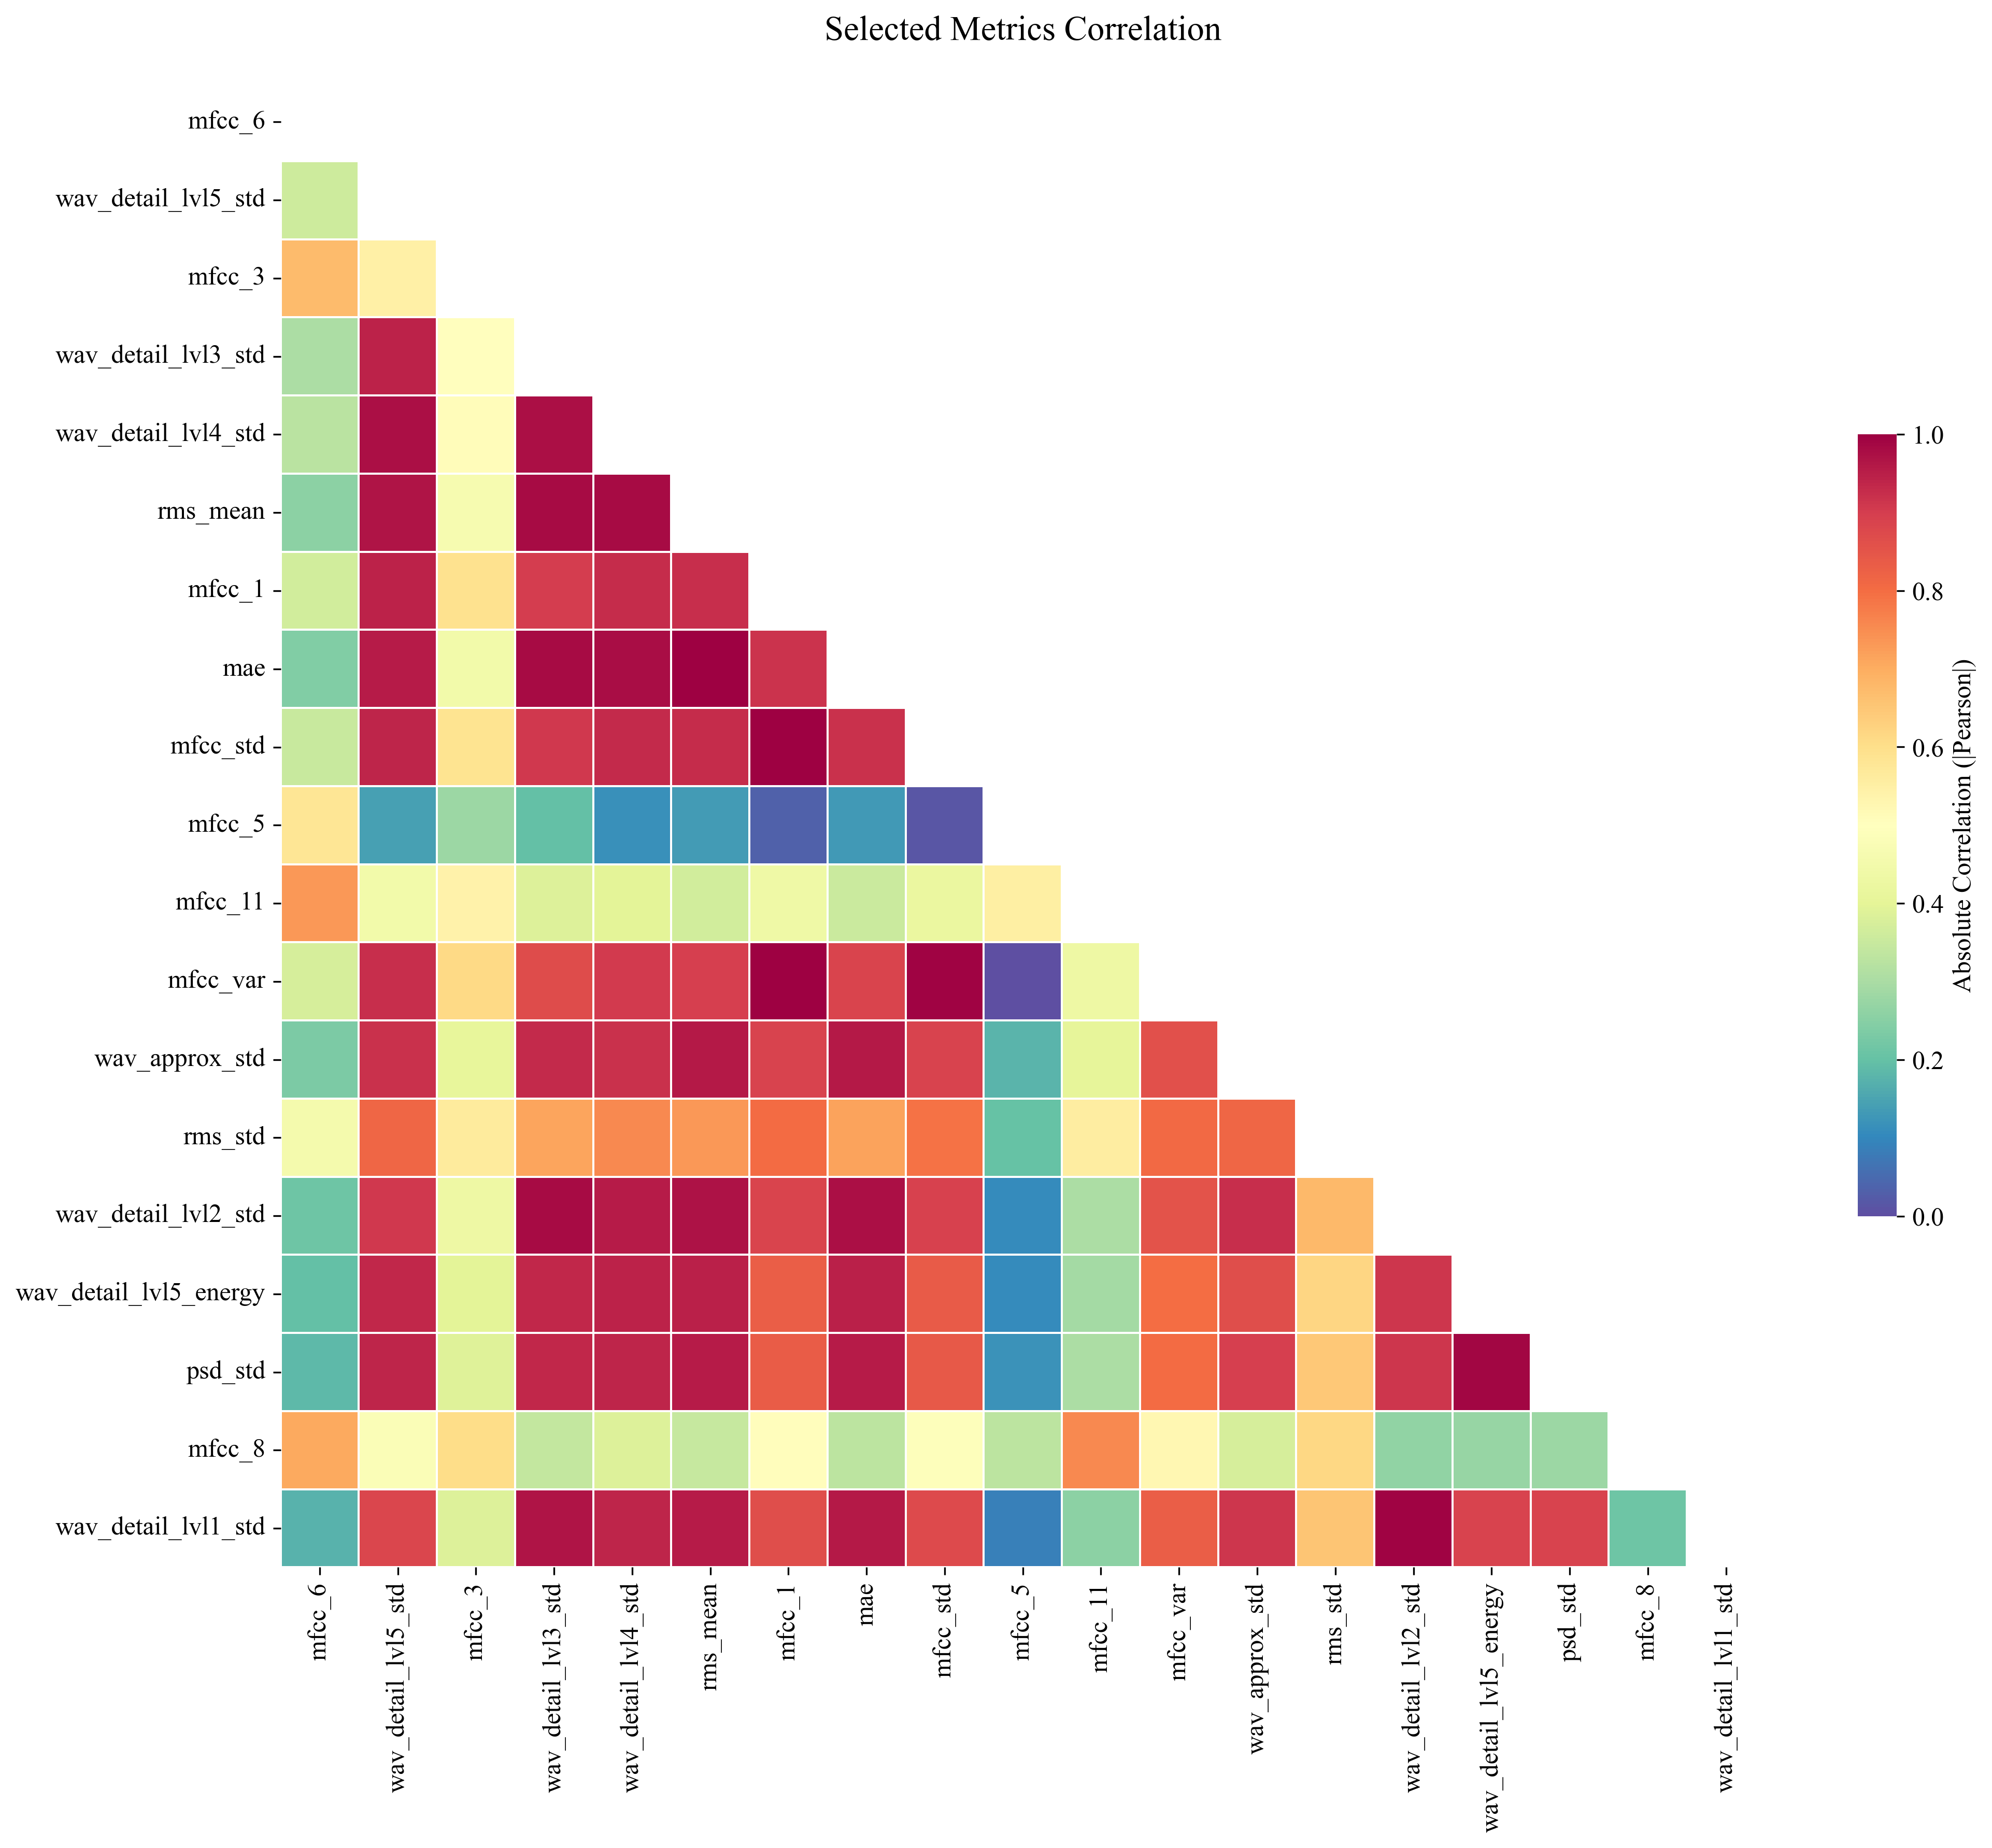

In [9]:
plot_correlation_heatmap(
    df=X_train_fischer_metrics,
    threshold=0.85,
    title=f"Selected Metrics Correlation"
)

09:13:34 - [FeaturePlots] - INFO - Generating Individual Boxplots for 19 features...


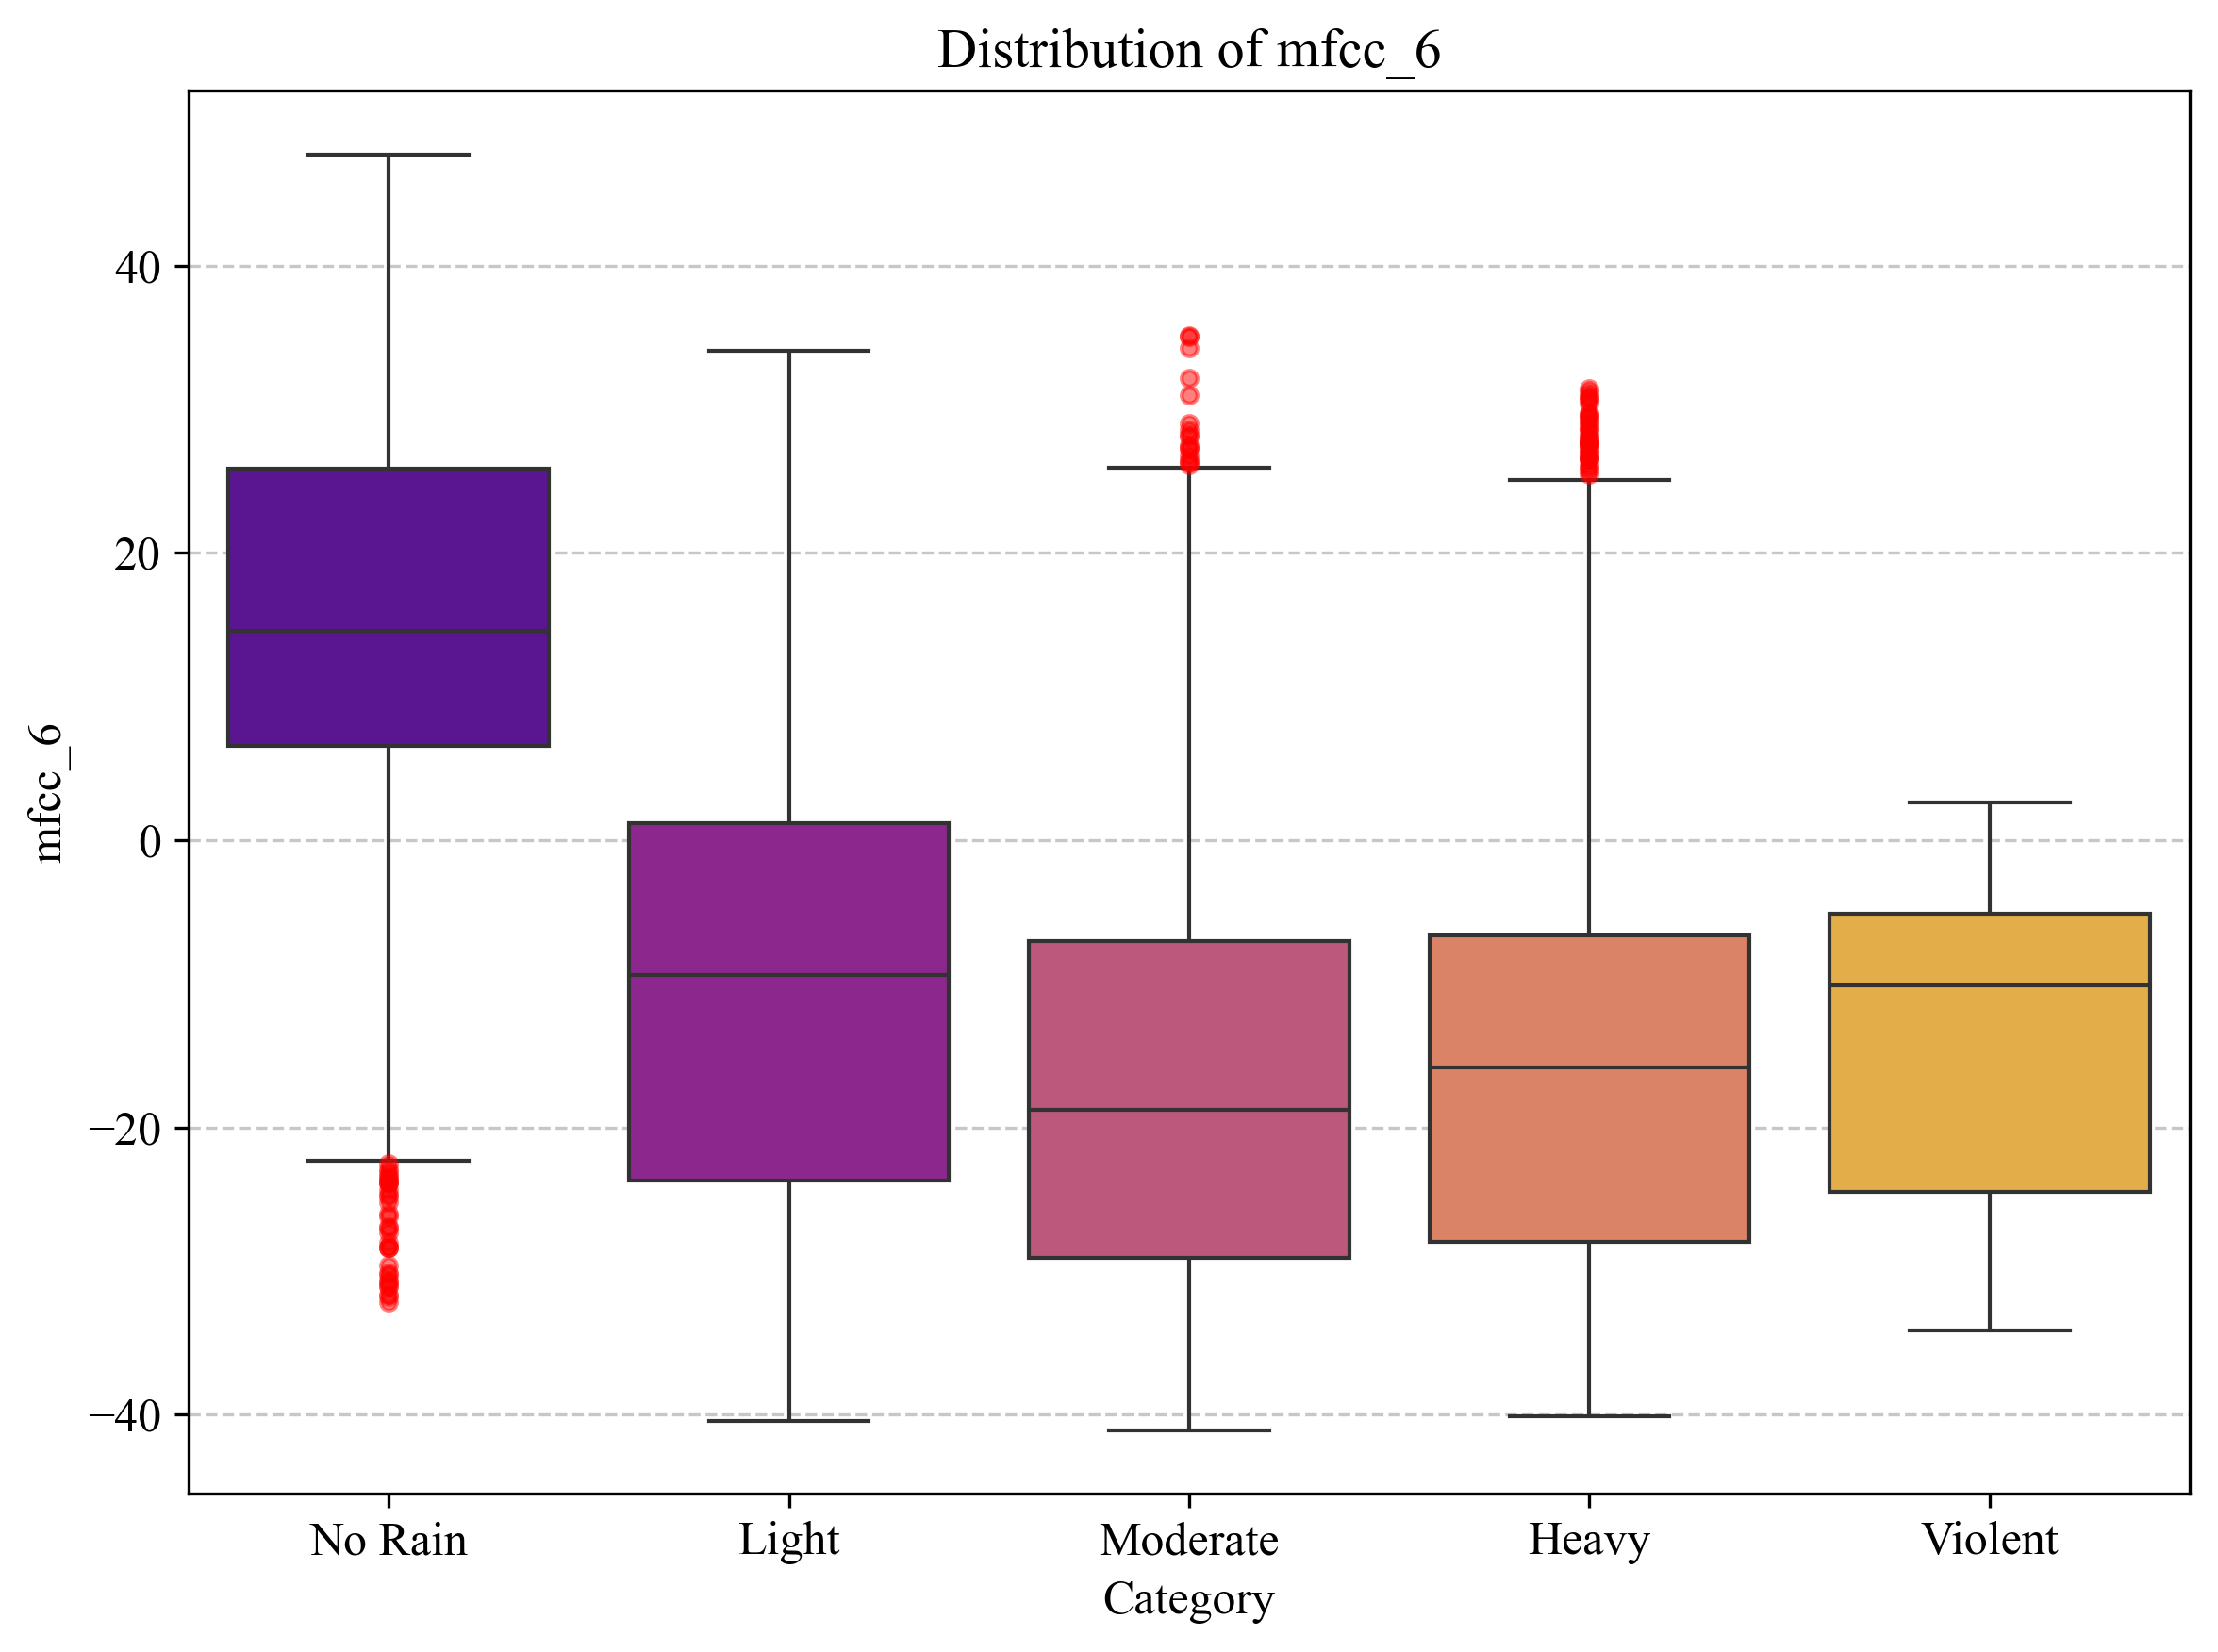

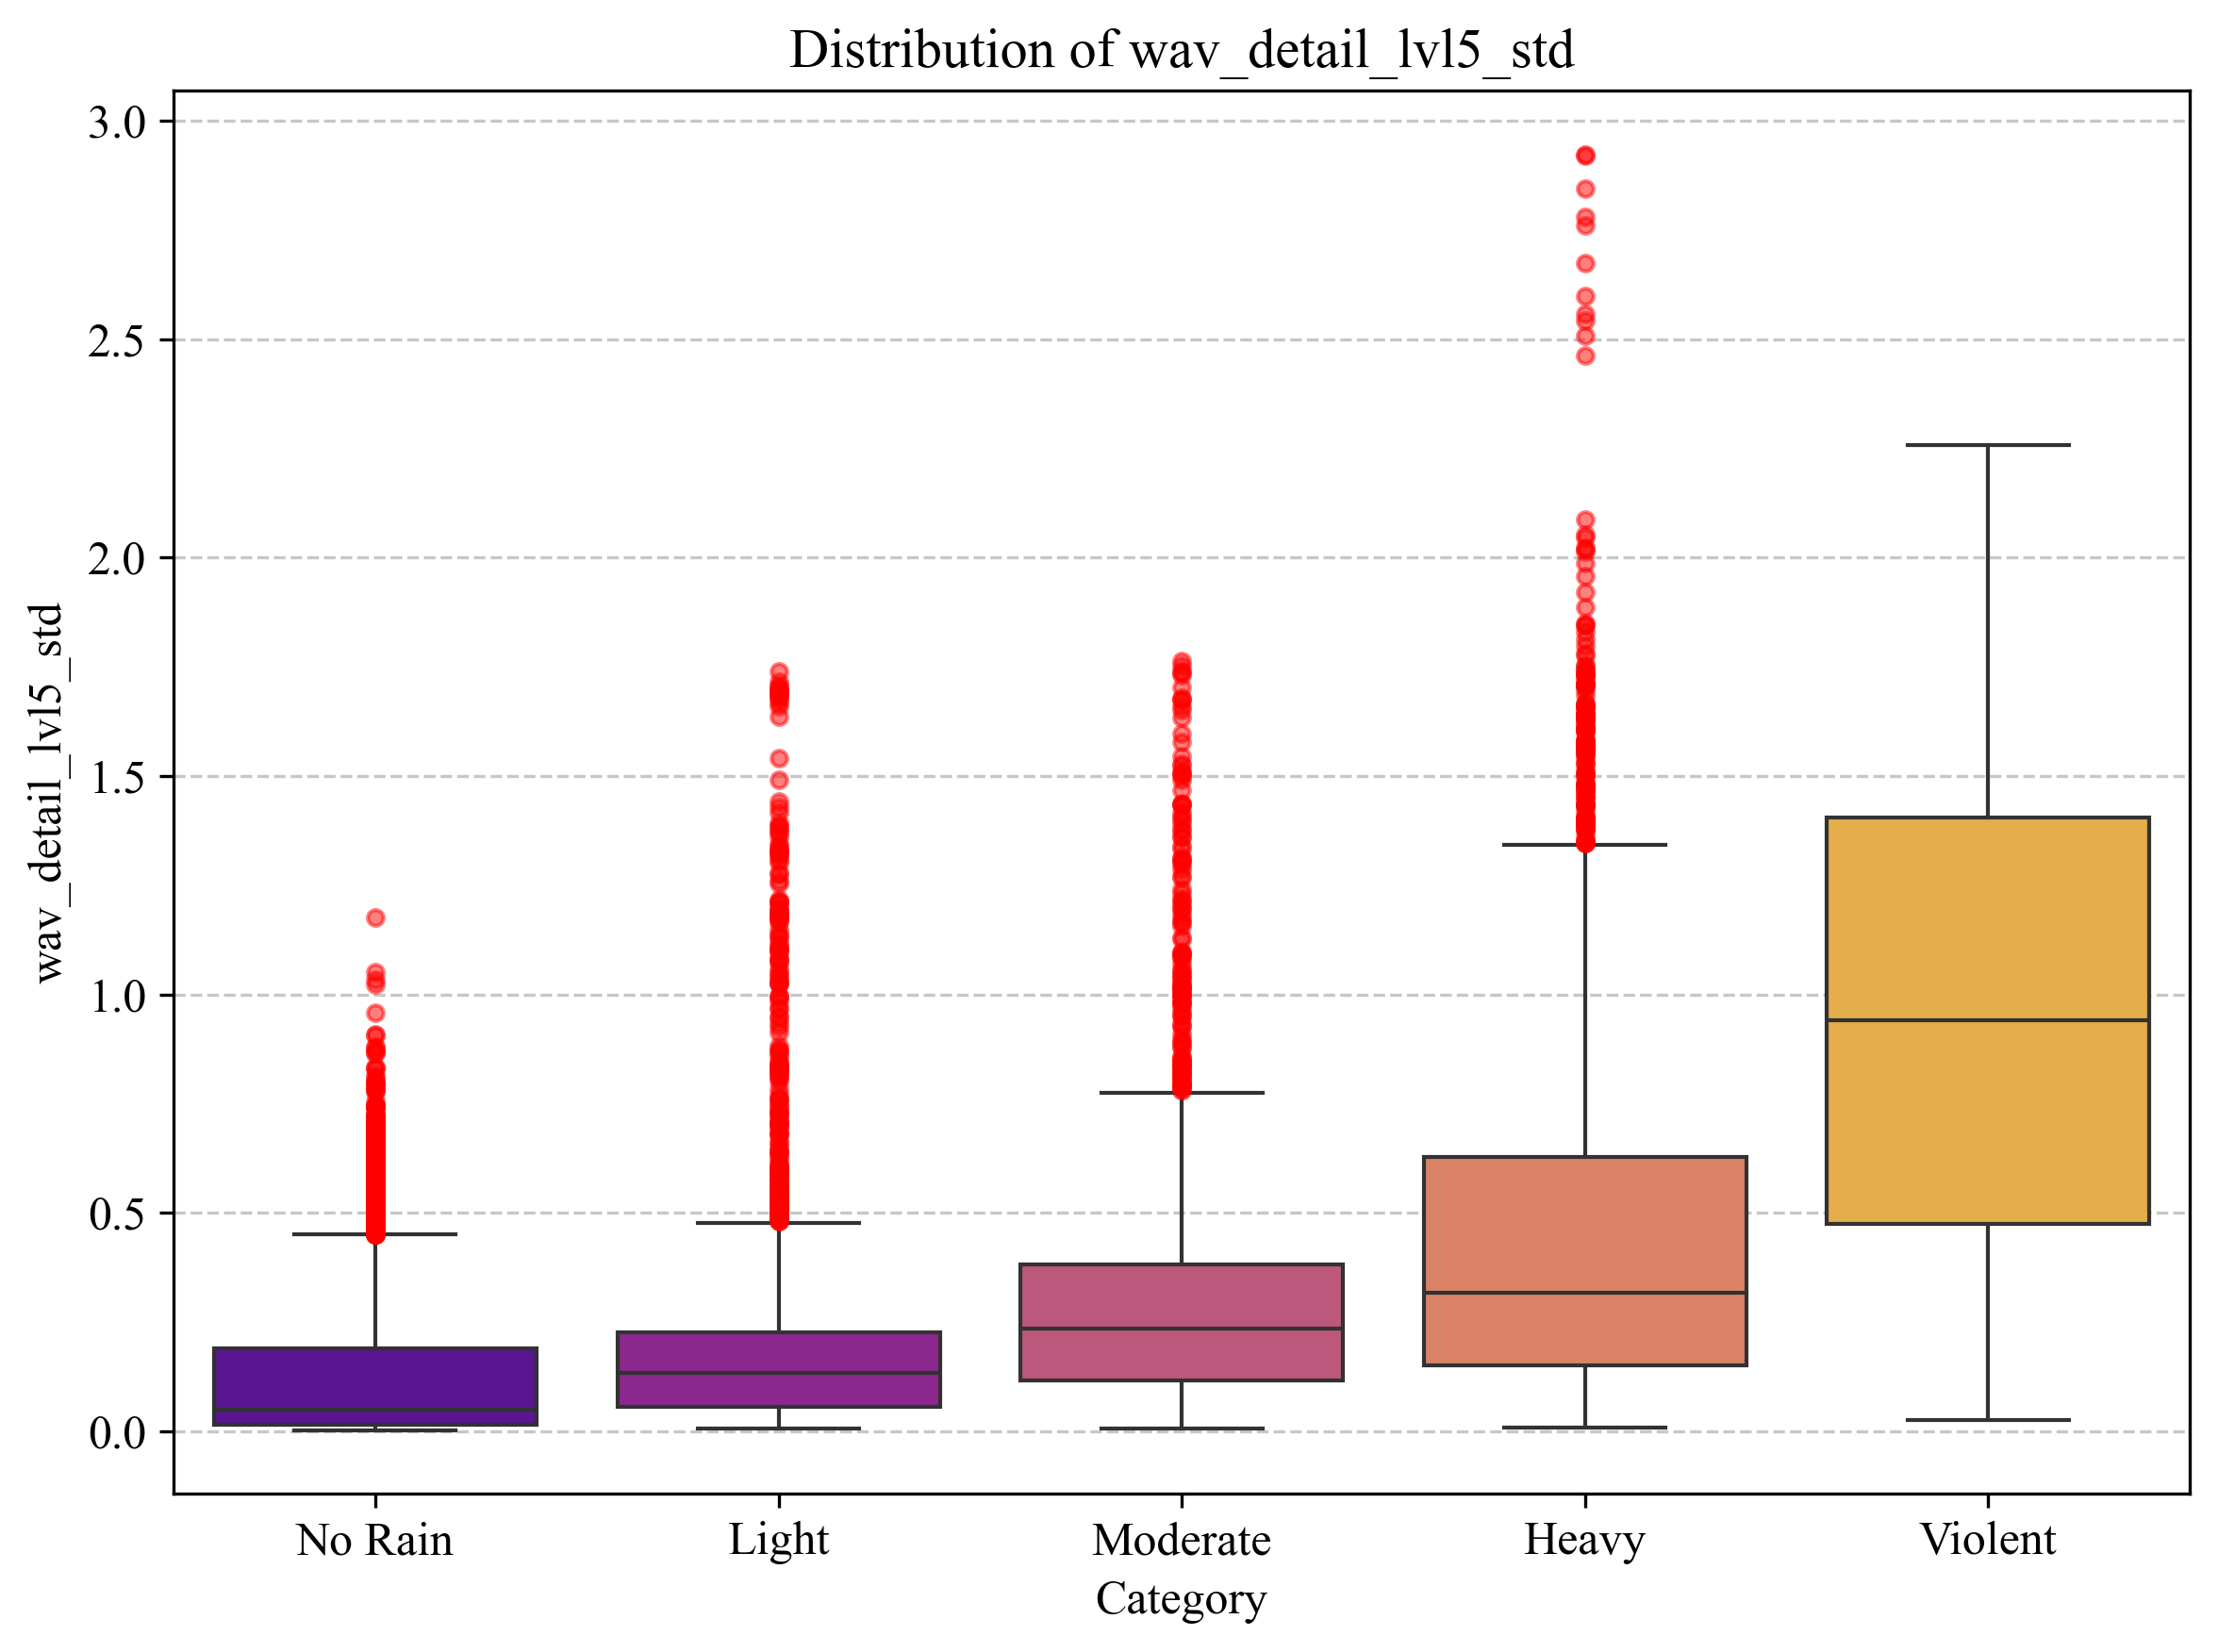

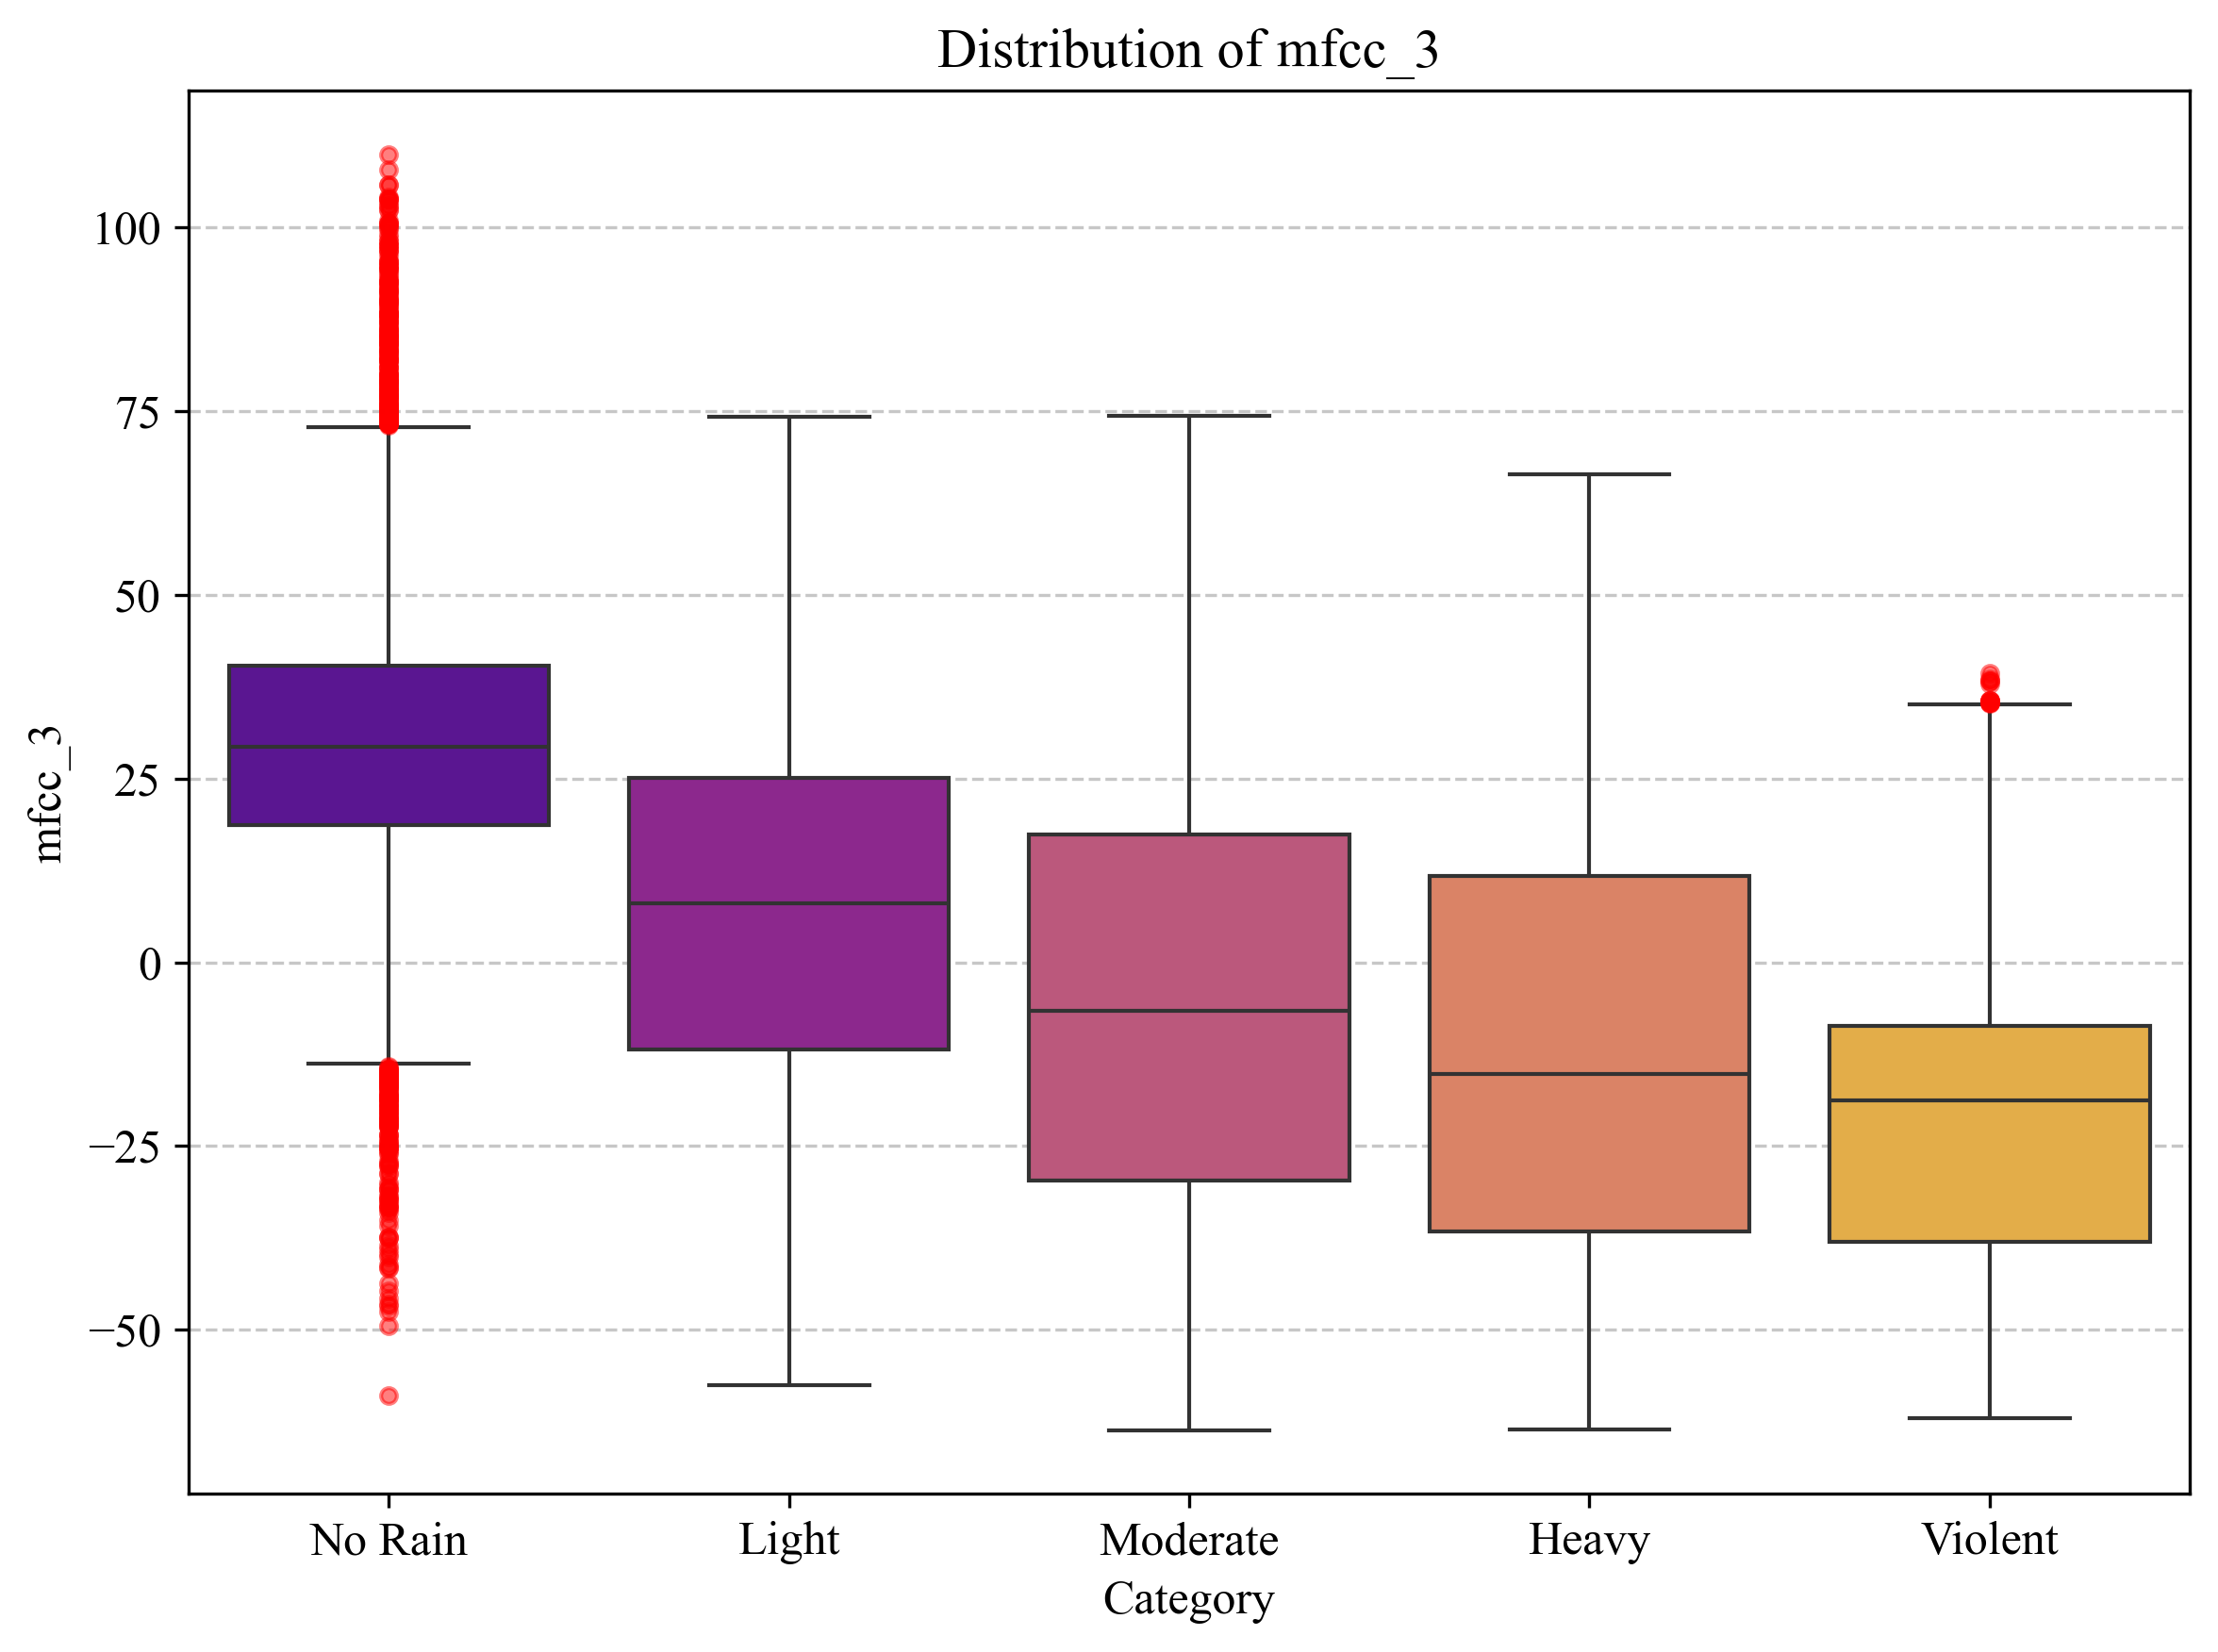

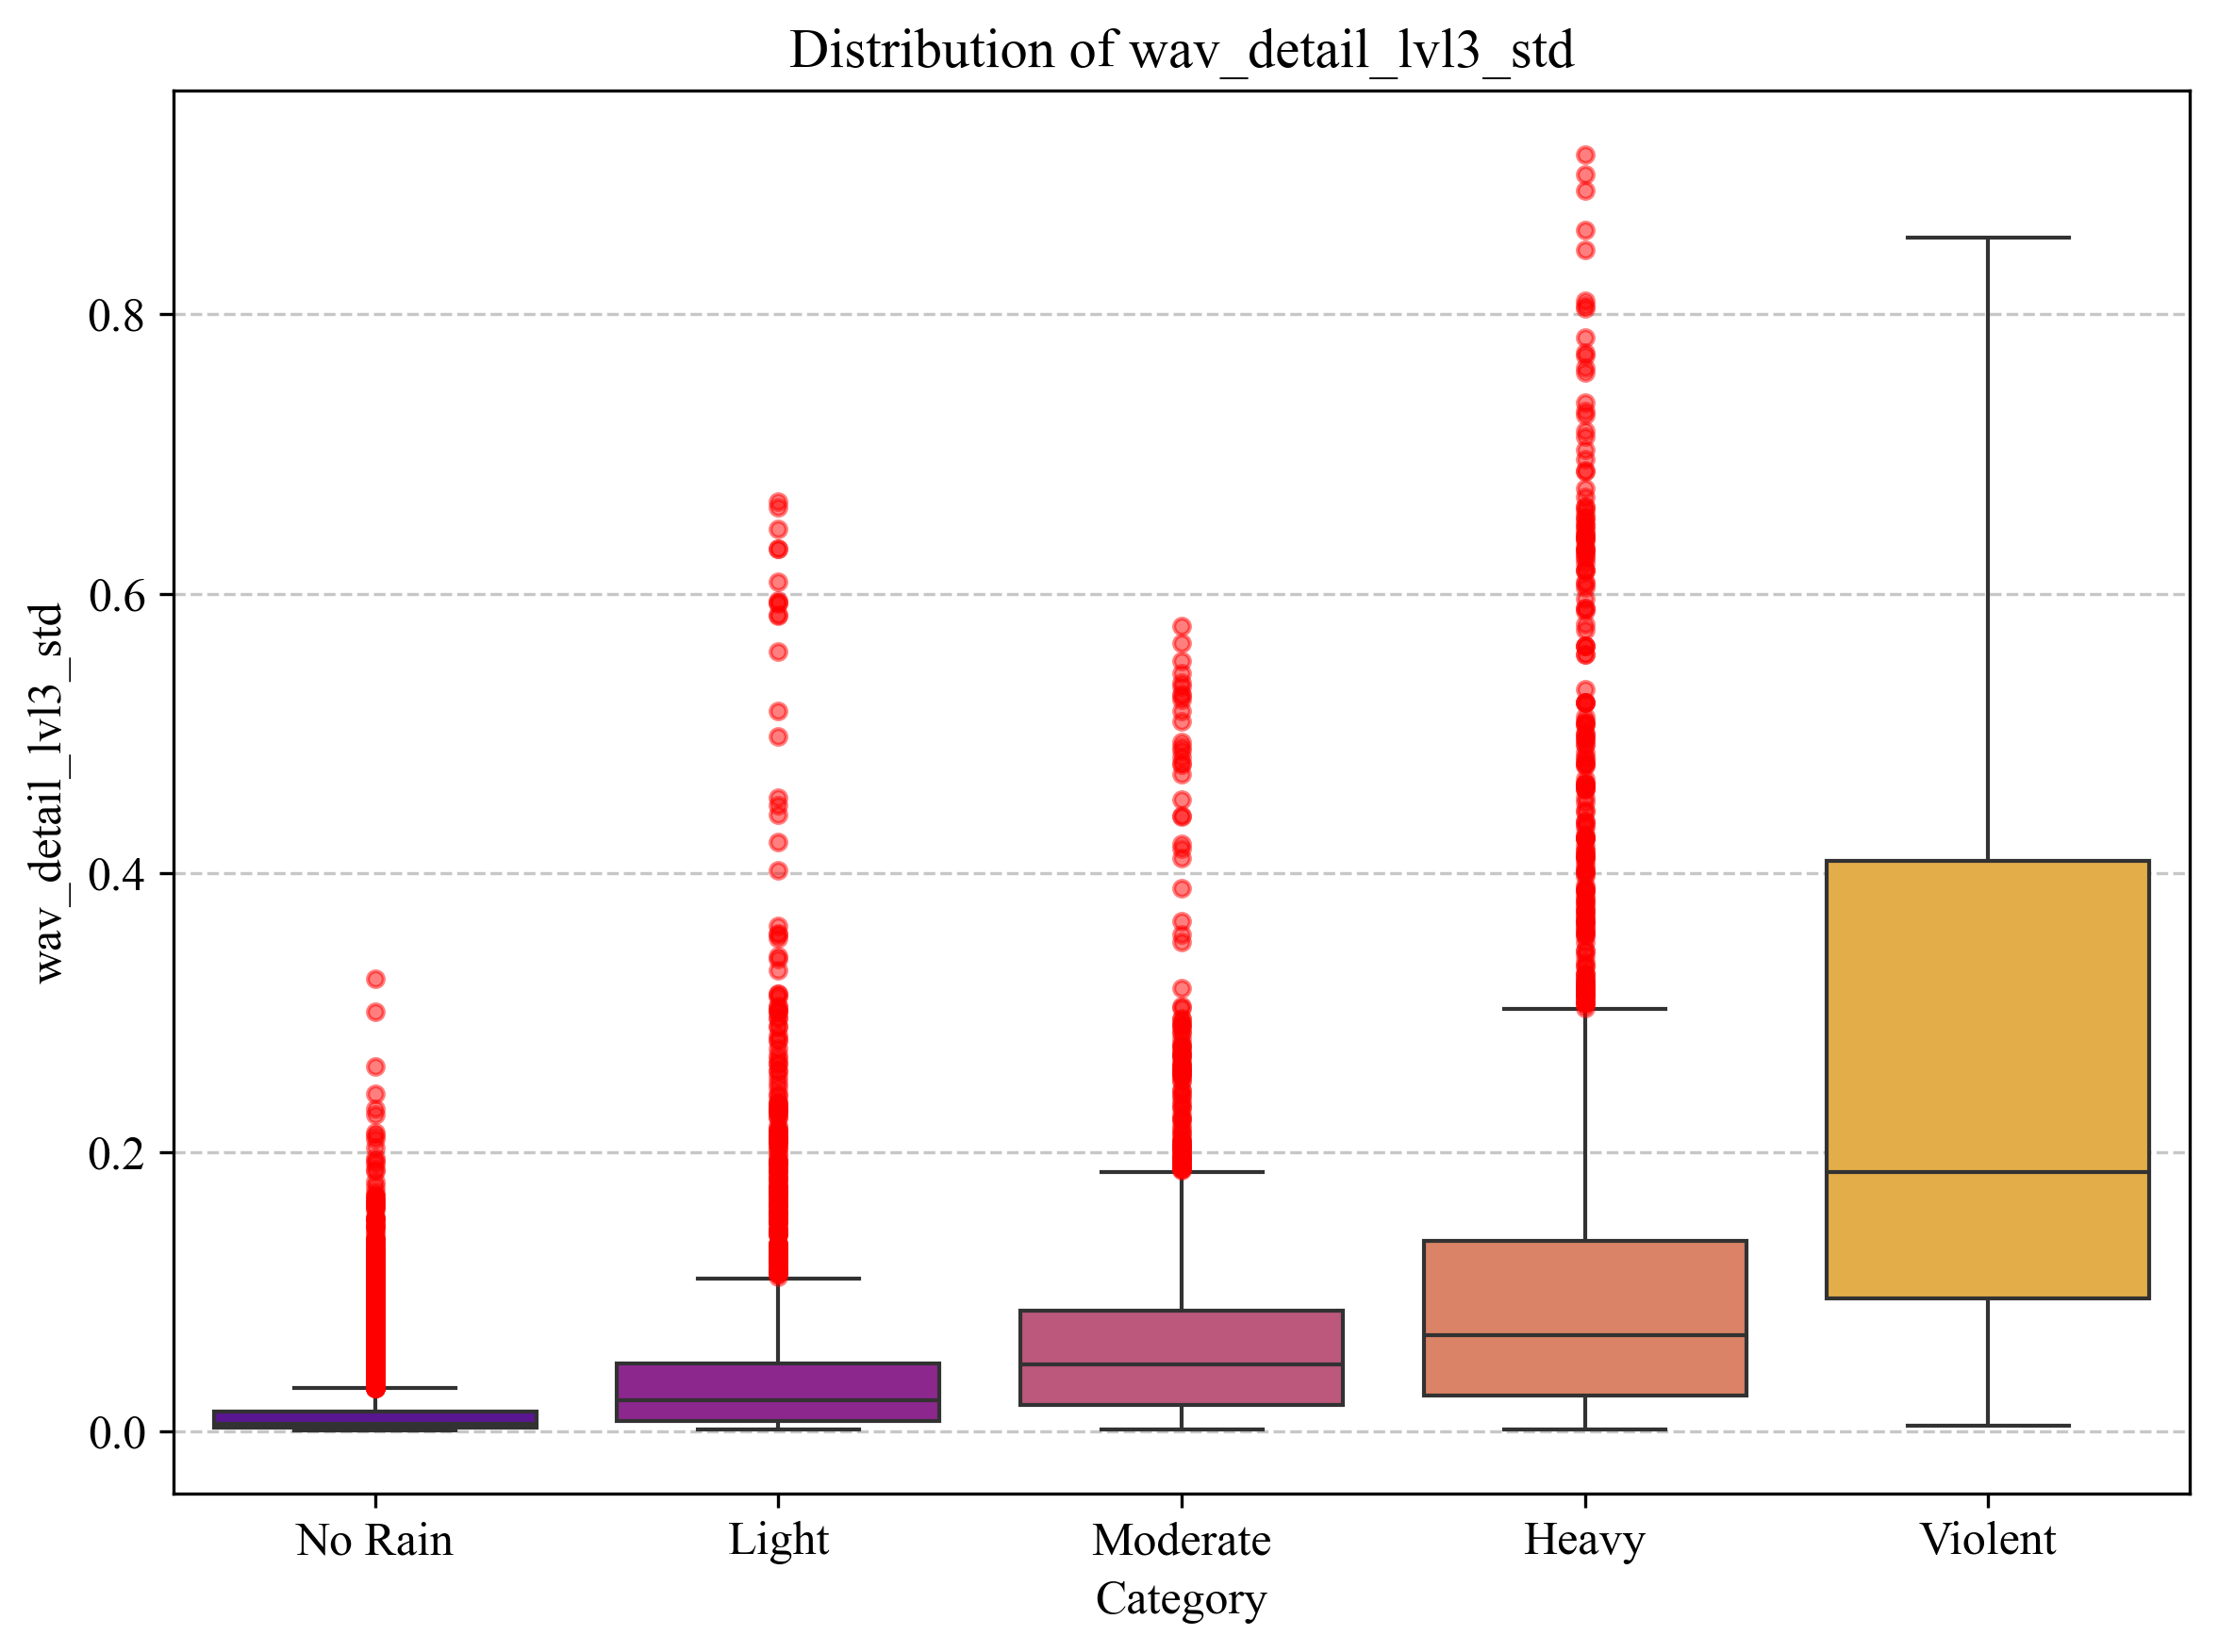

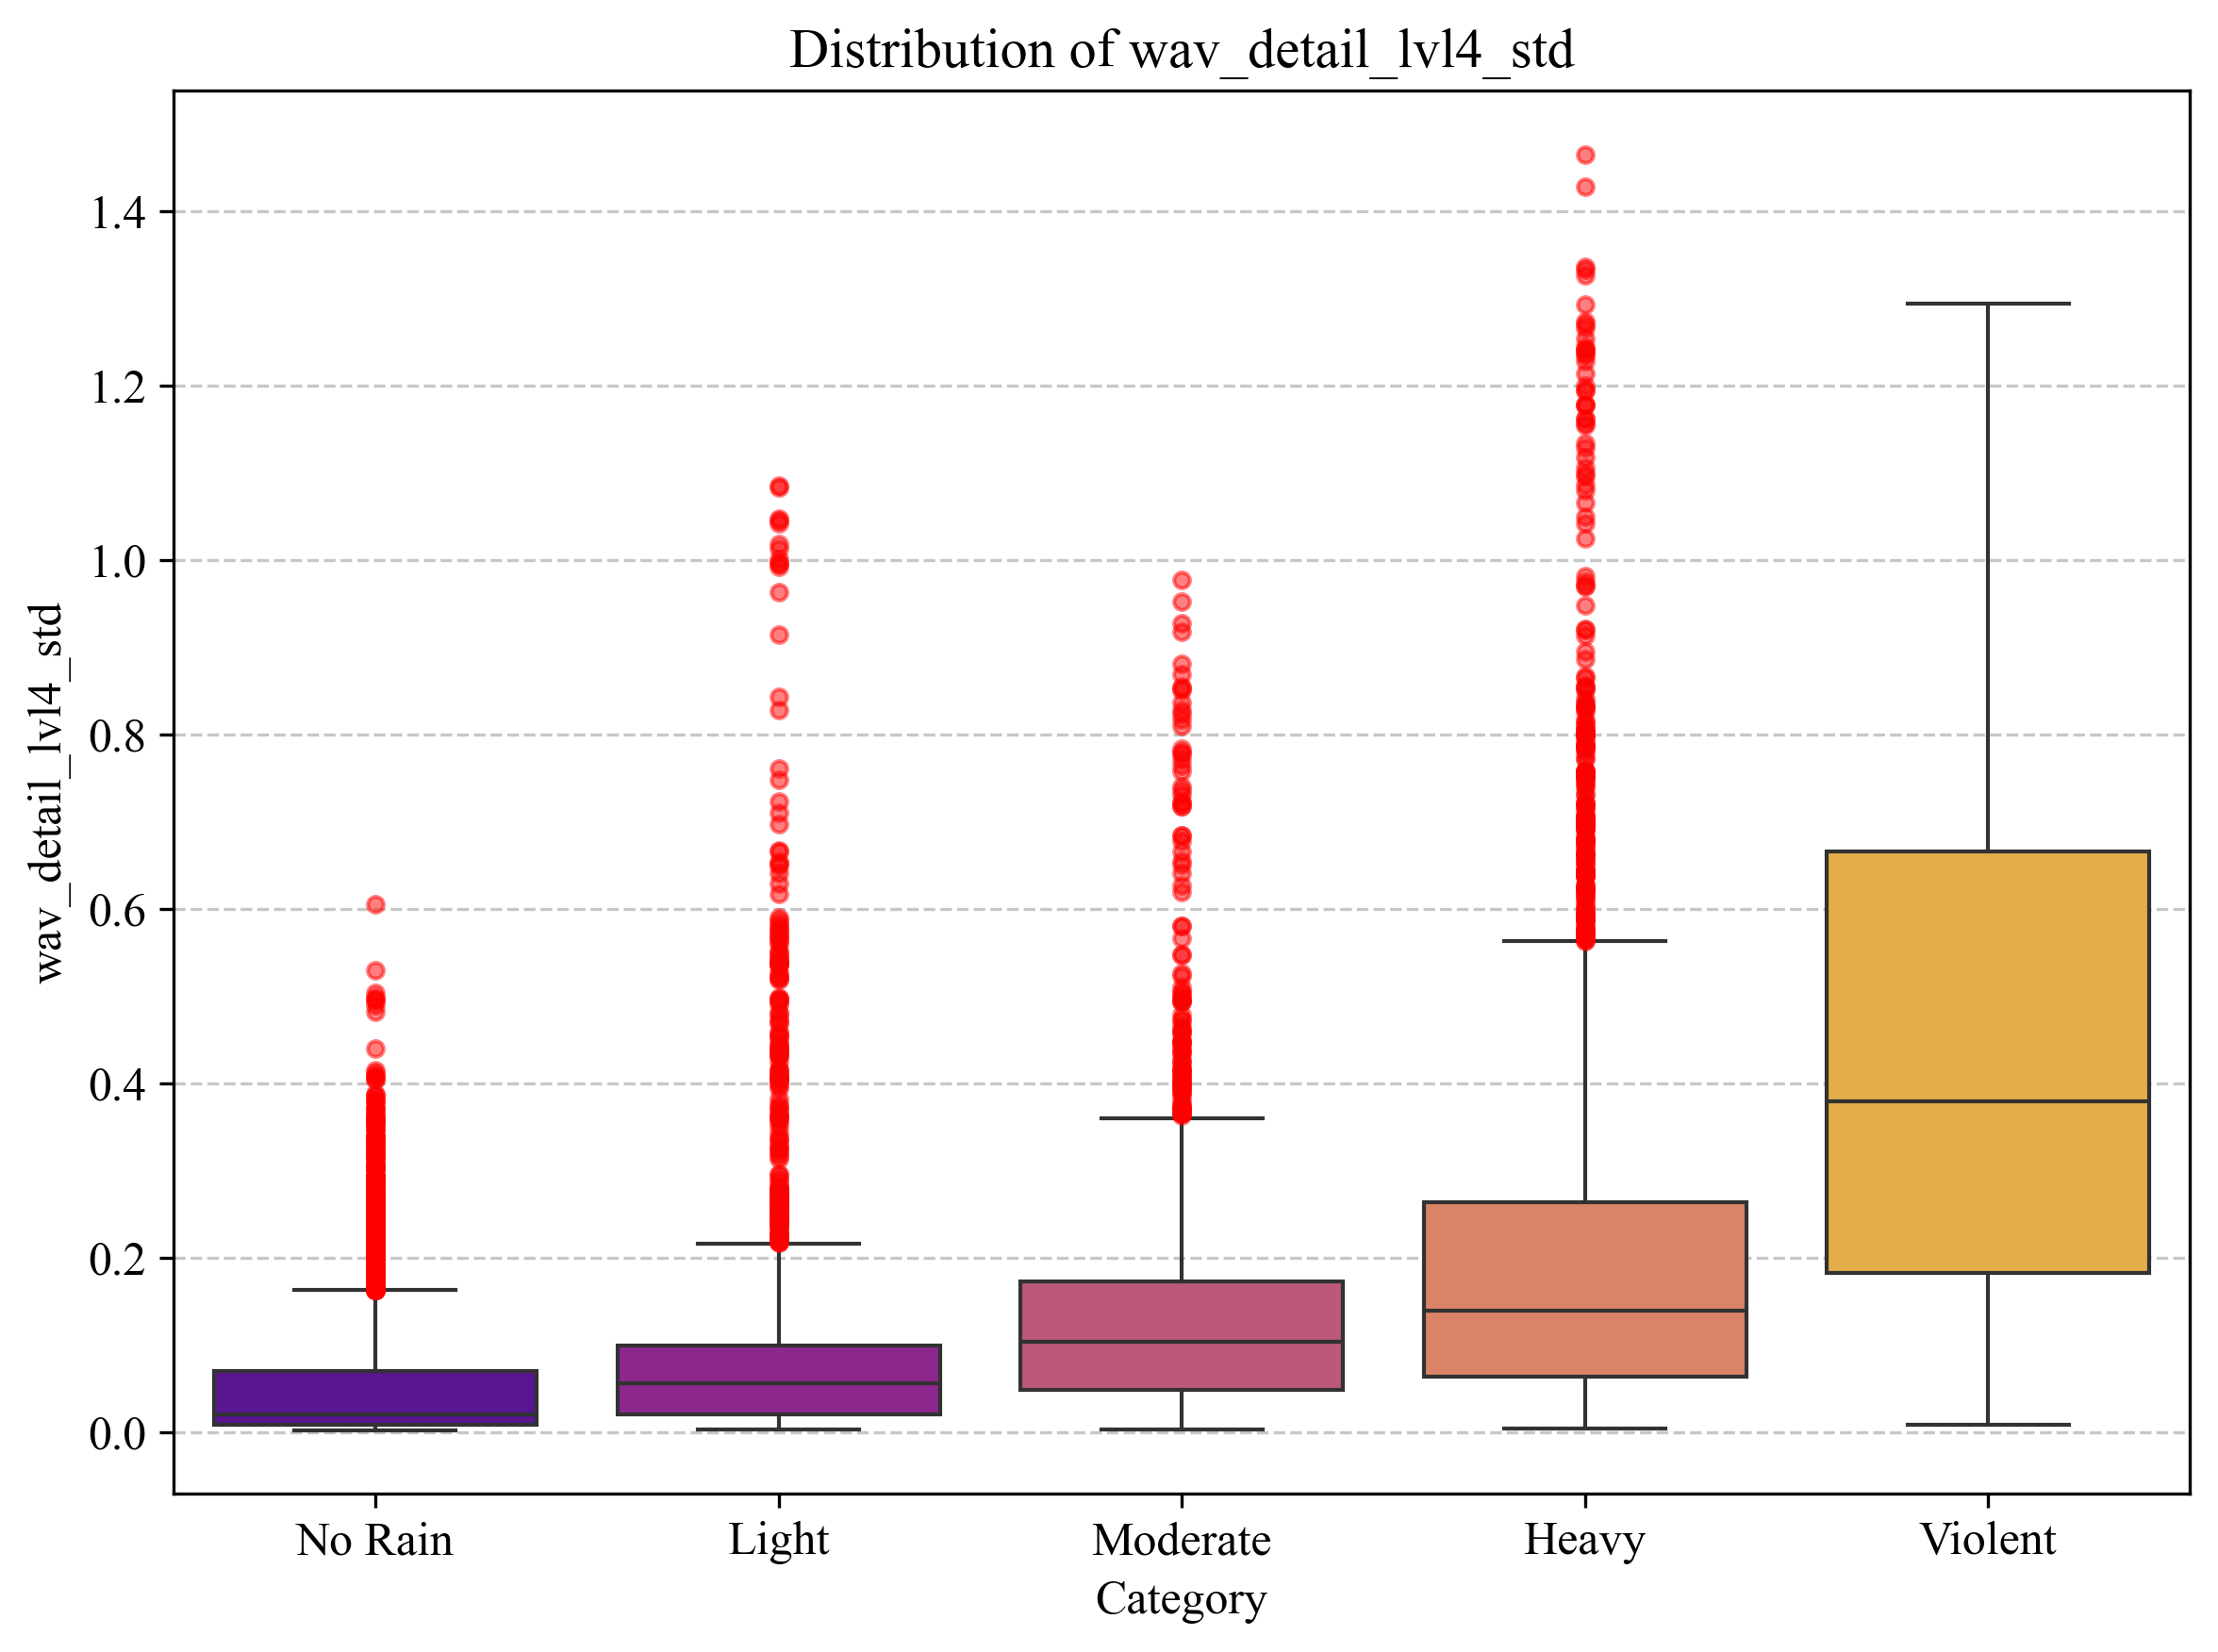

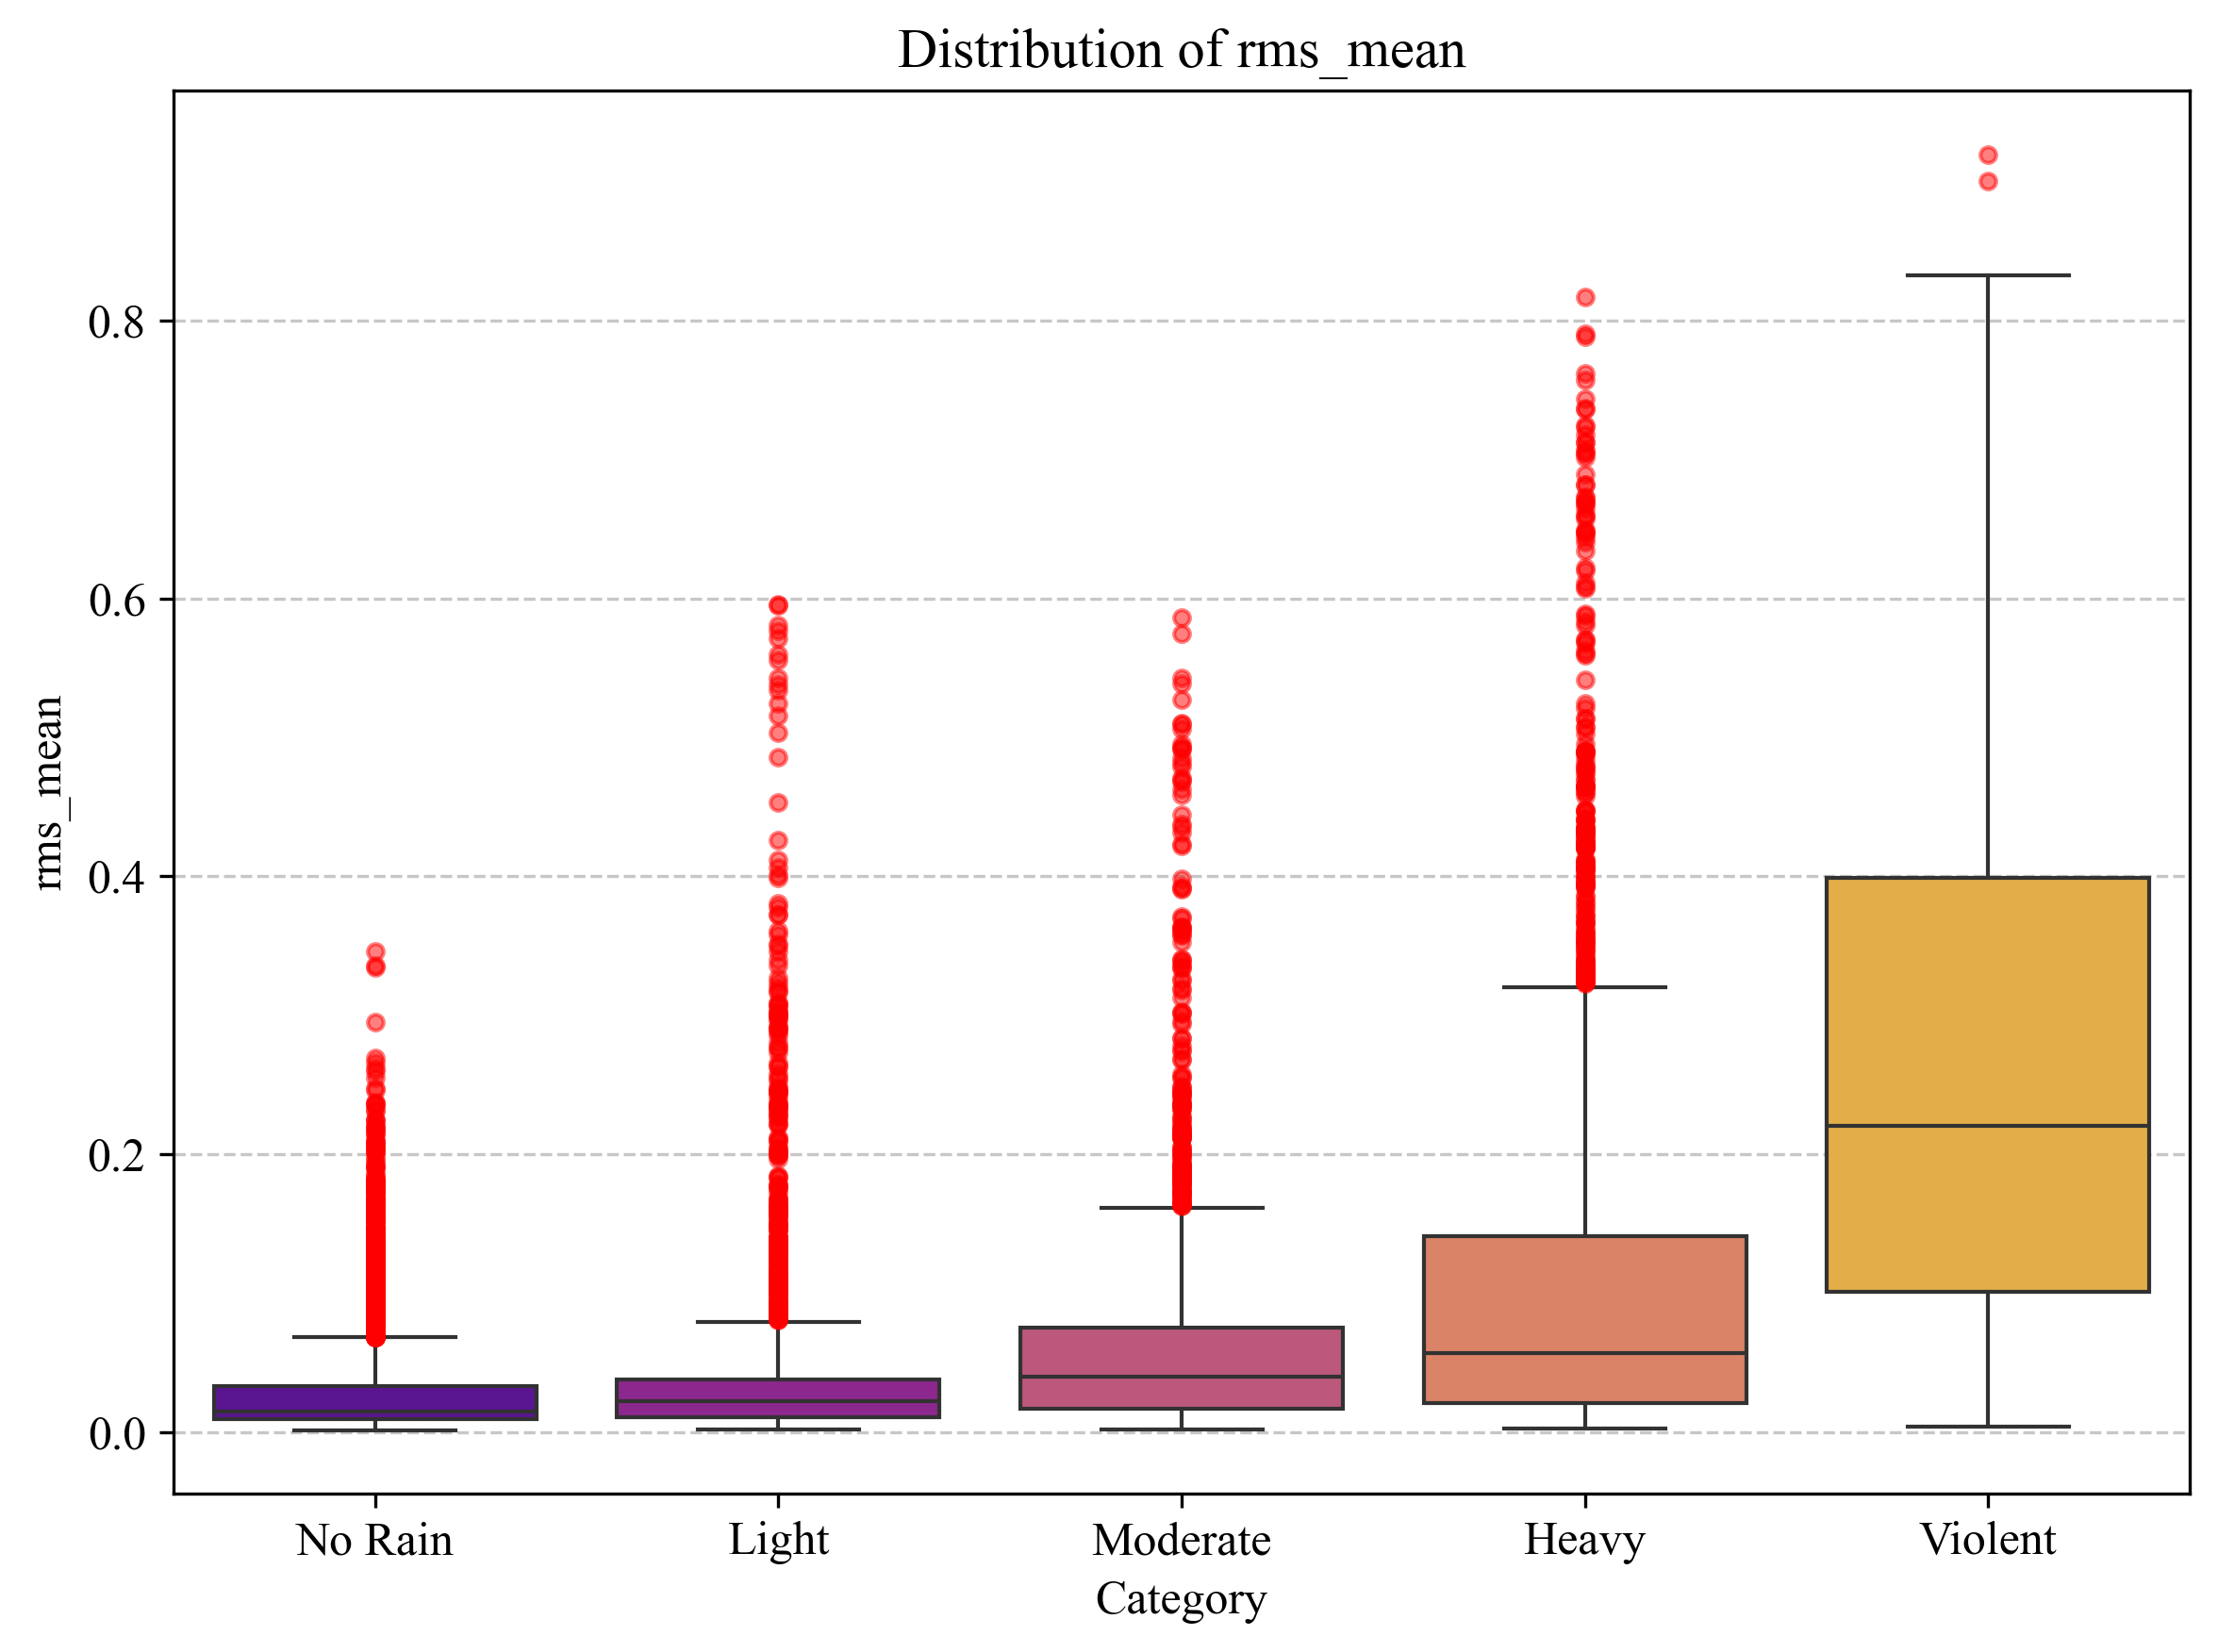

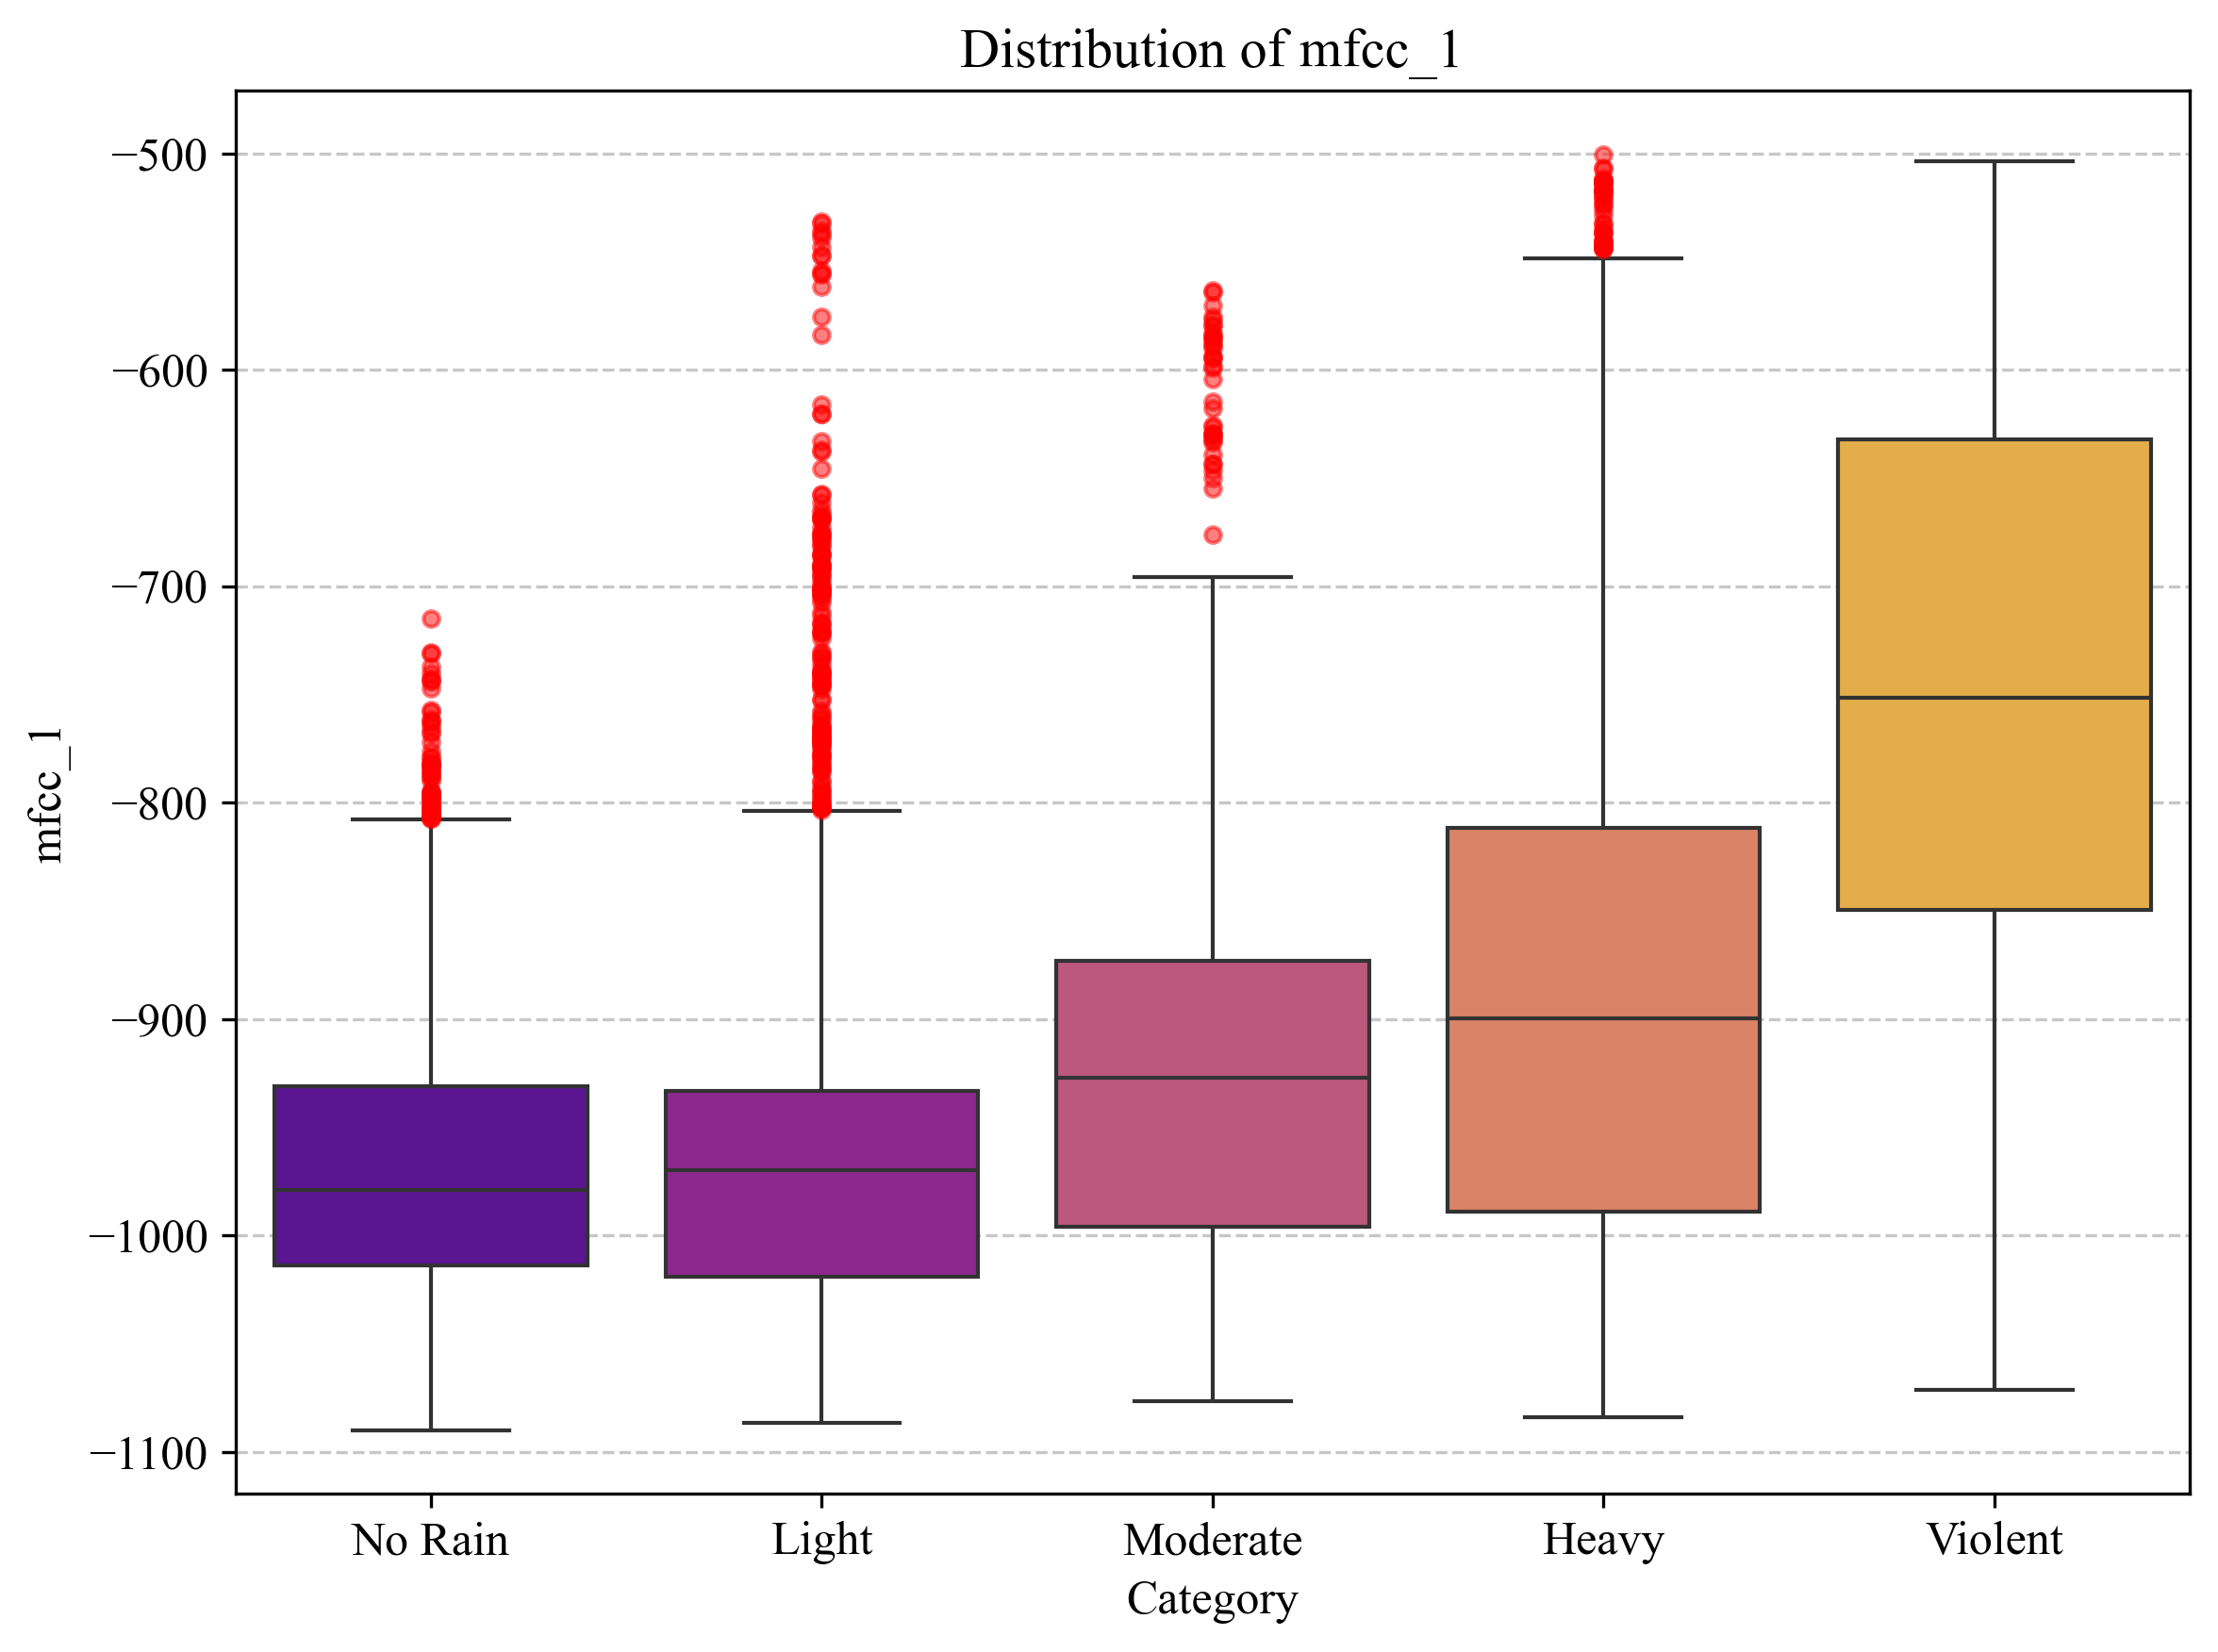

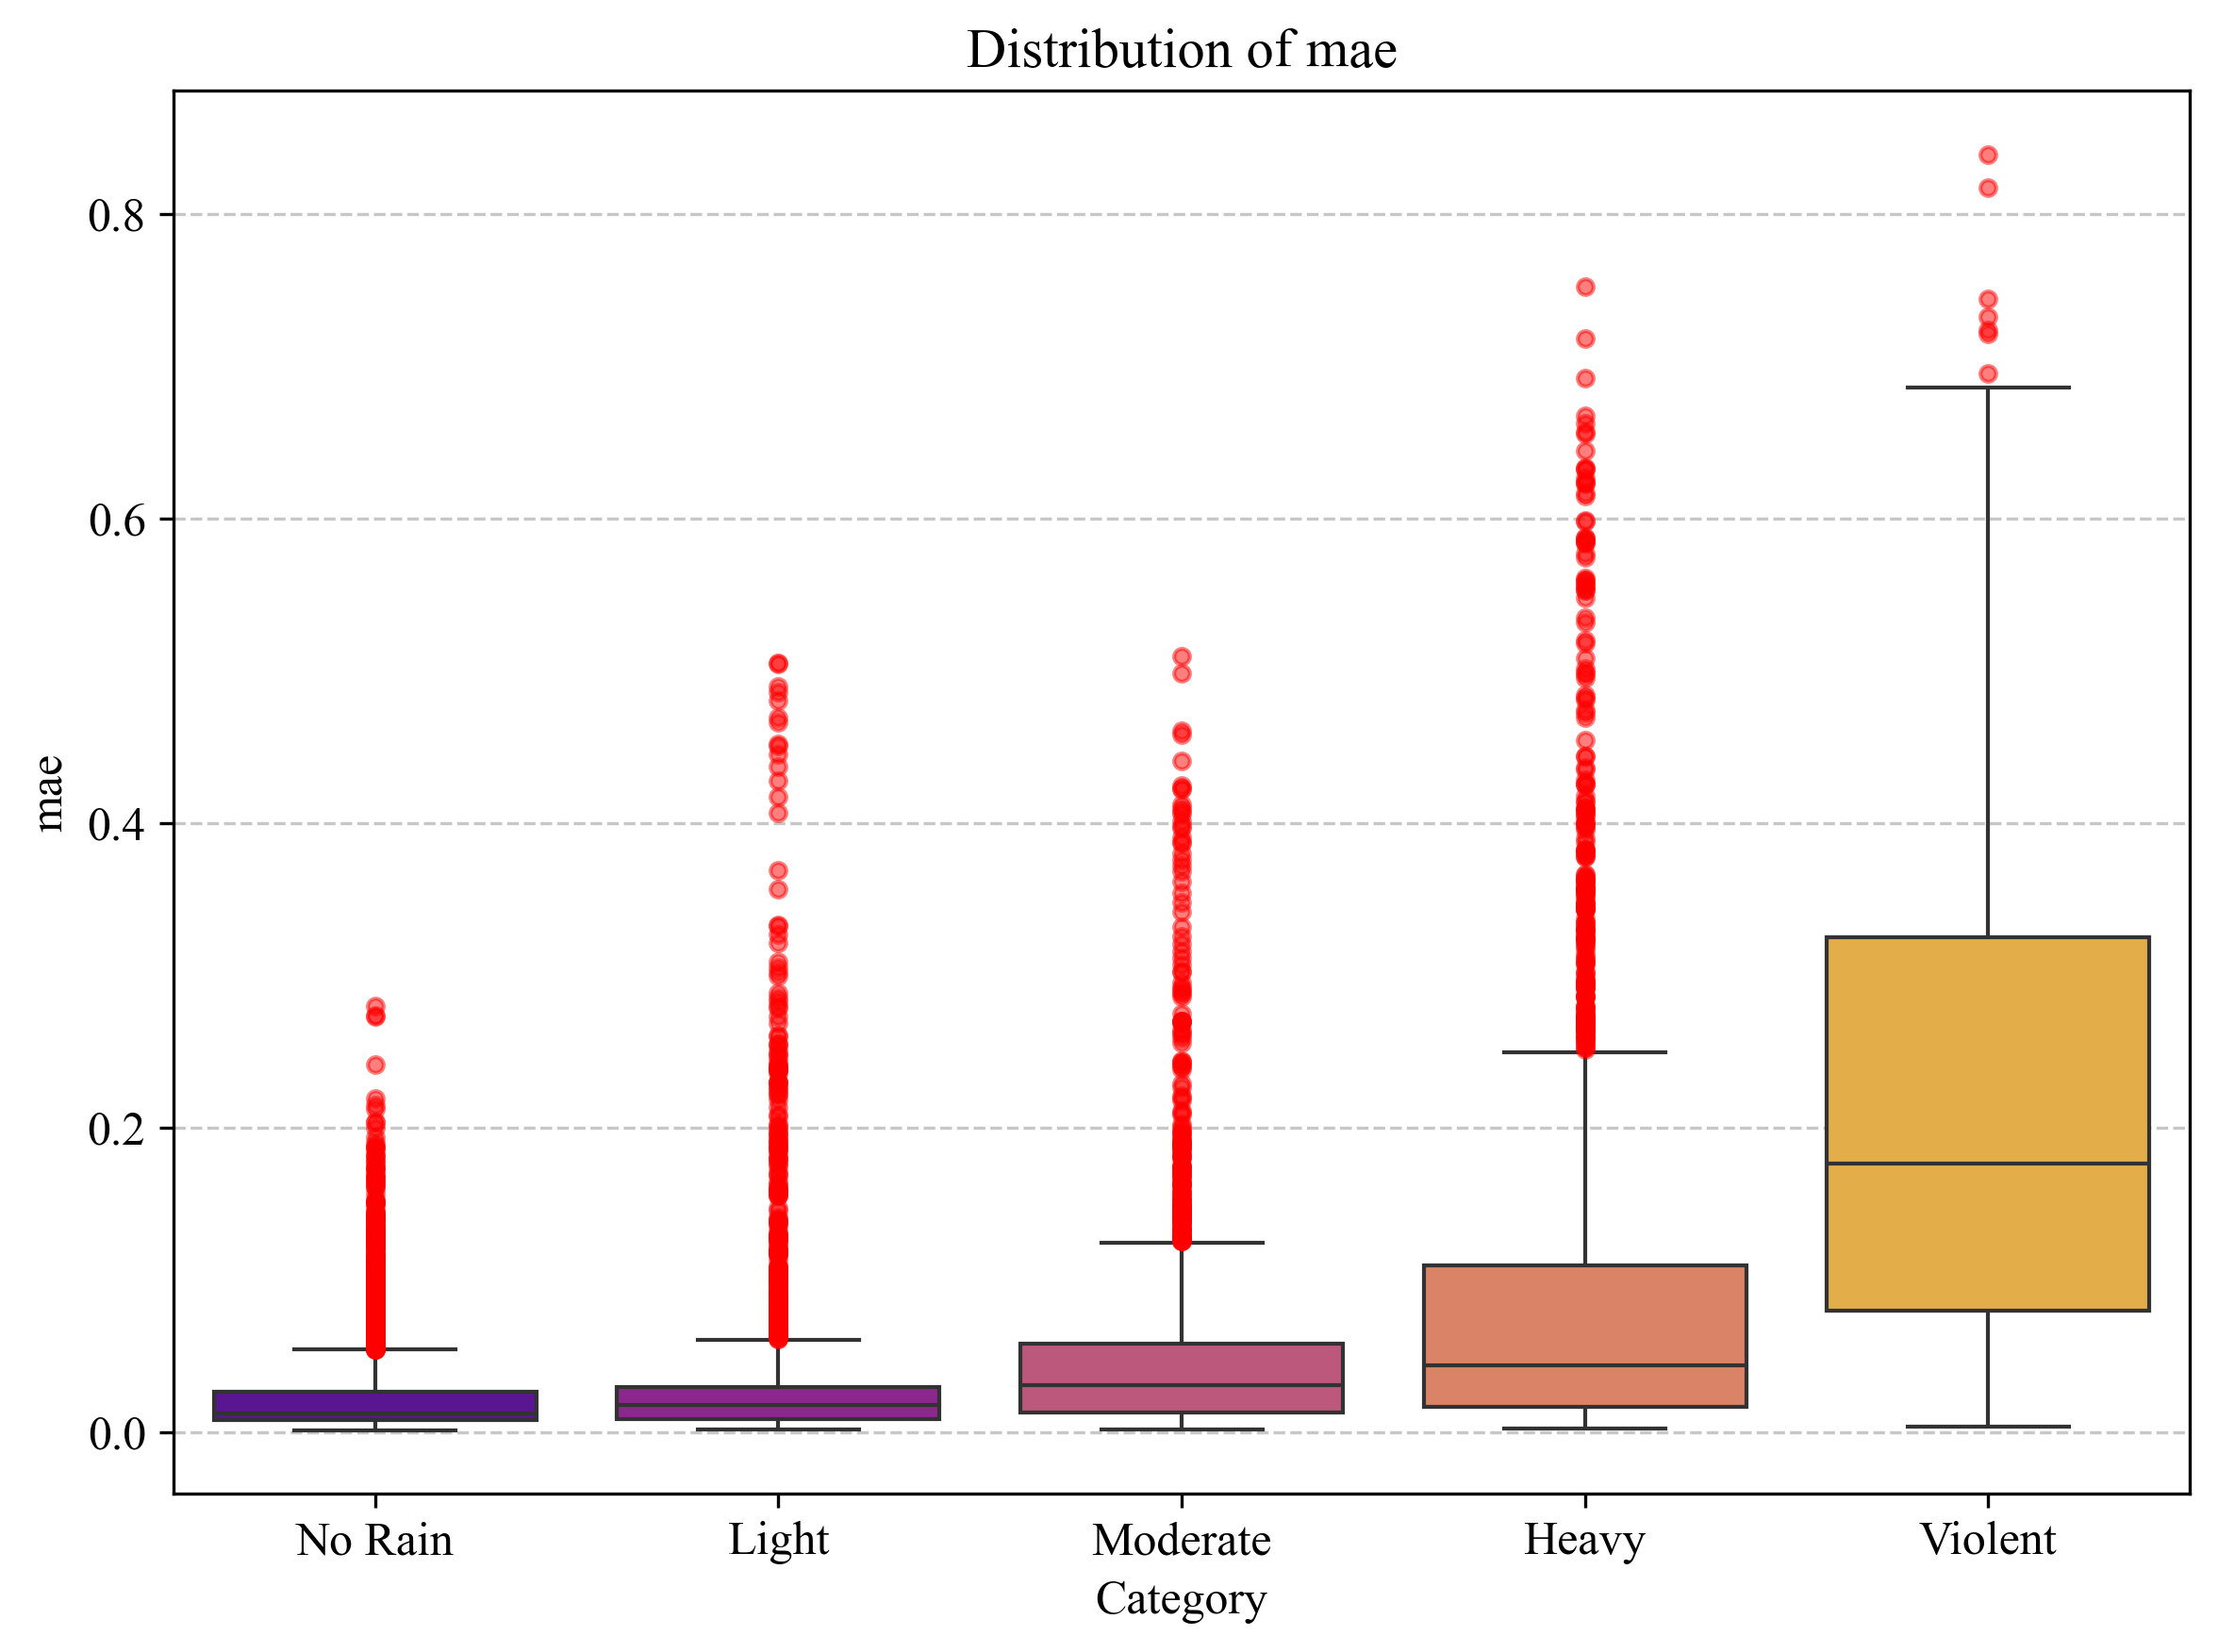

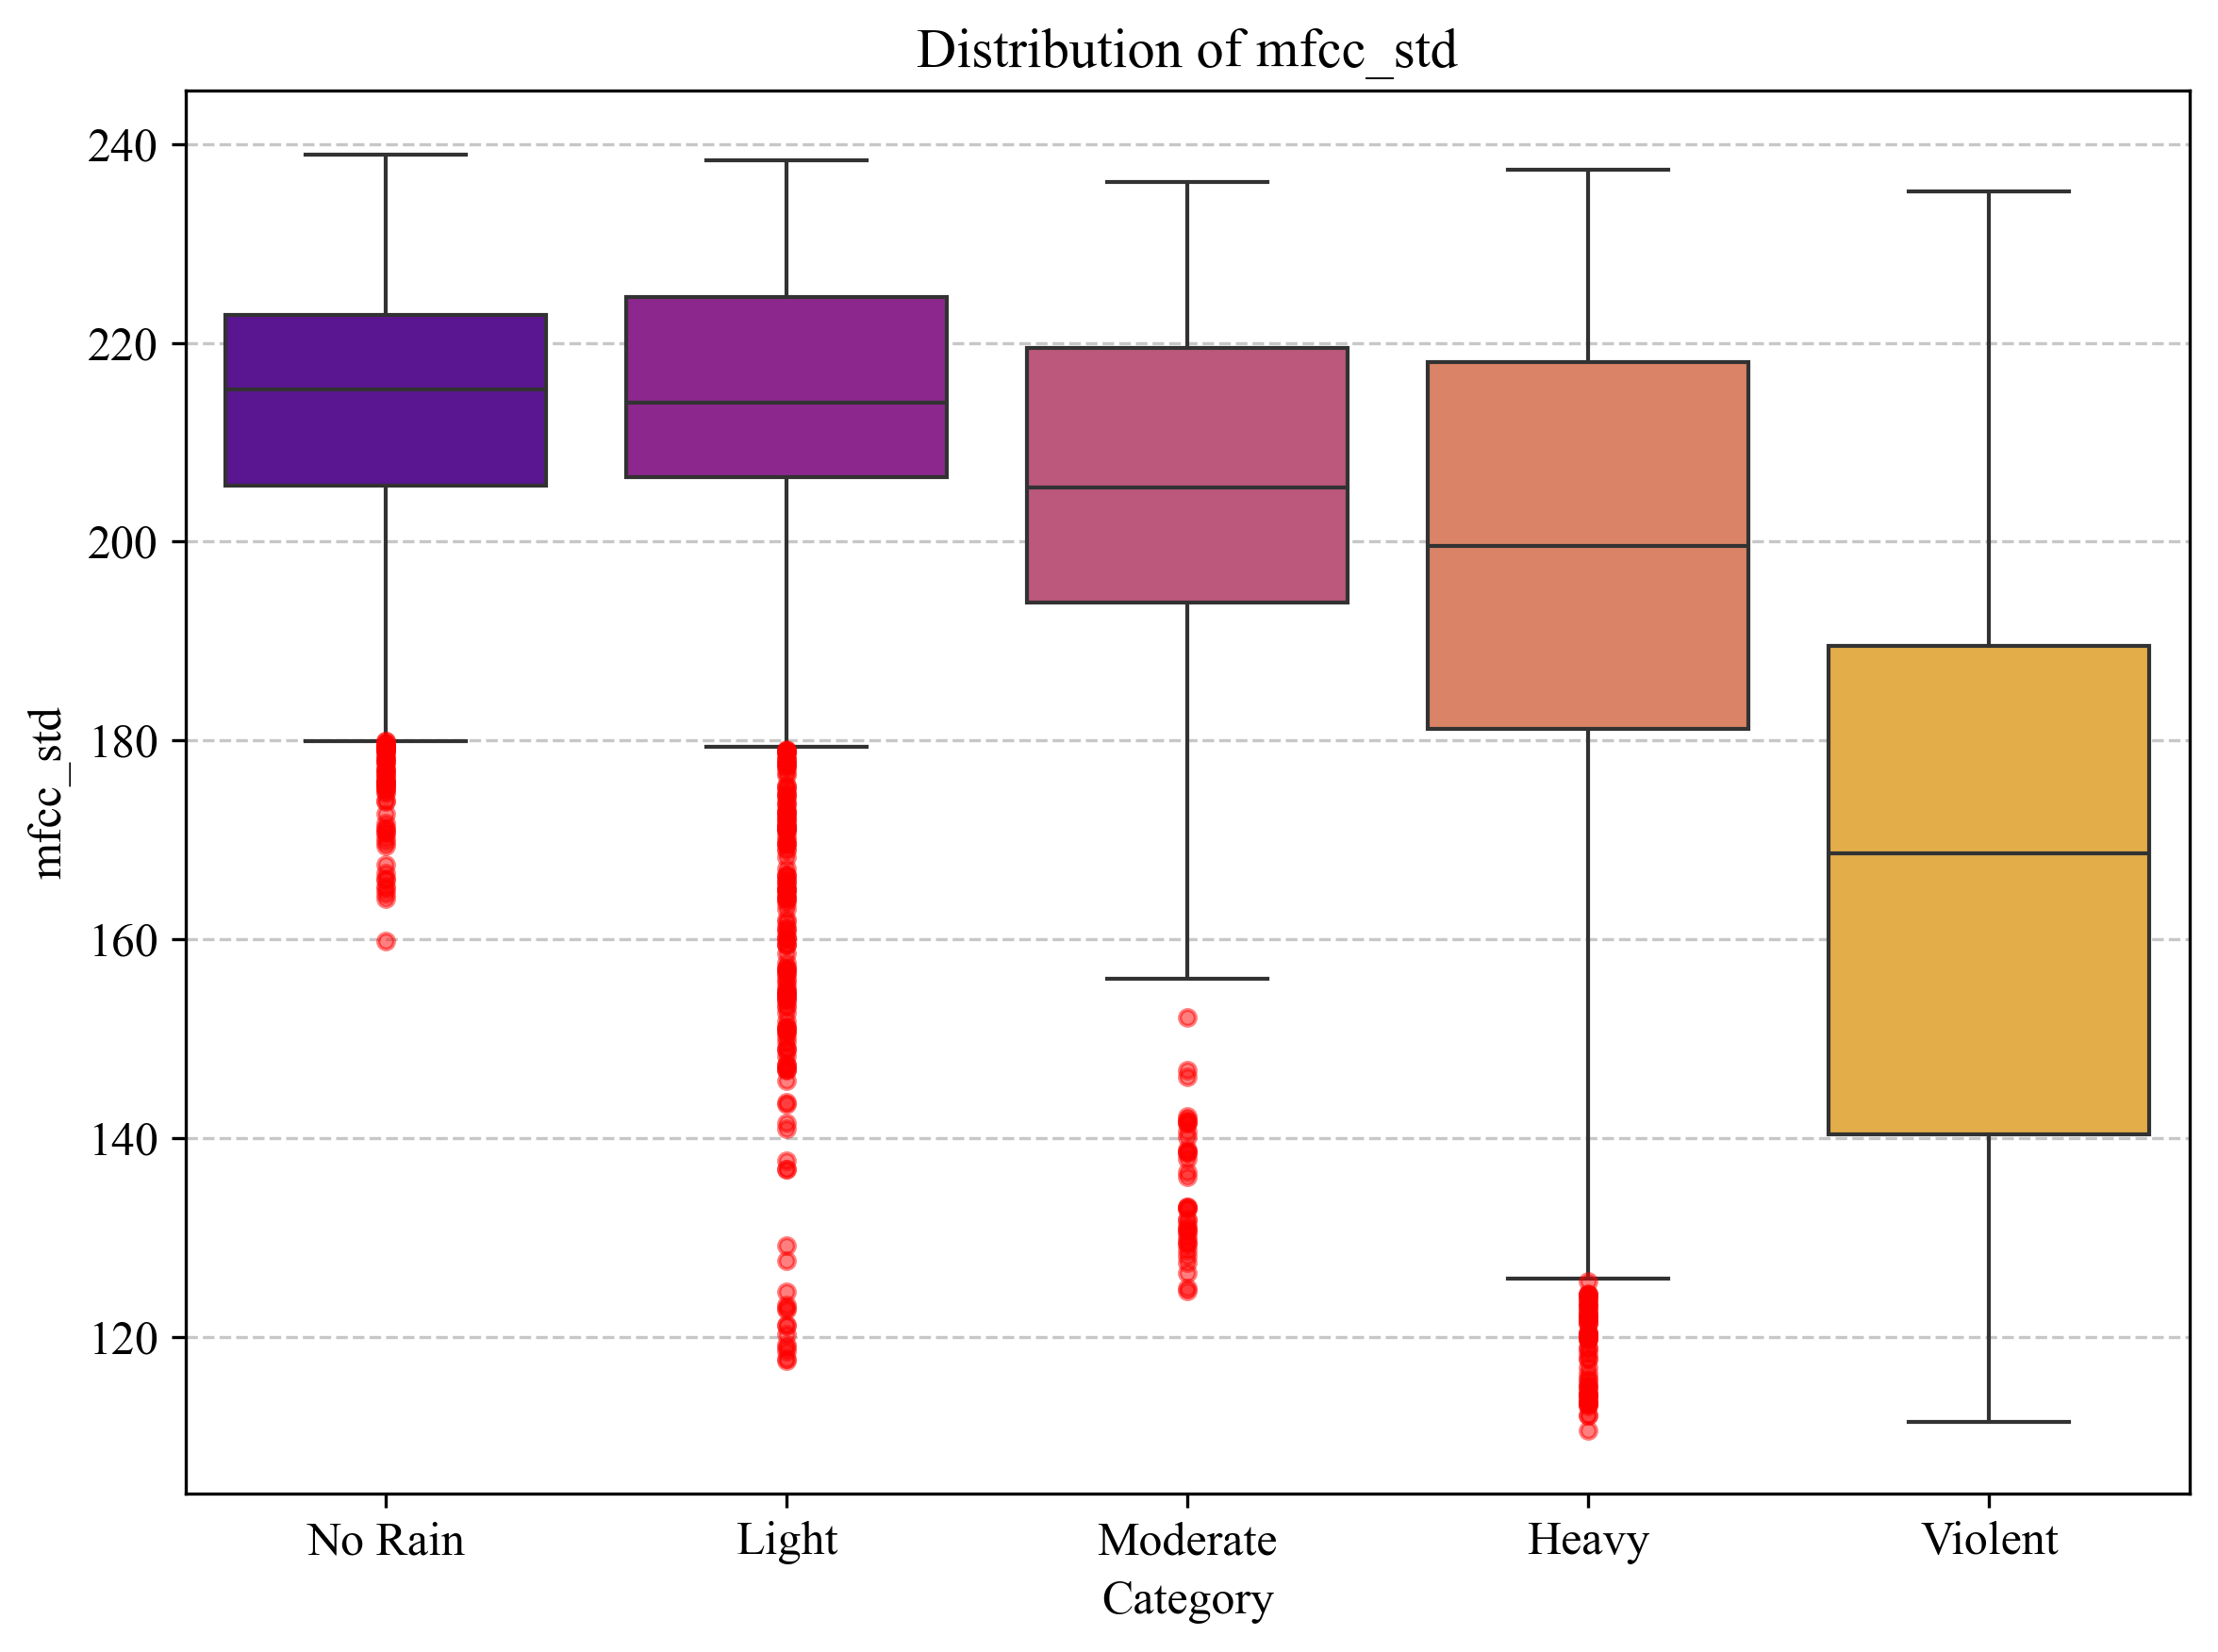

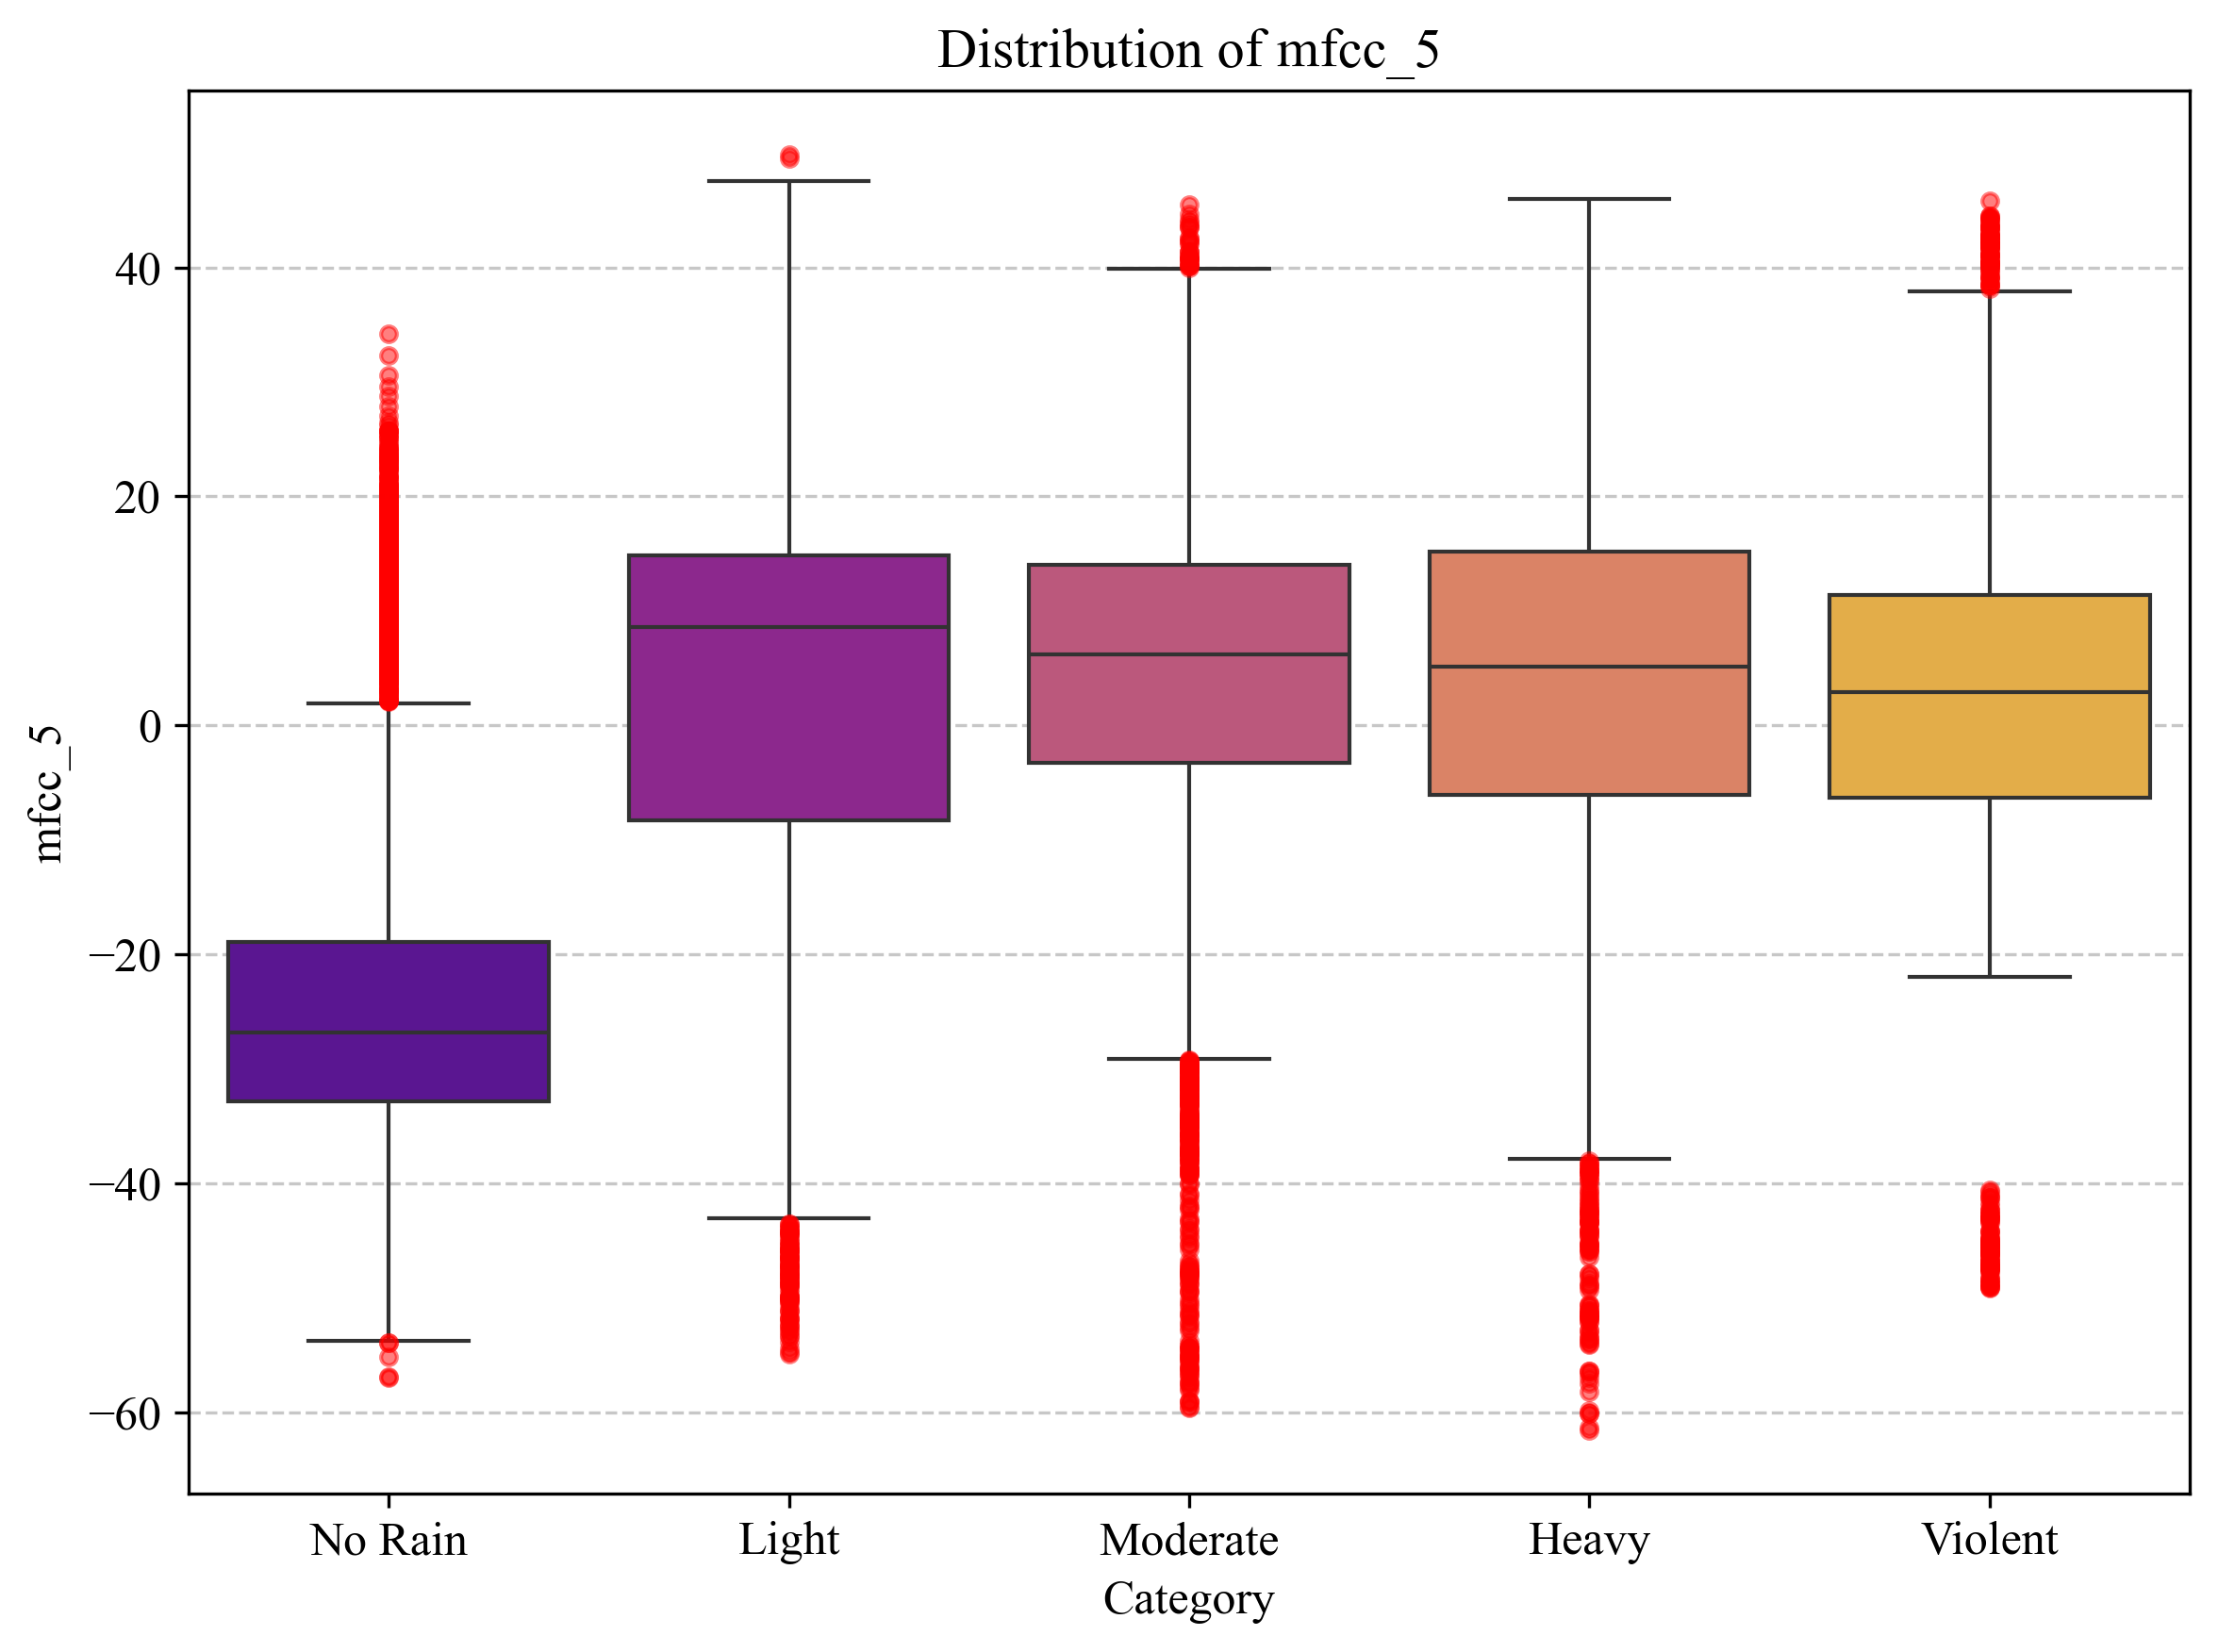

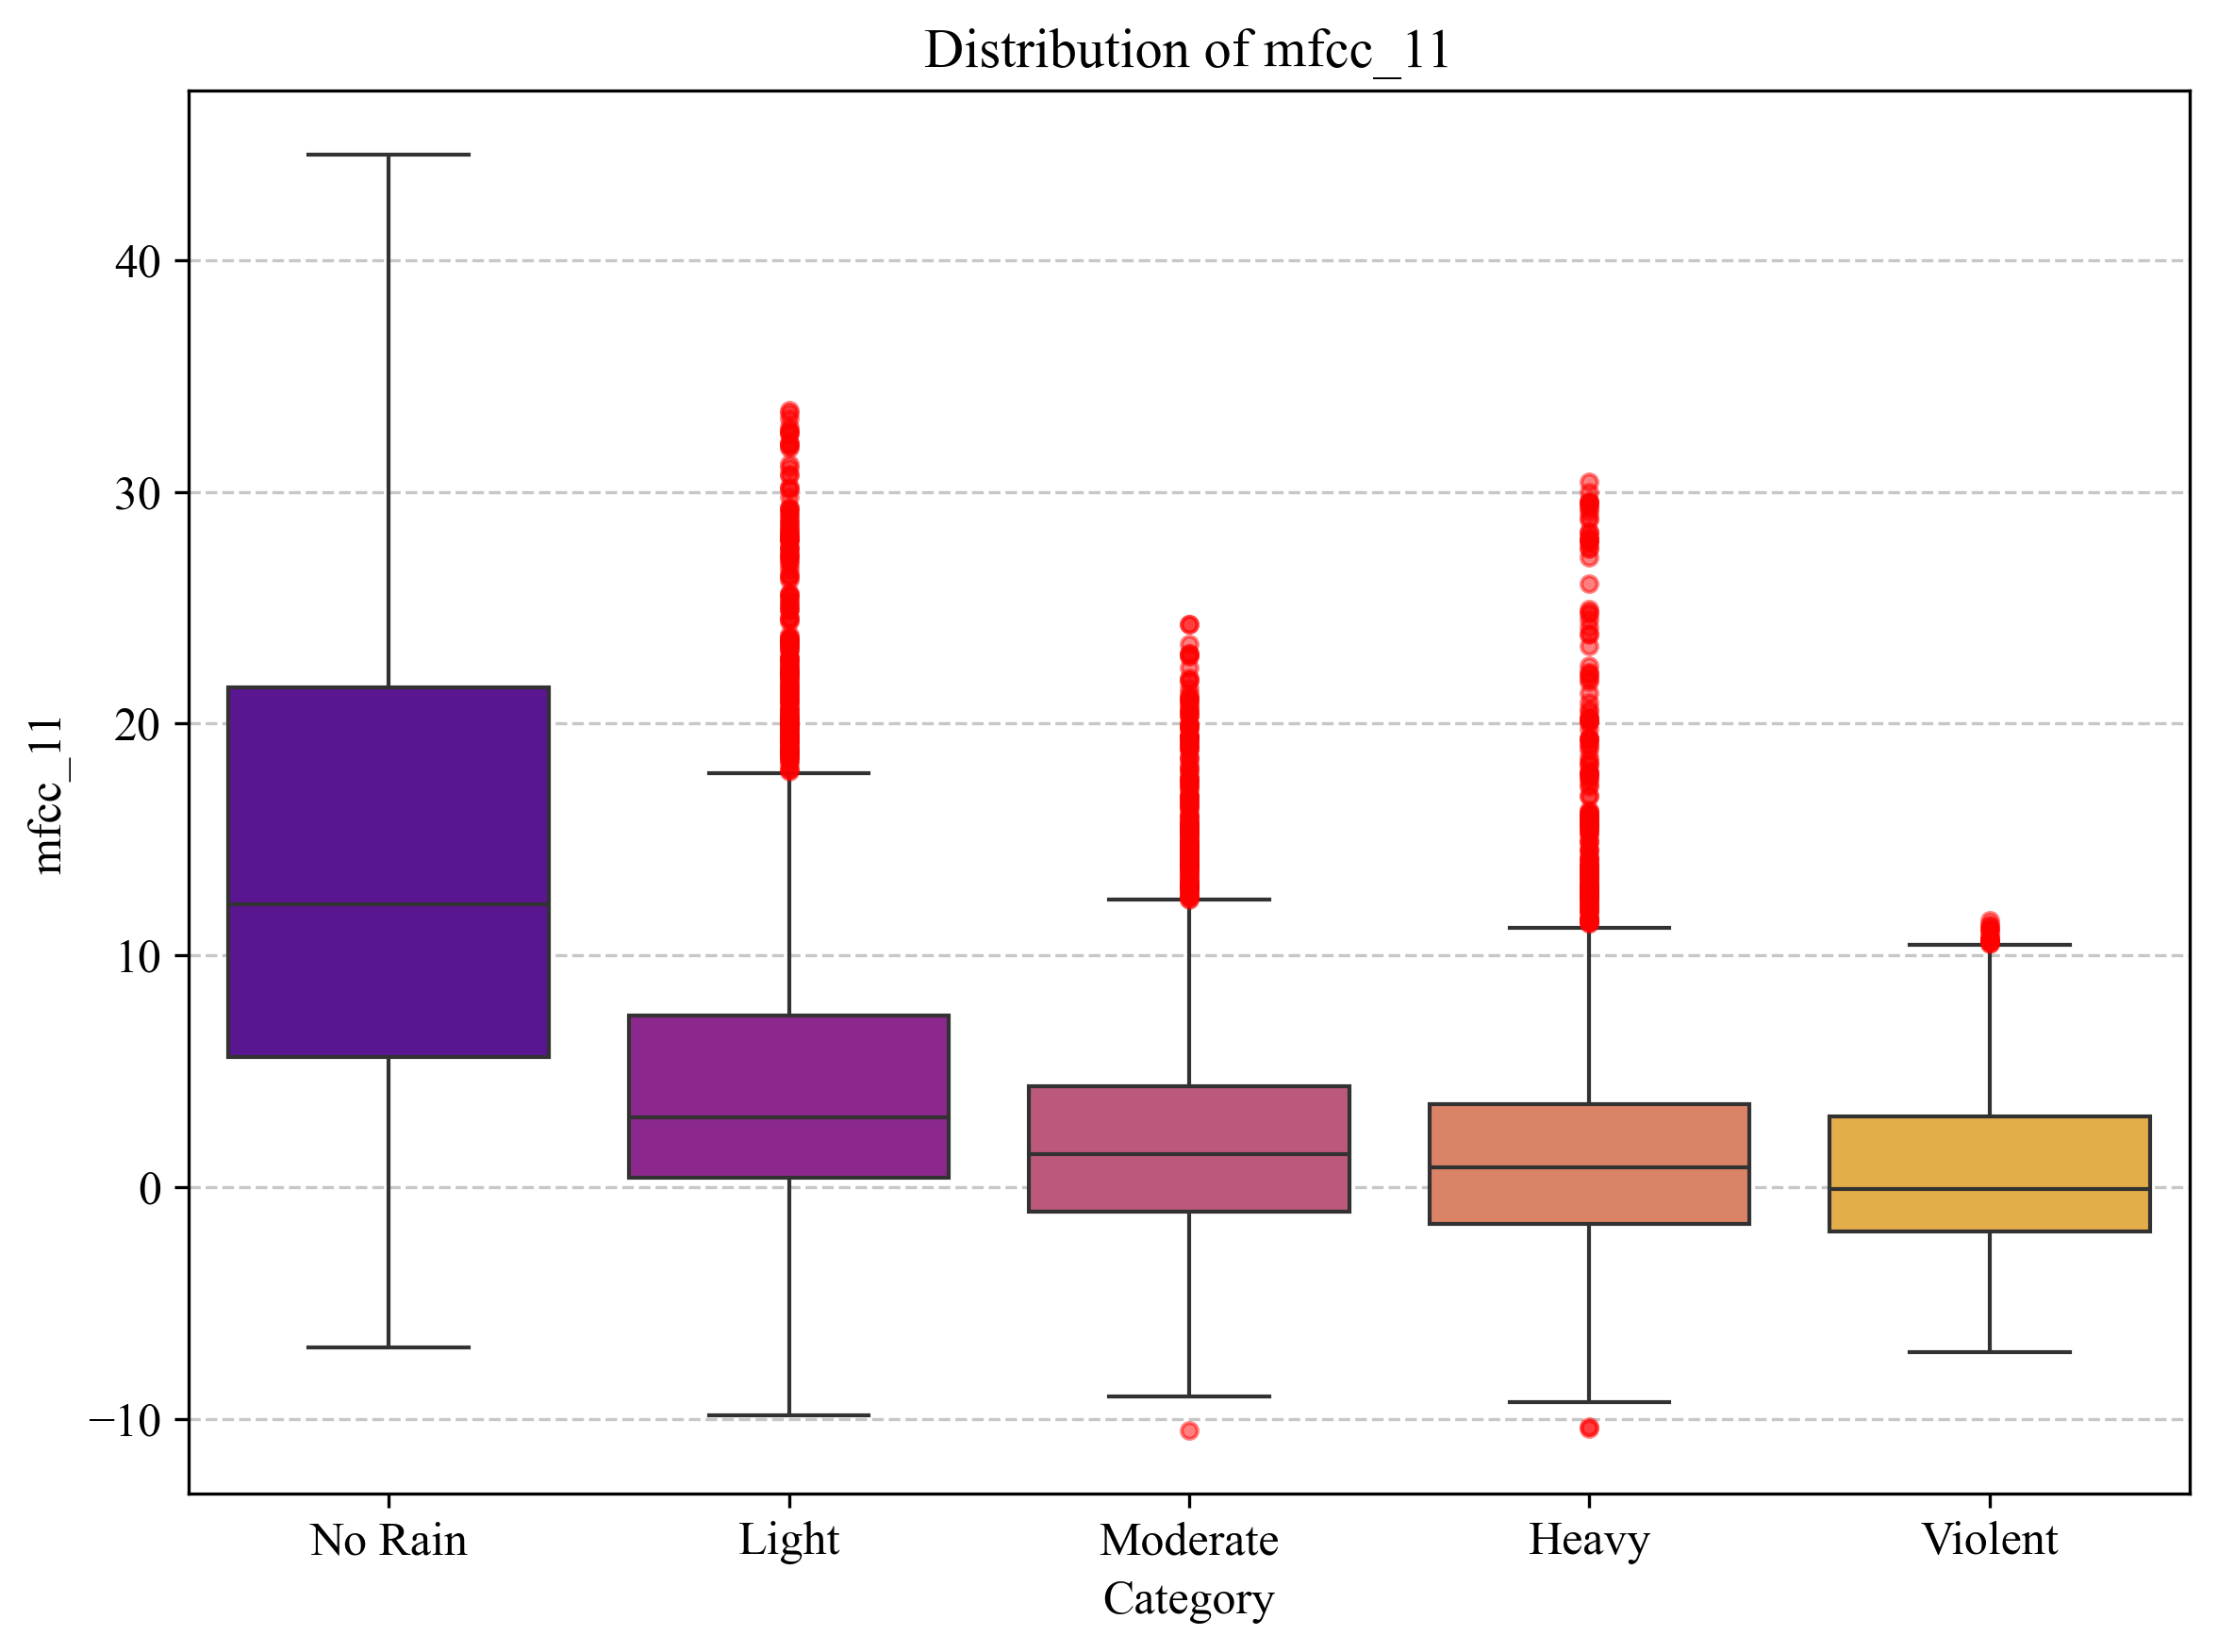

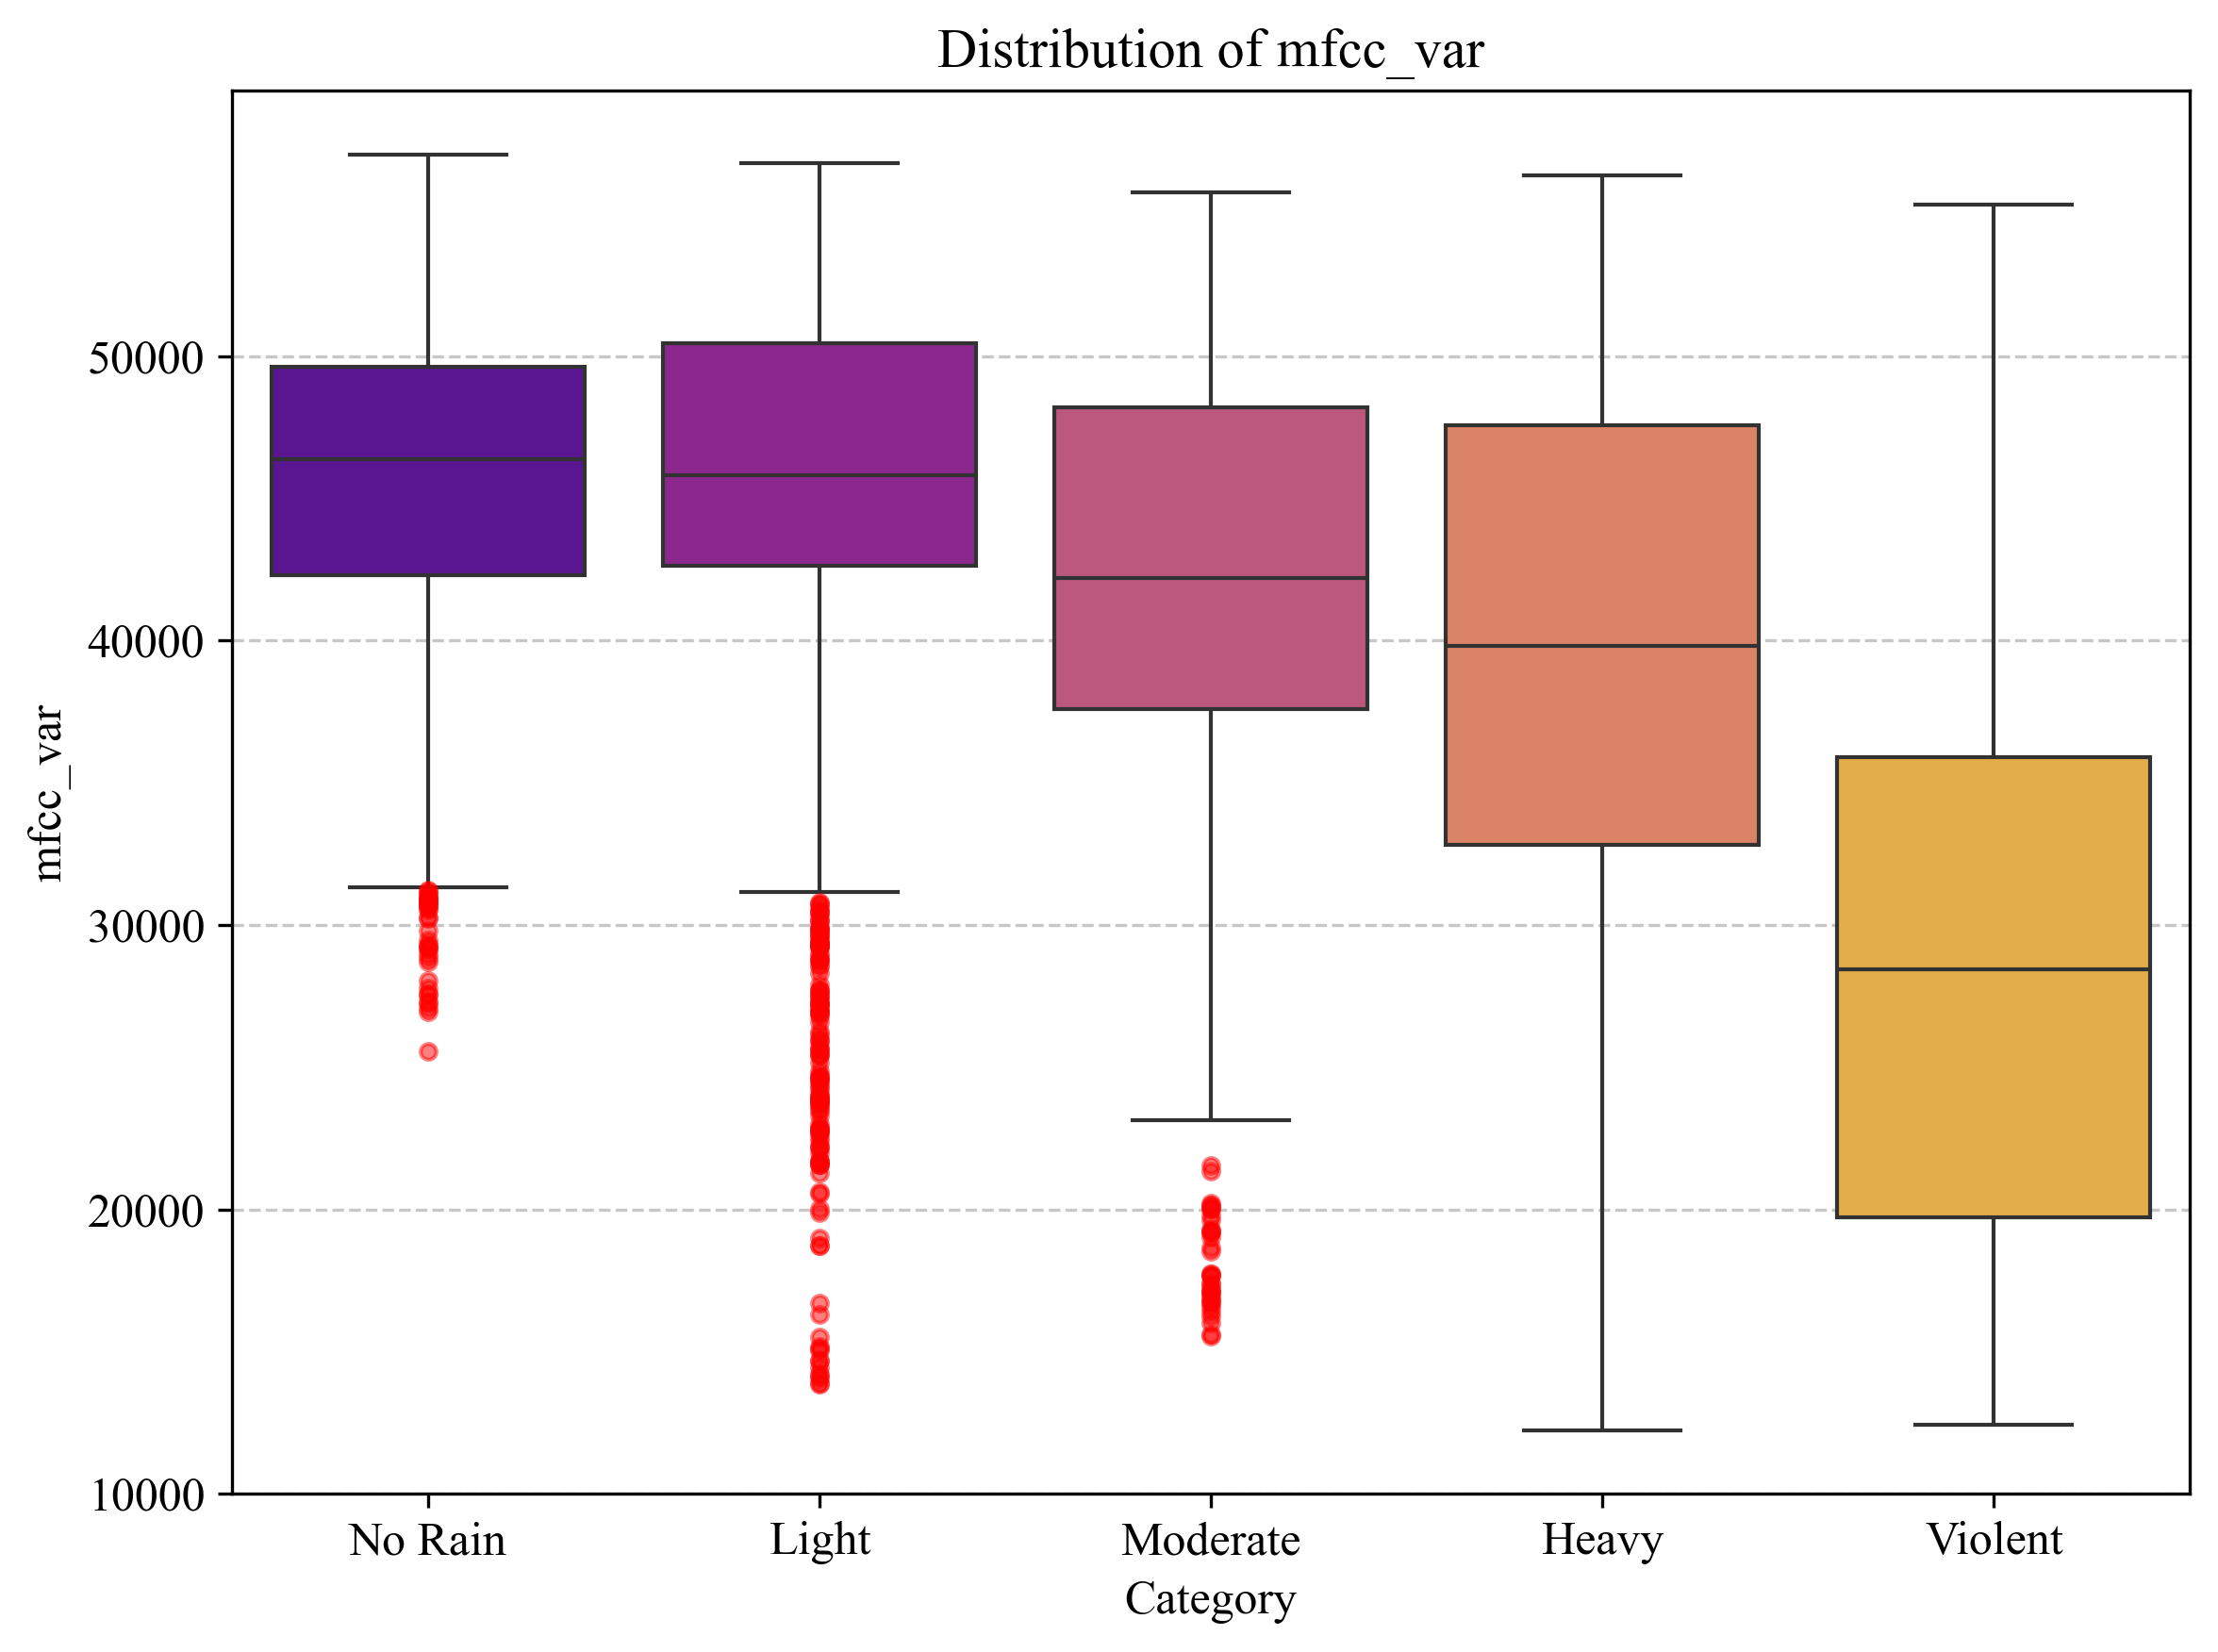

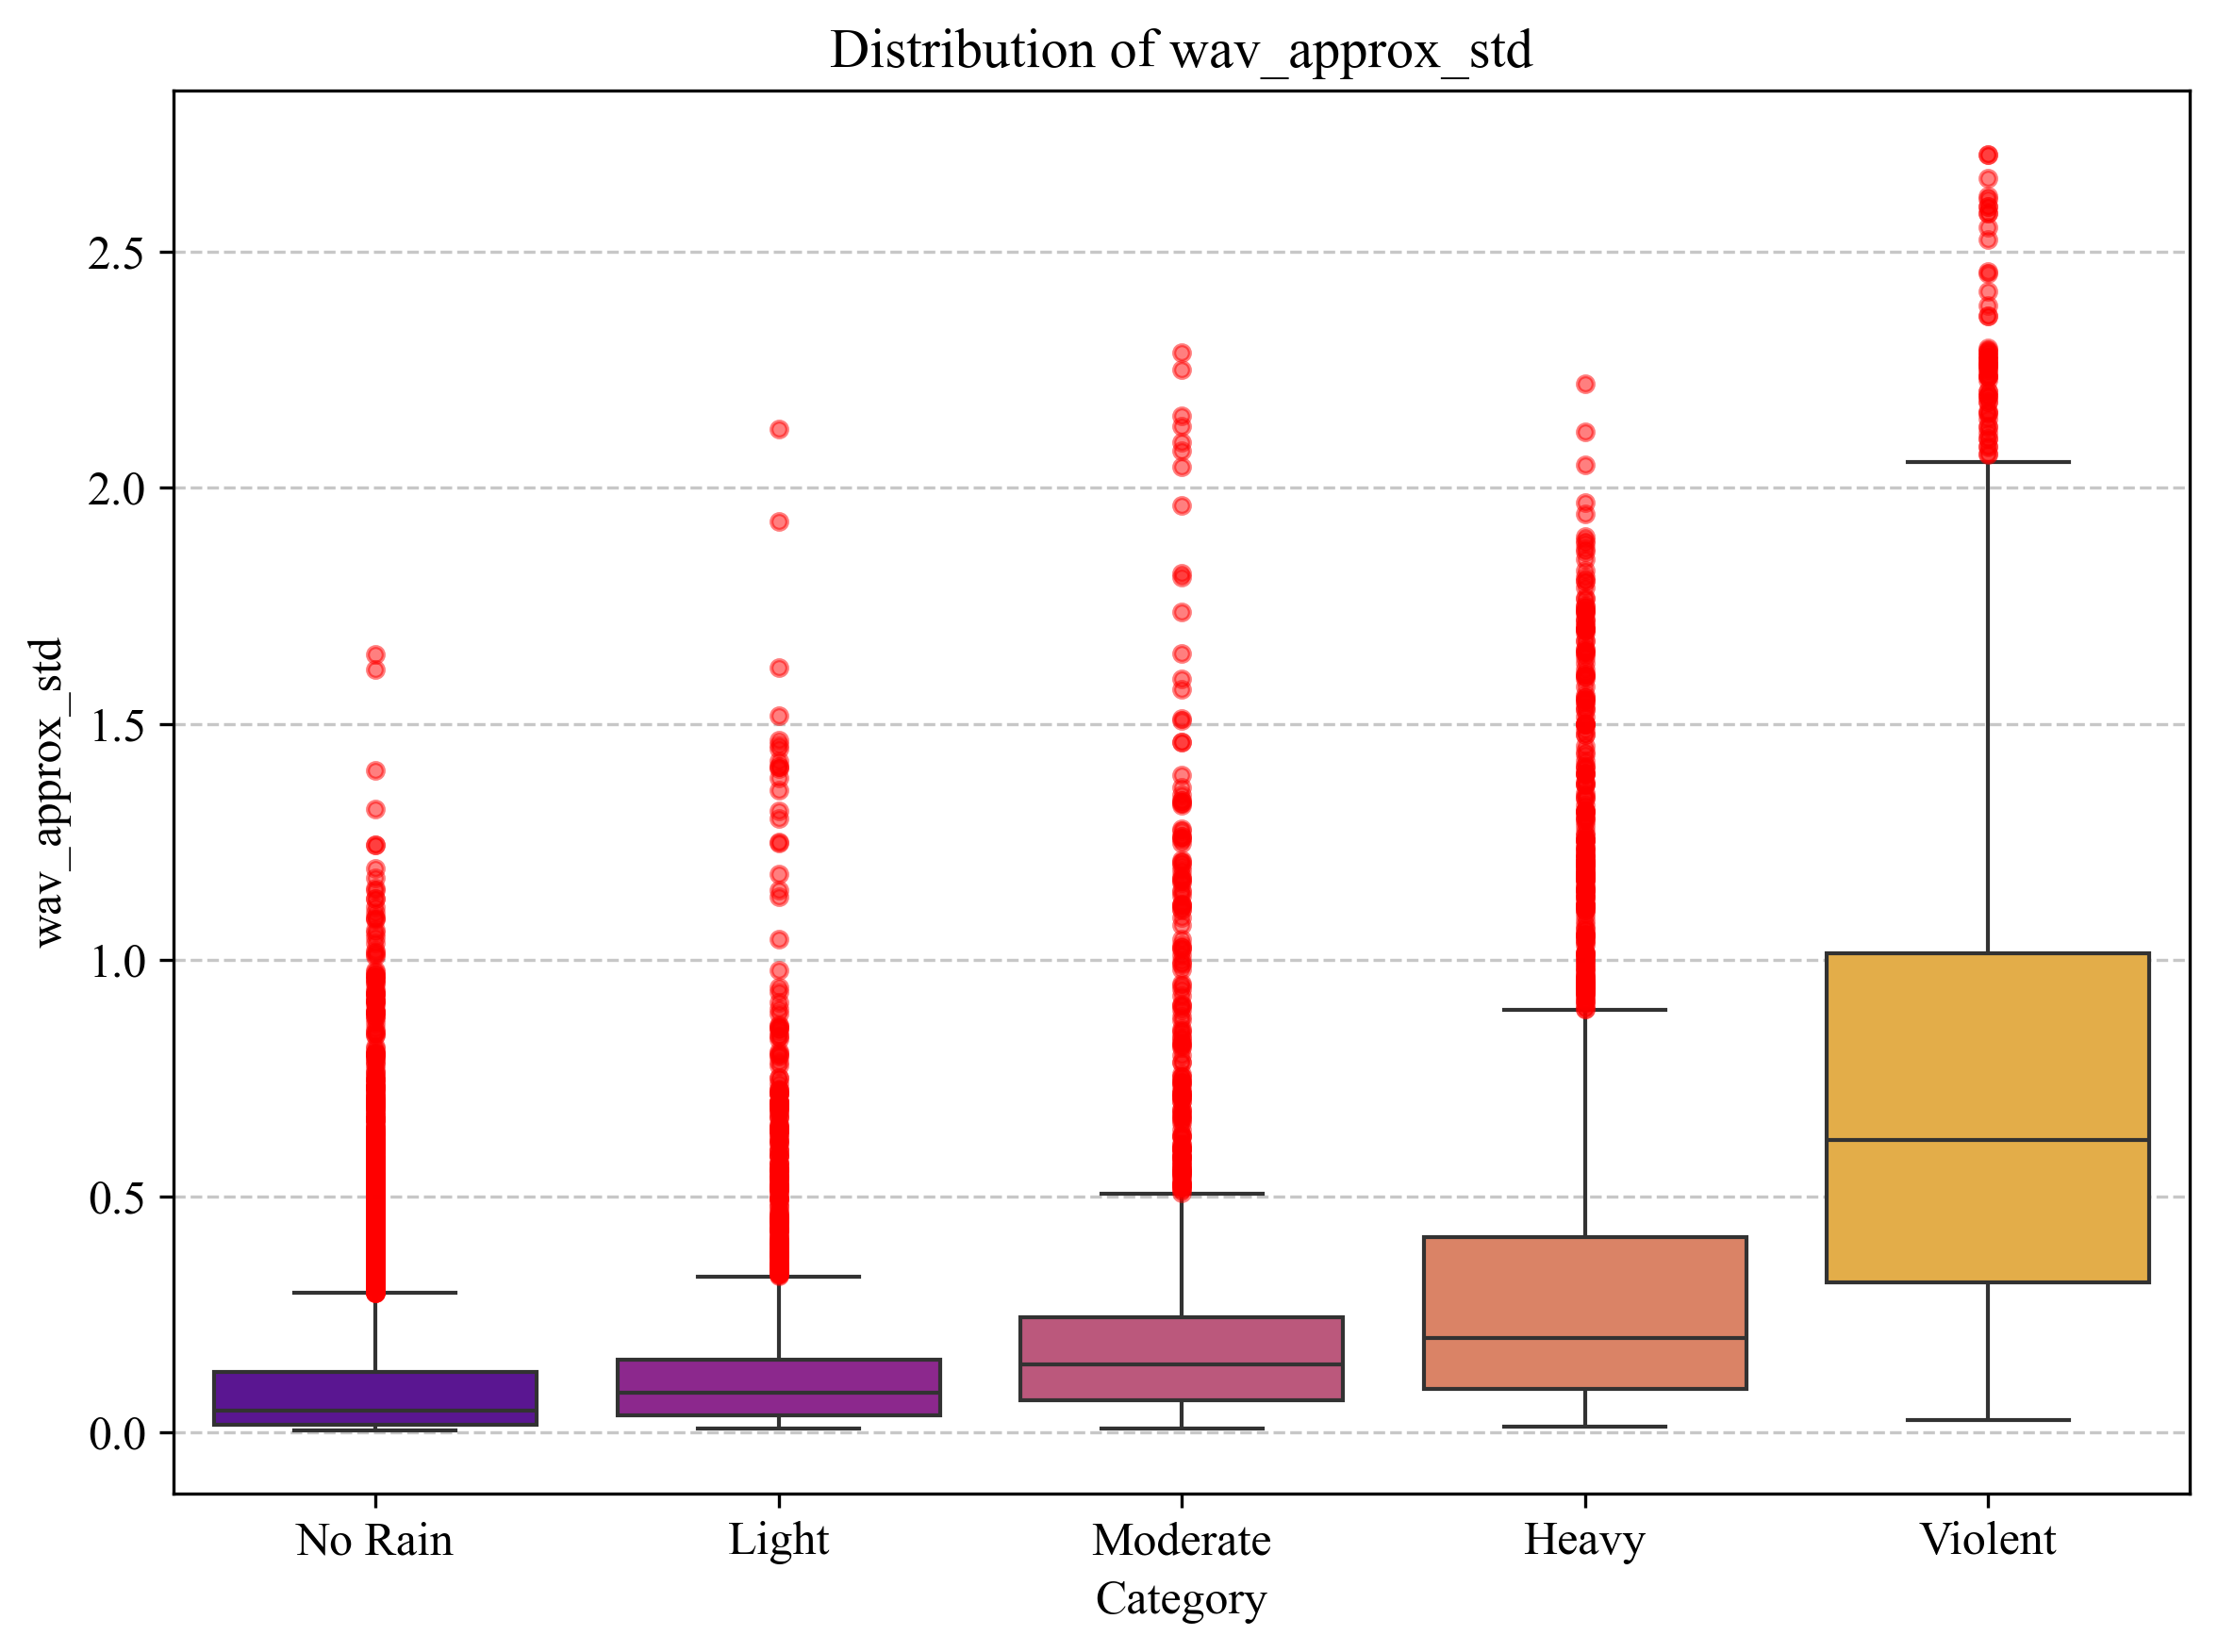

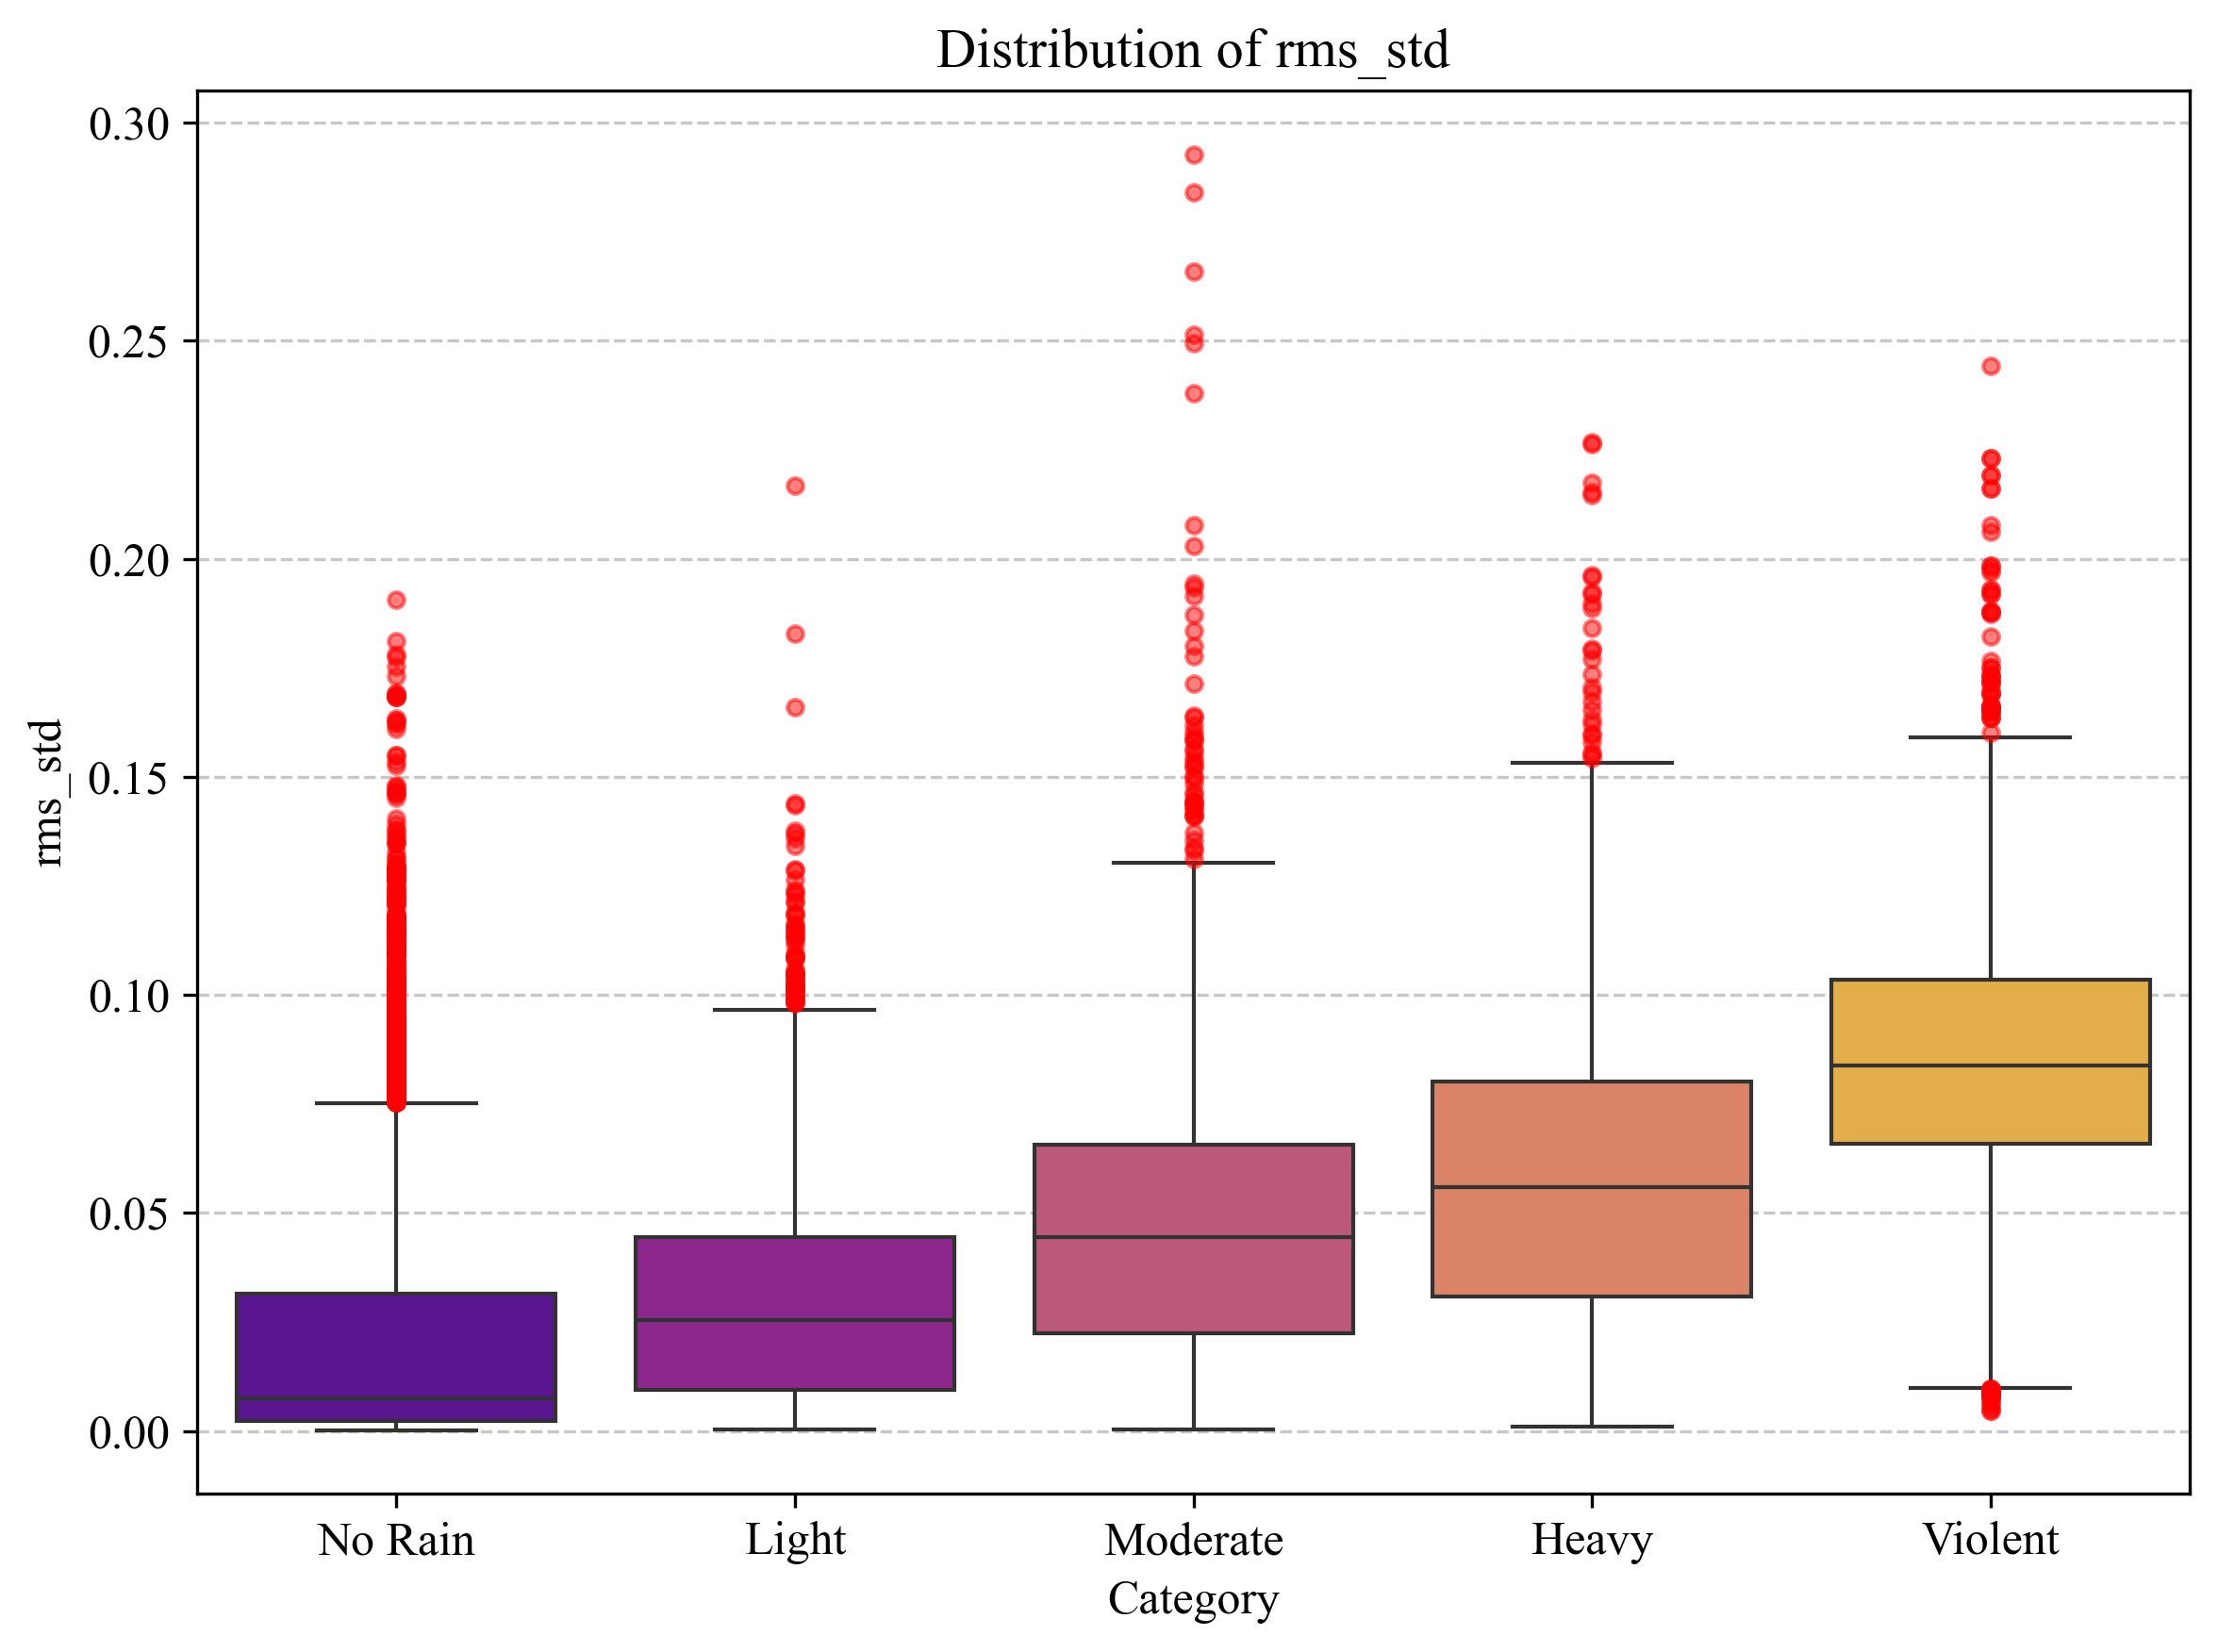

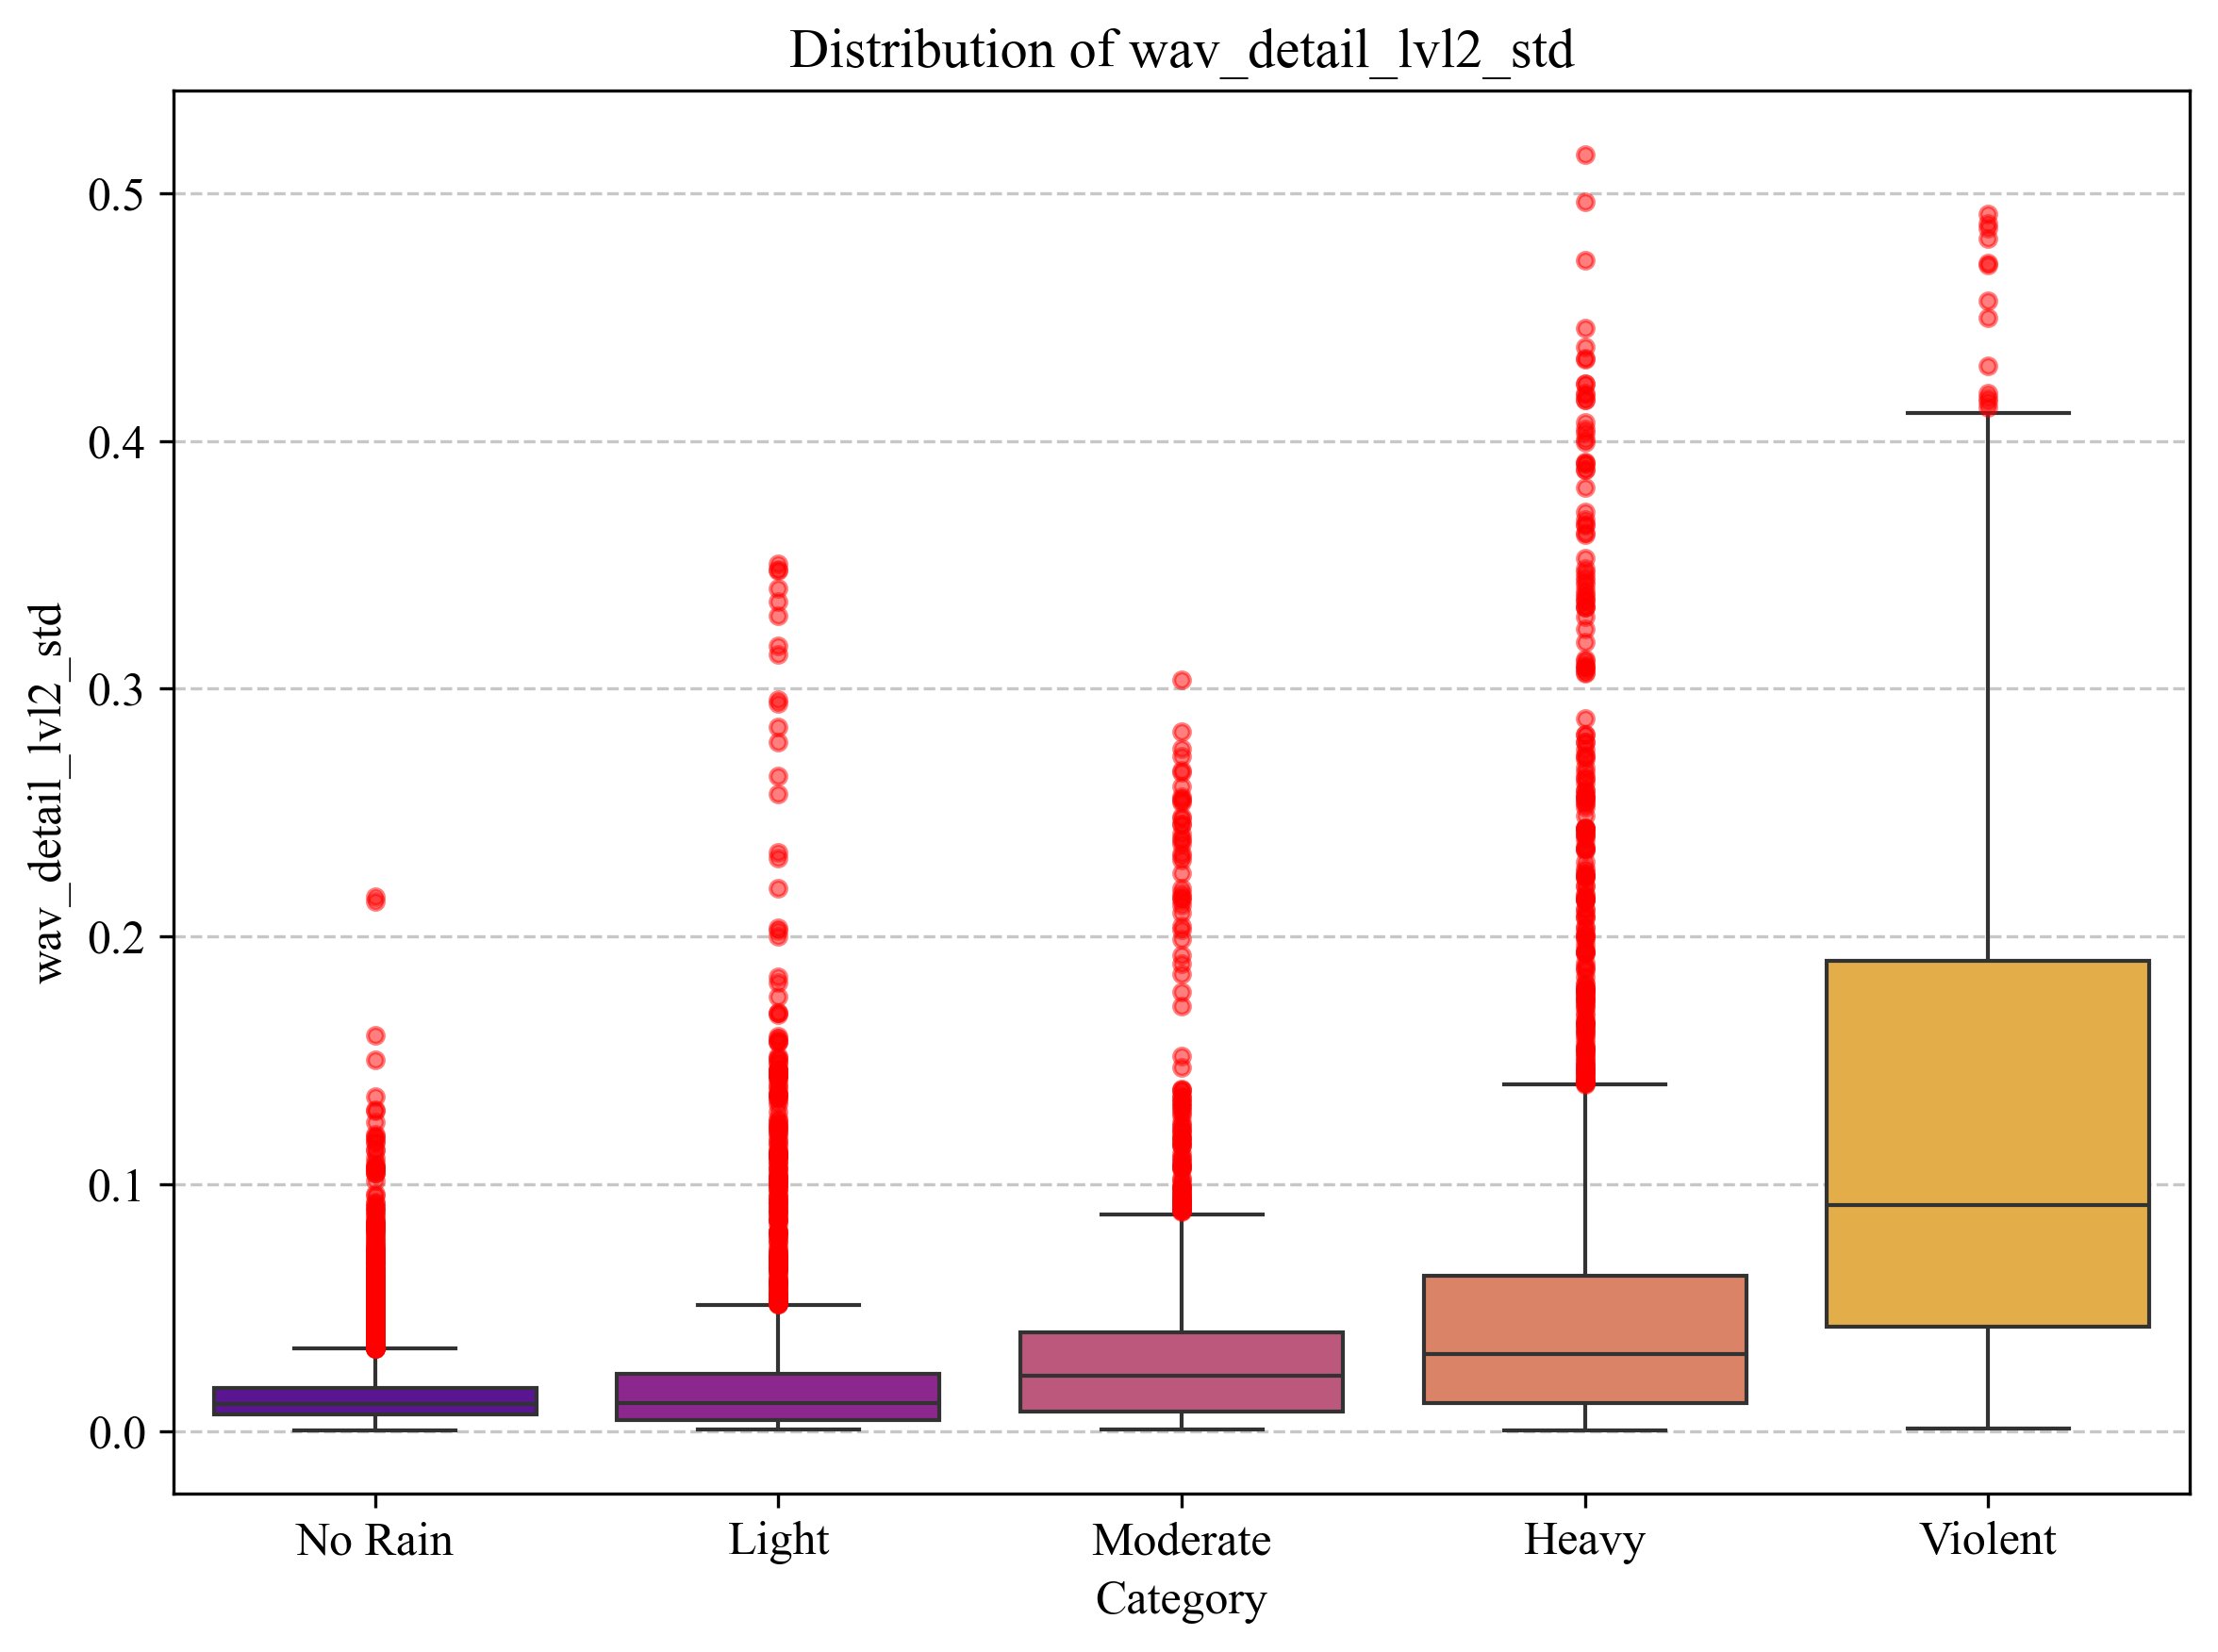

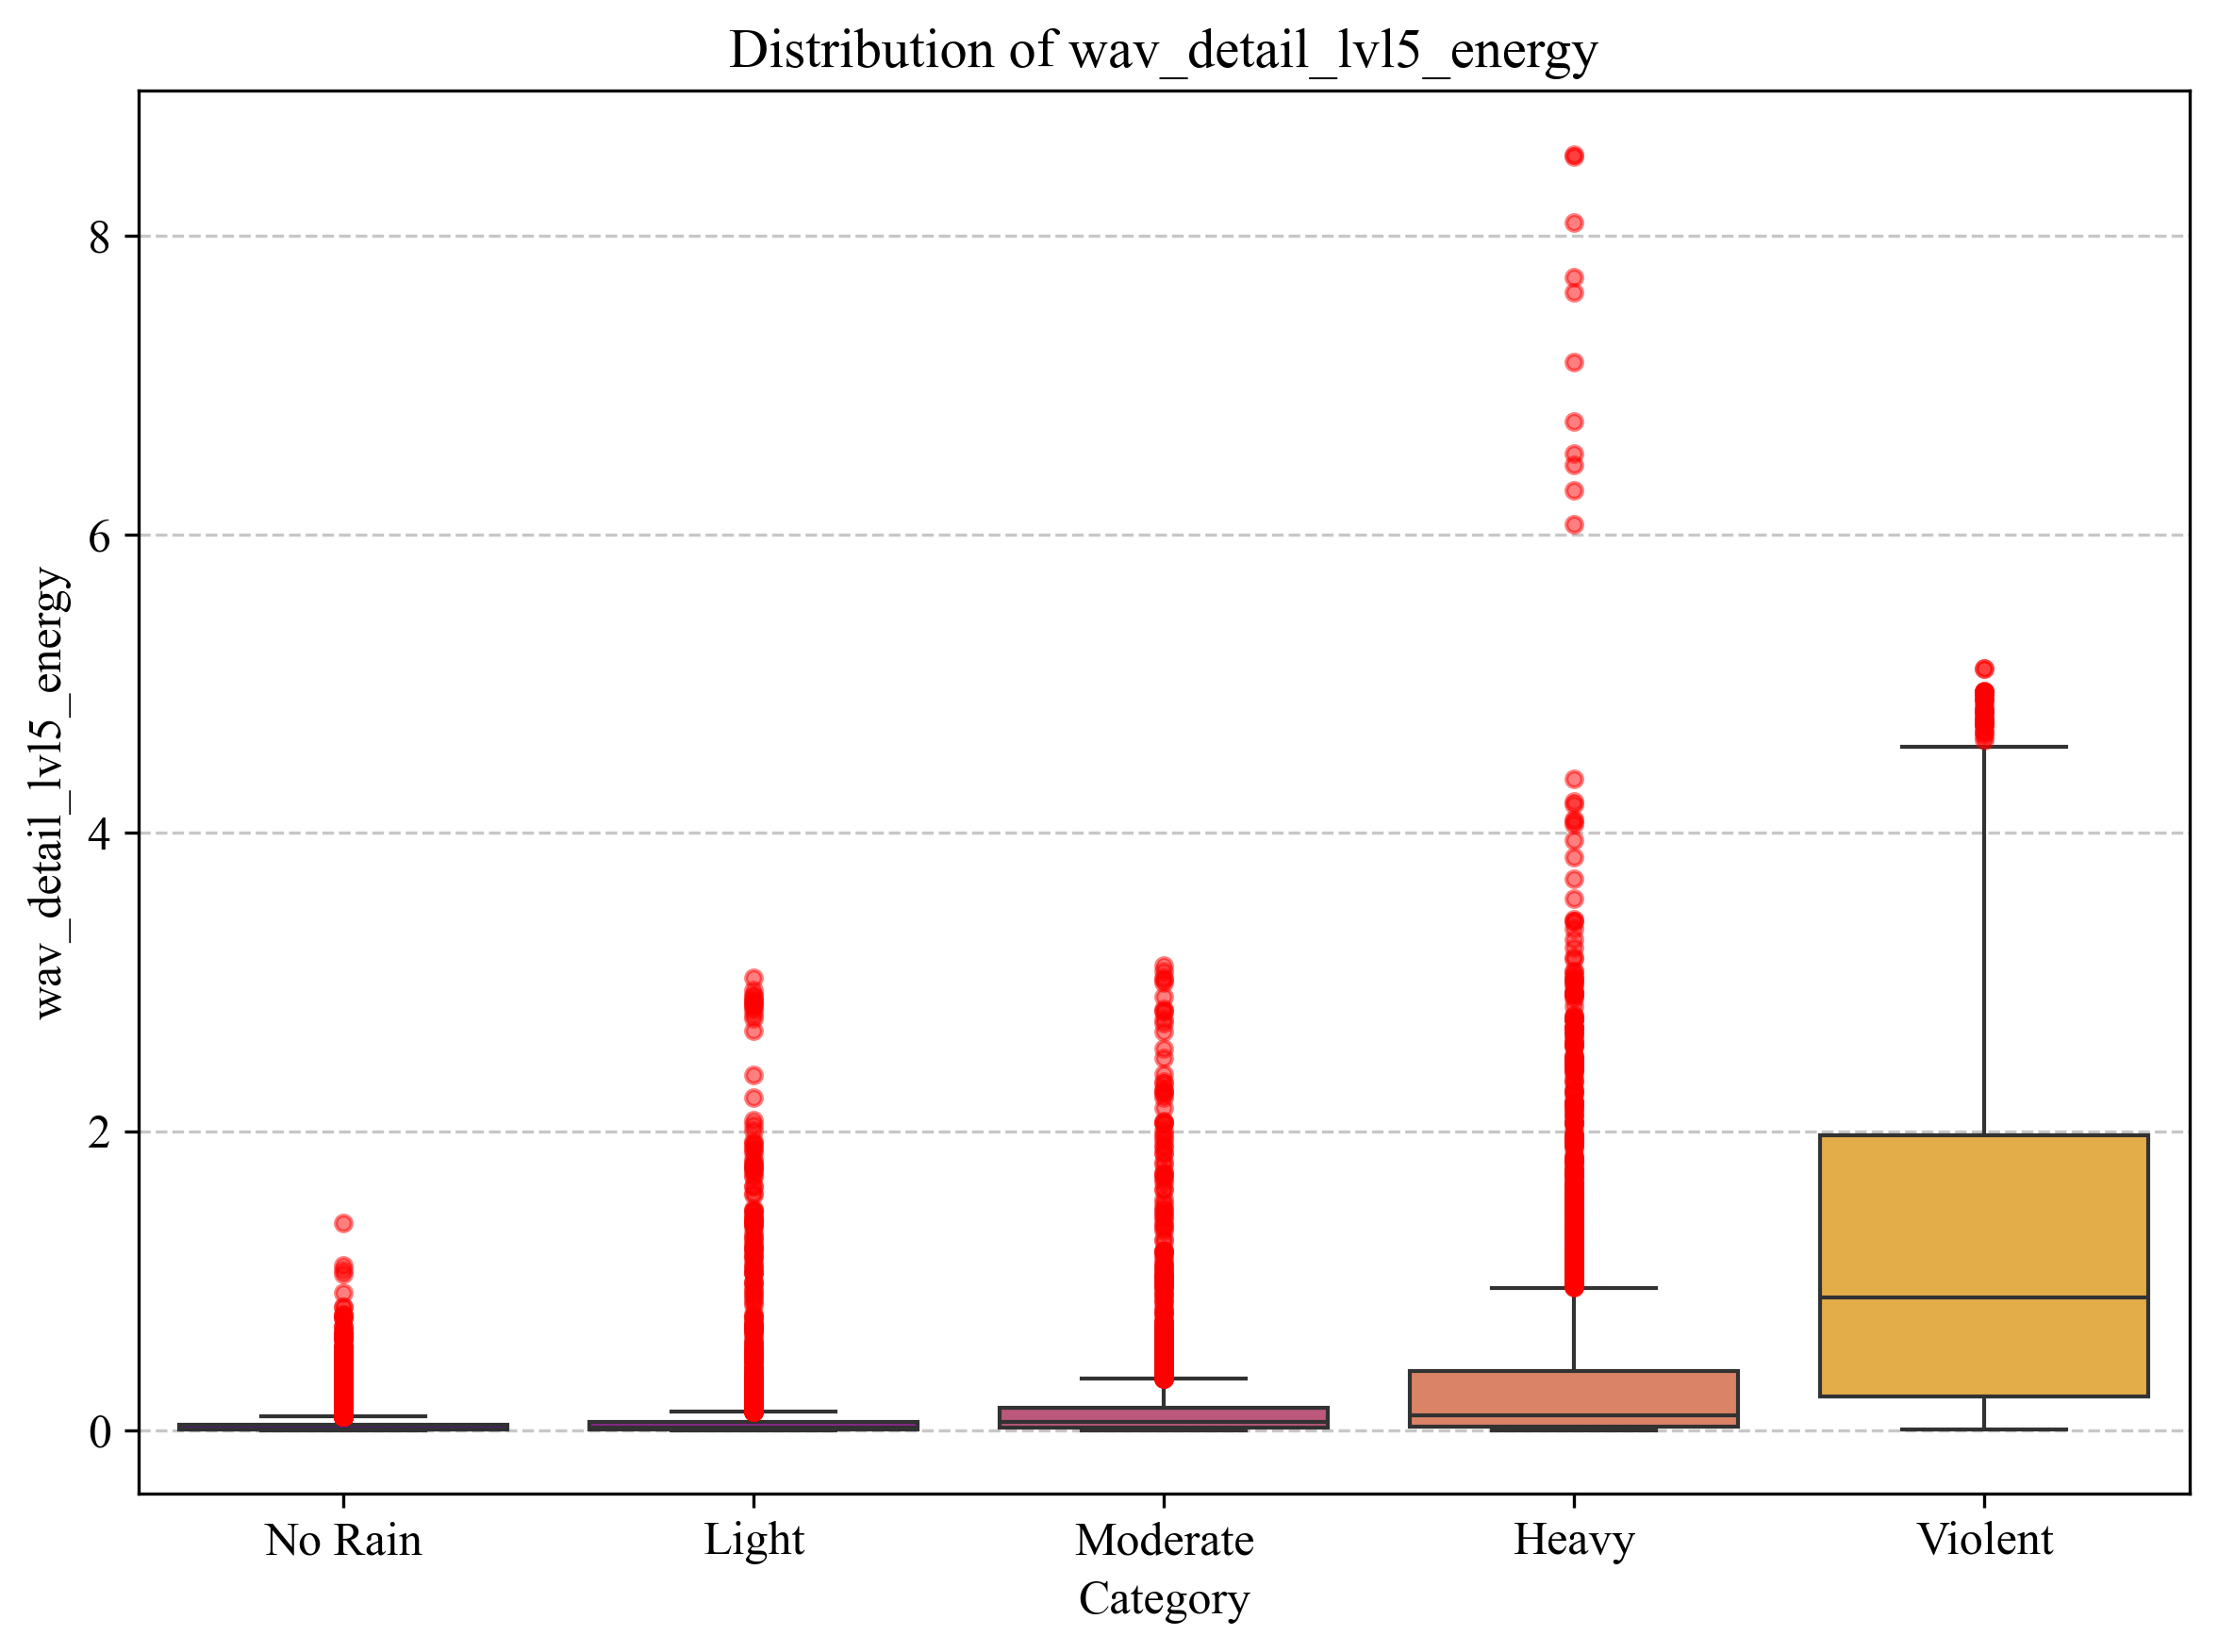

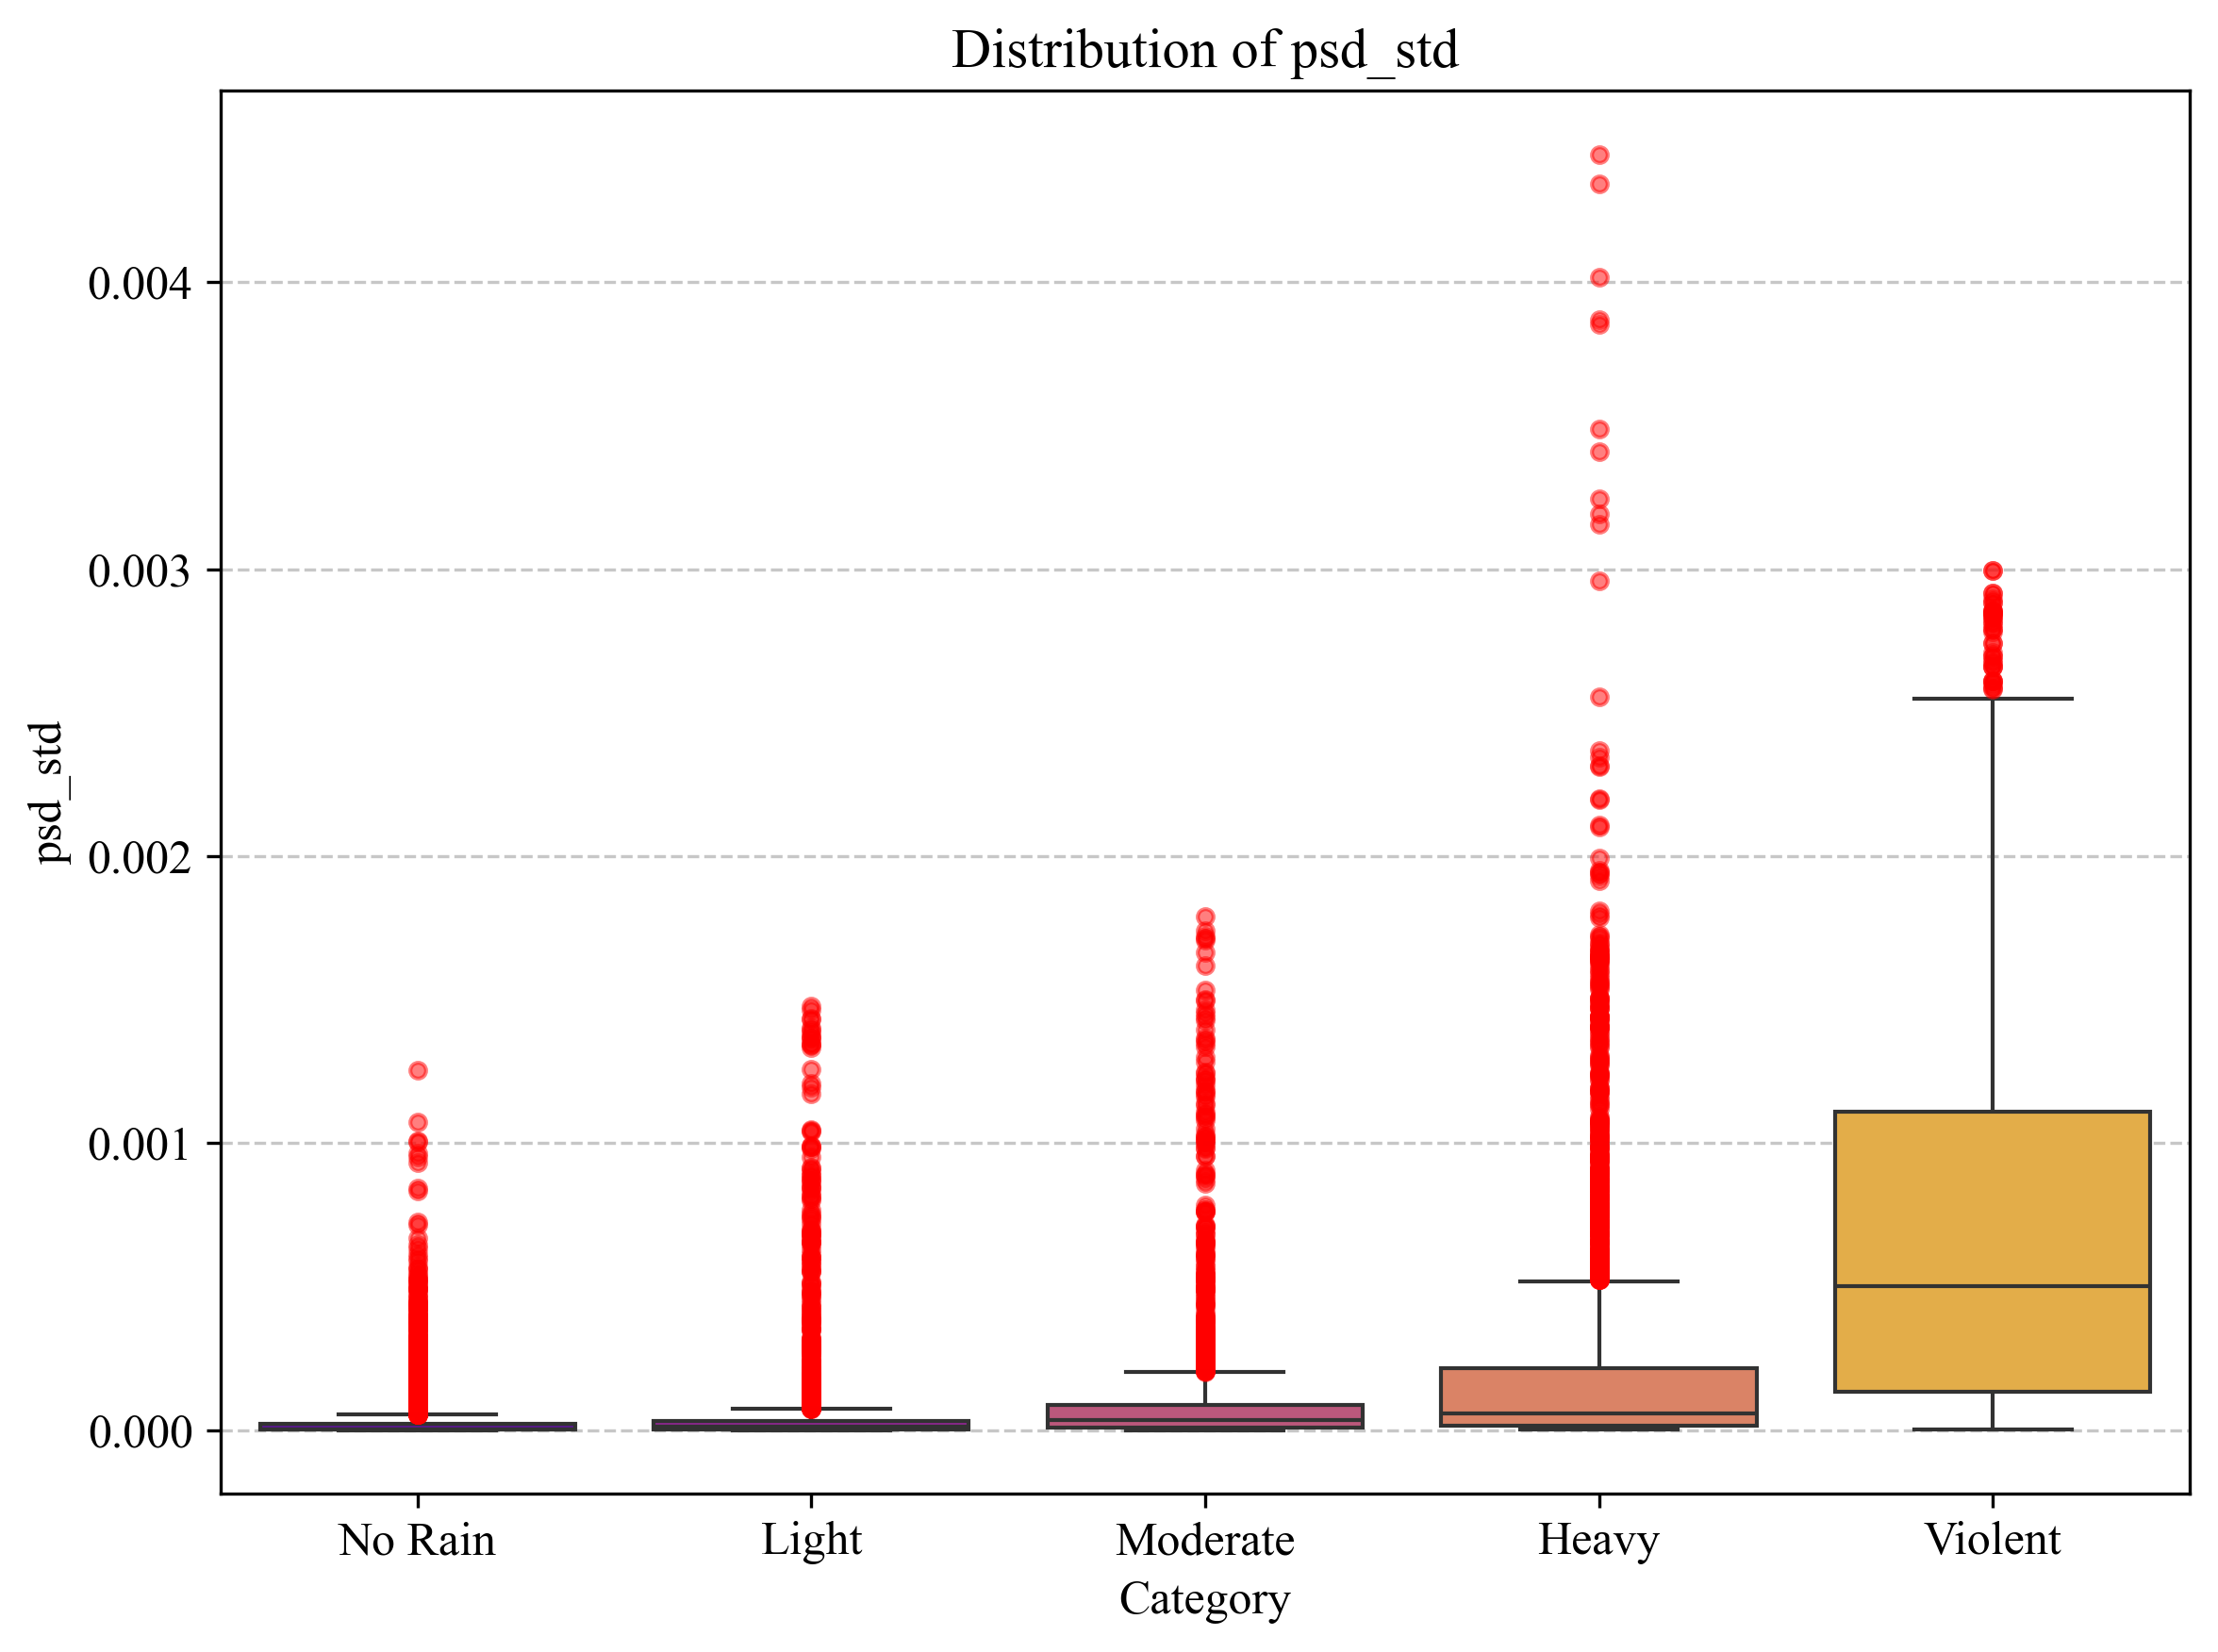

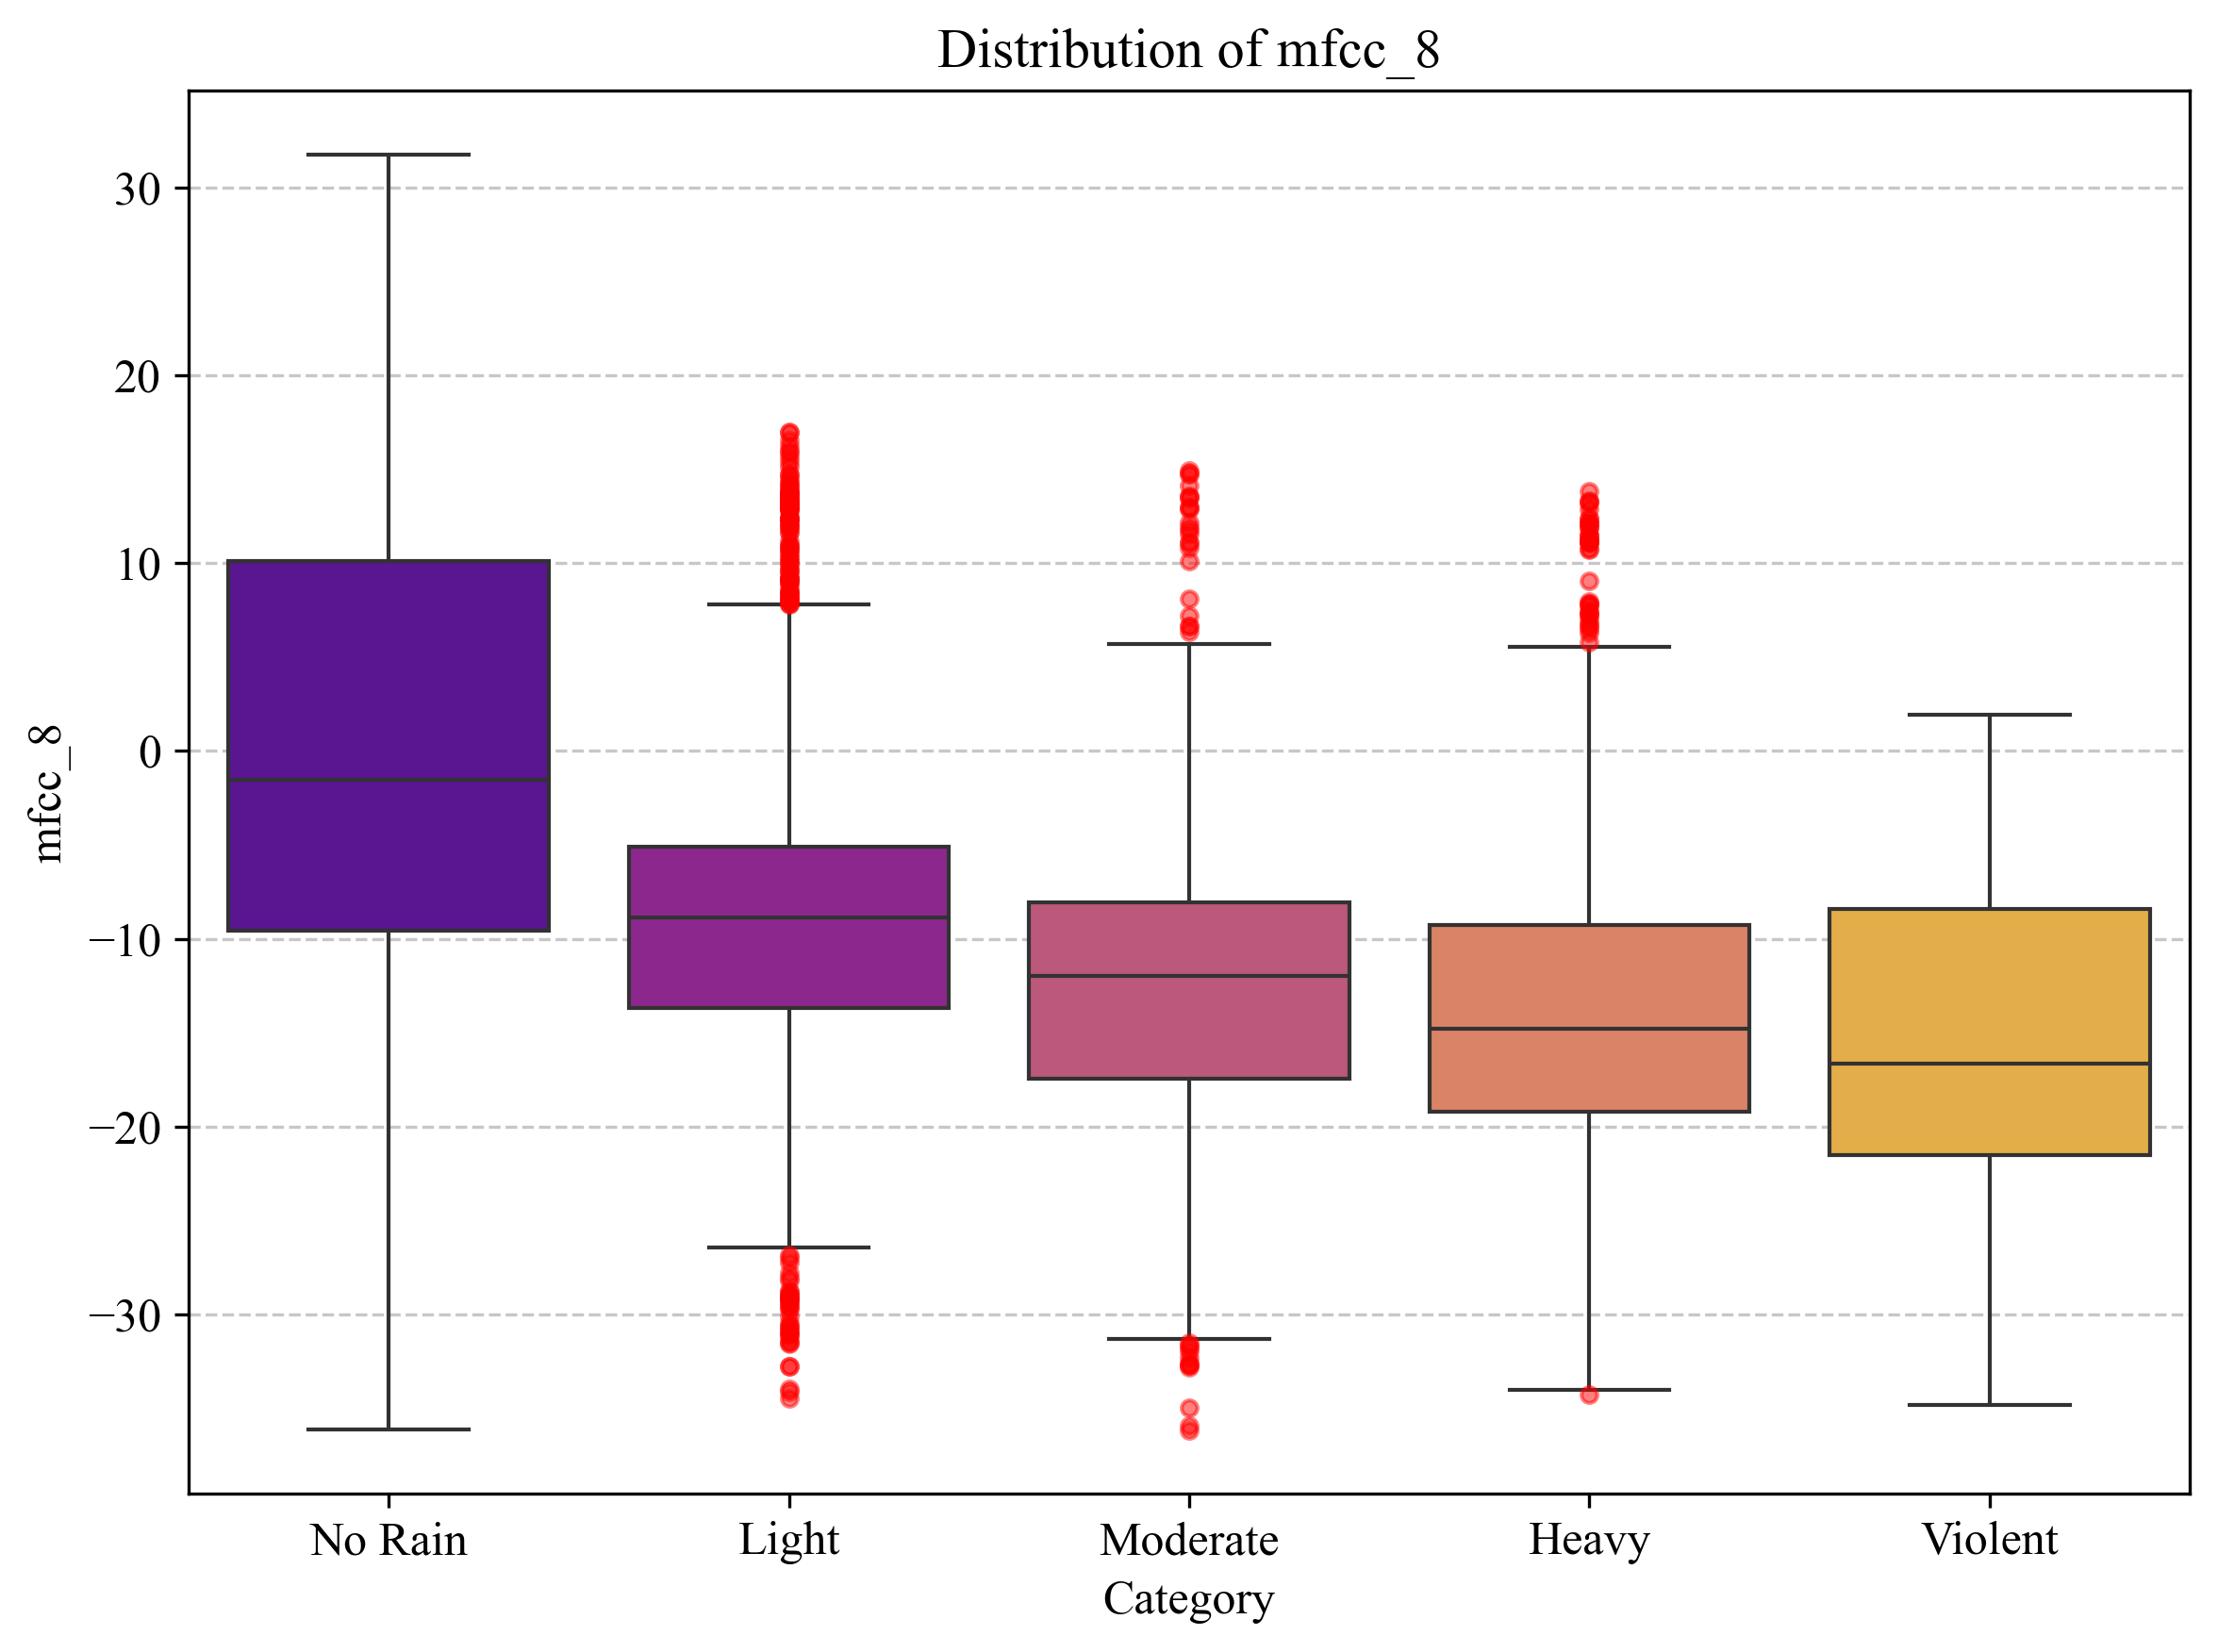

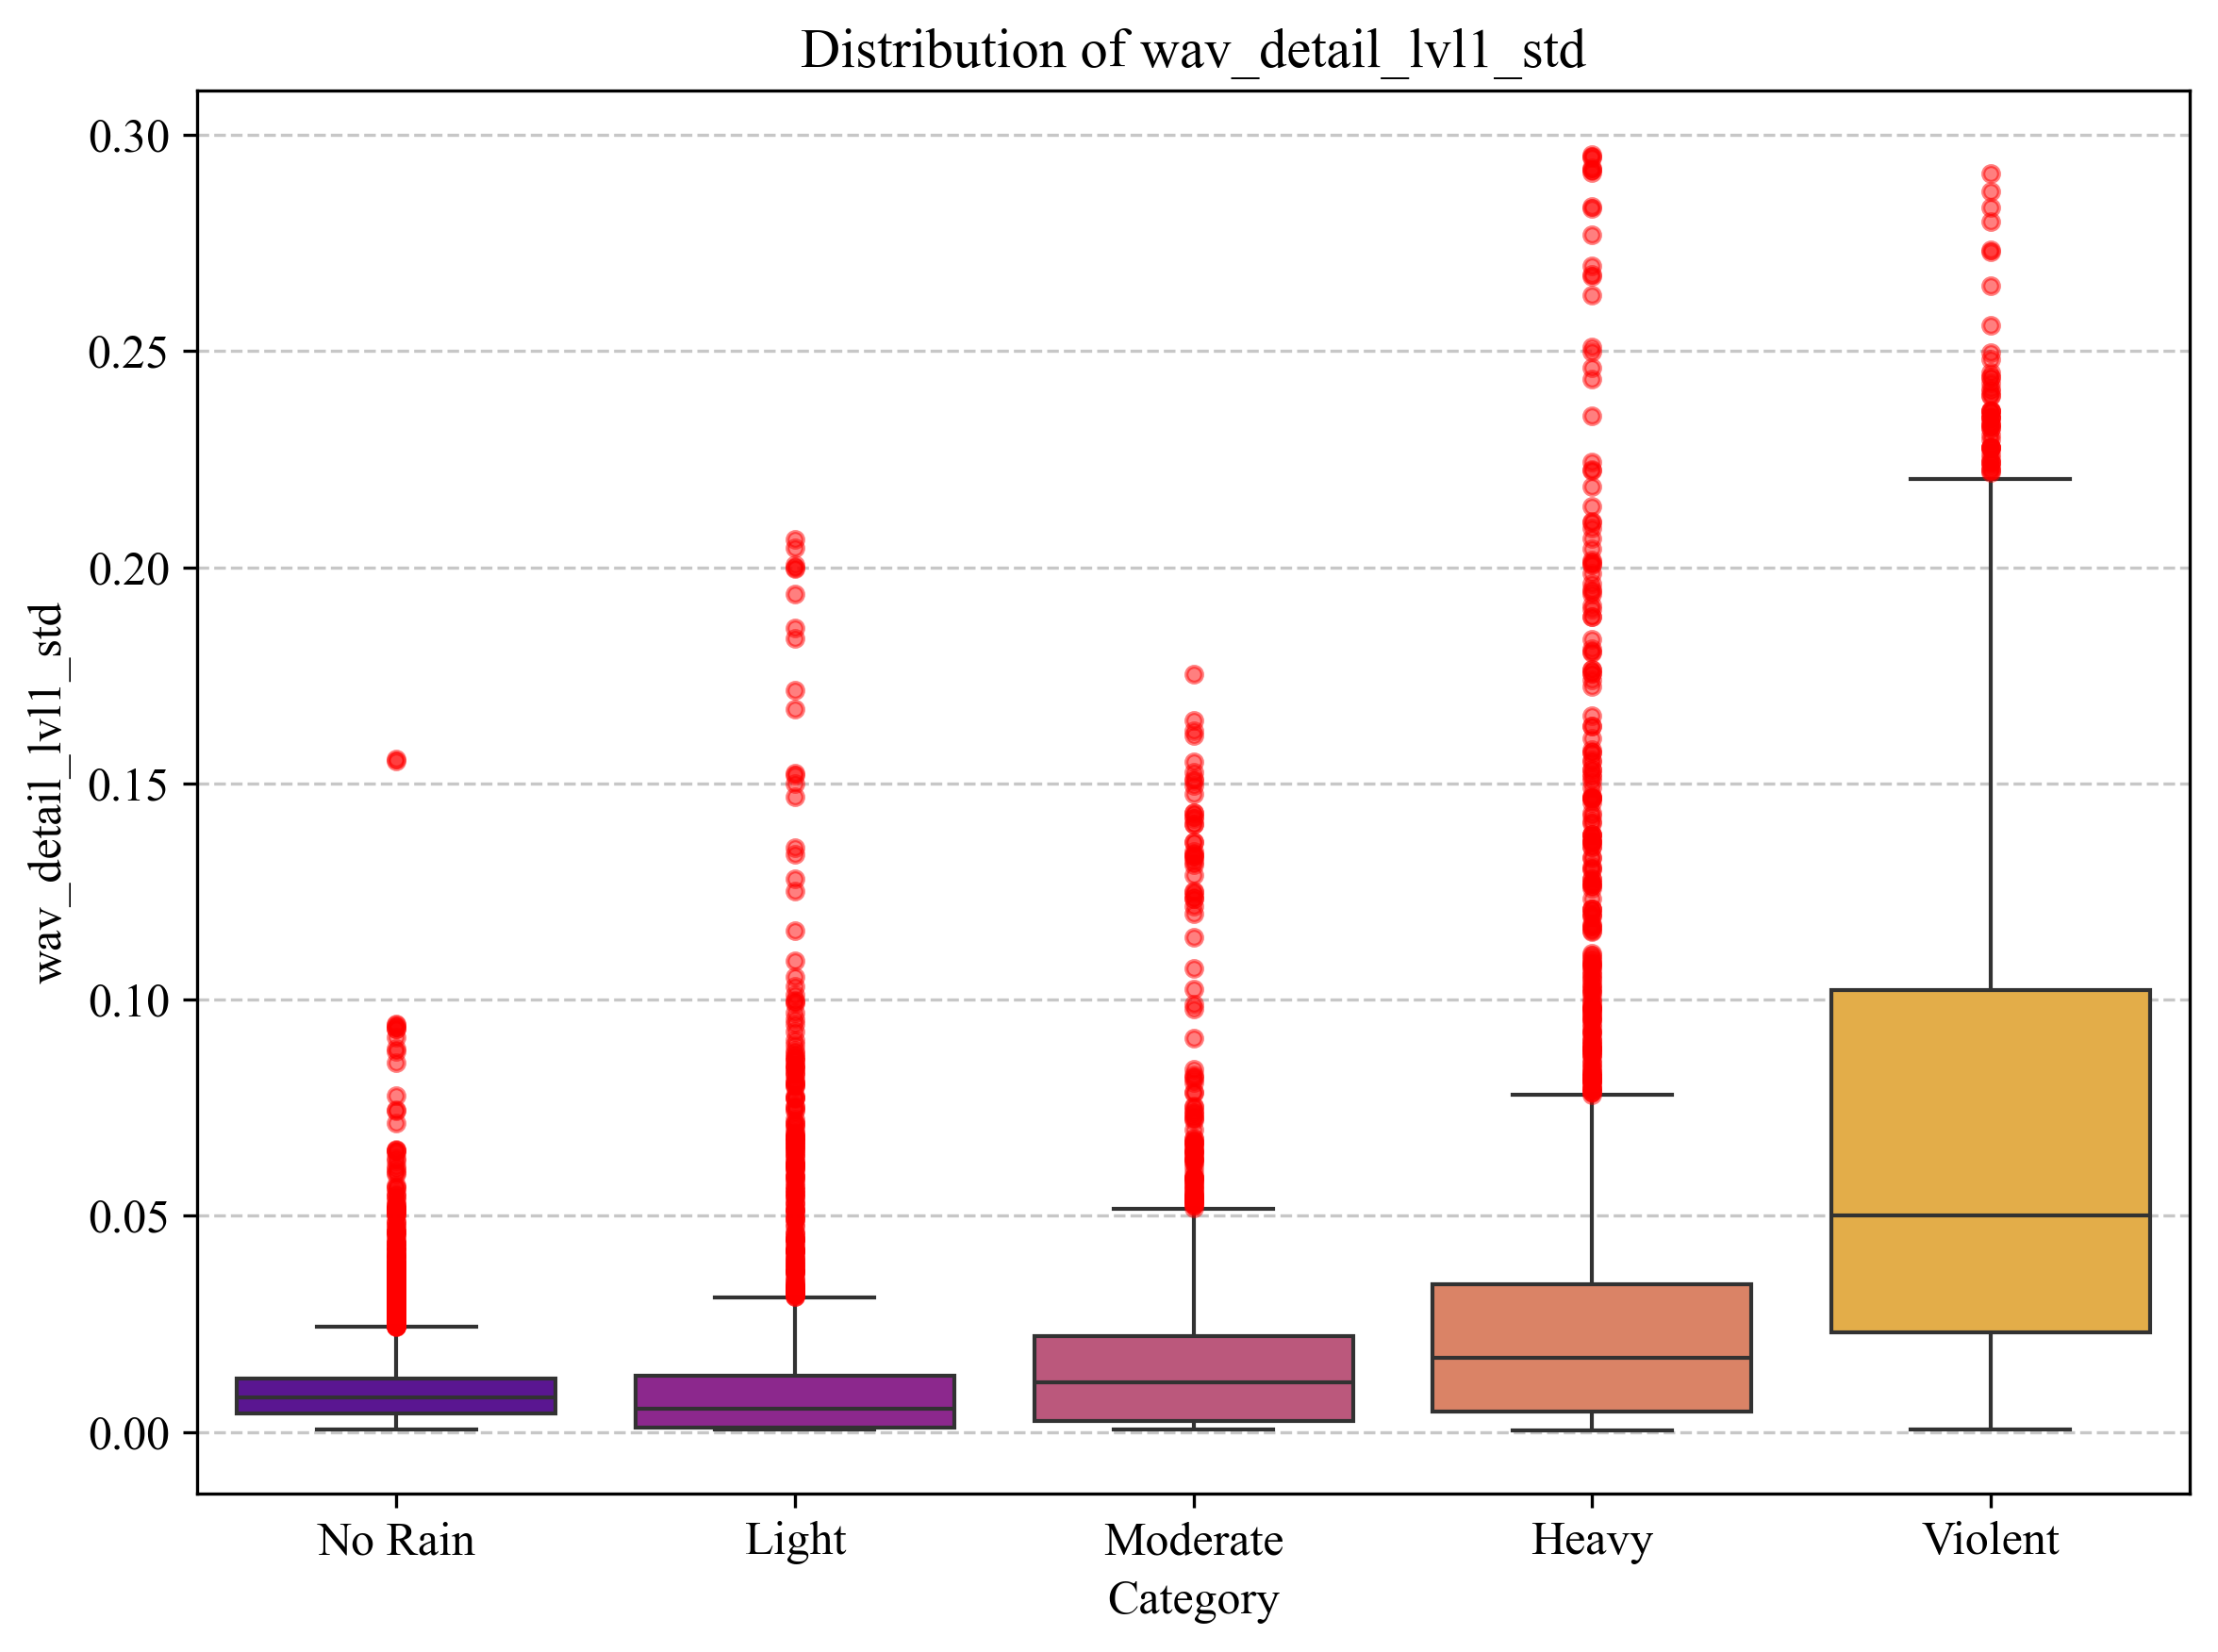

In [10]:
plot_individual_boxplots(
    X=X_train_fischer_metrics, 
    y=y_train, 
    color_map=rain_palette,
    class_order=ordered_classes
)

09:14:09 - [FeaturePlots] - INFO - Generating Fisher Score Plot (Top 20)...


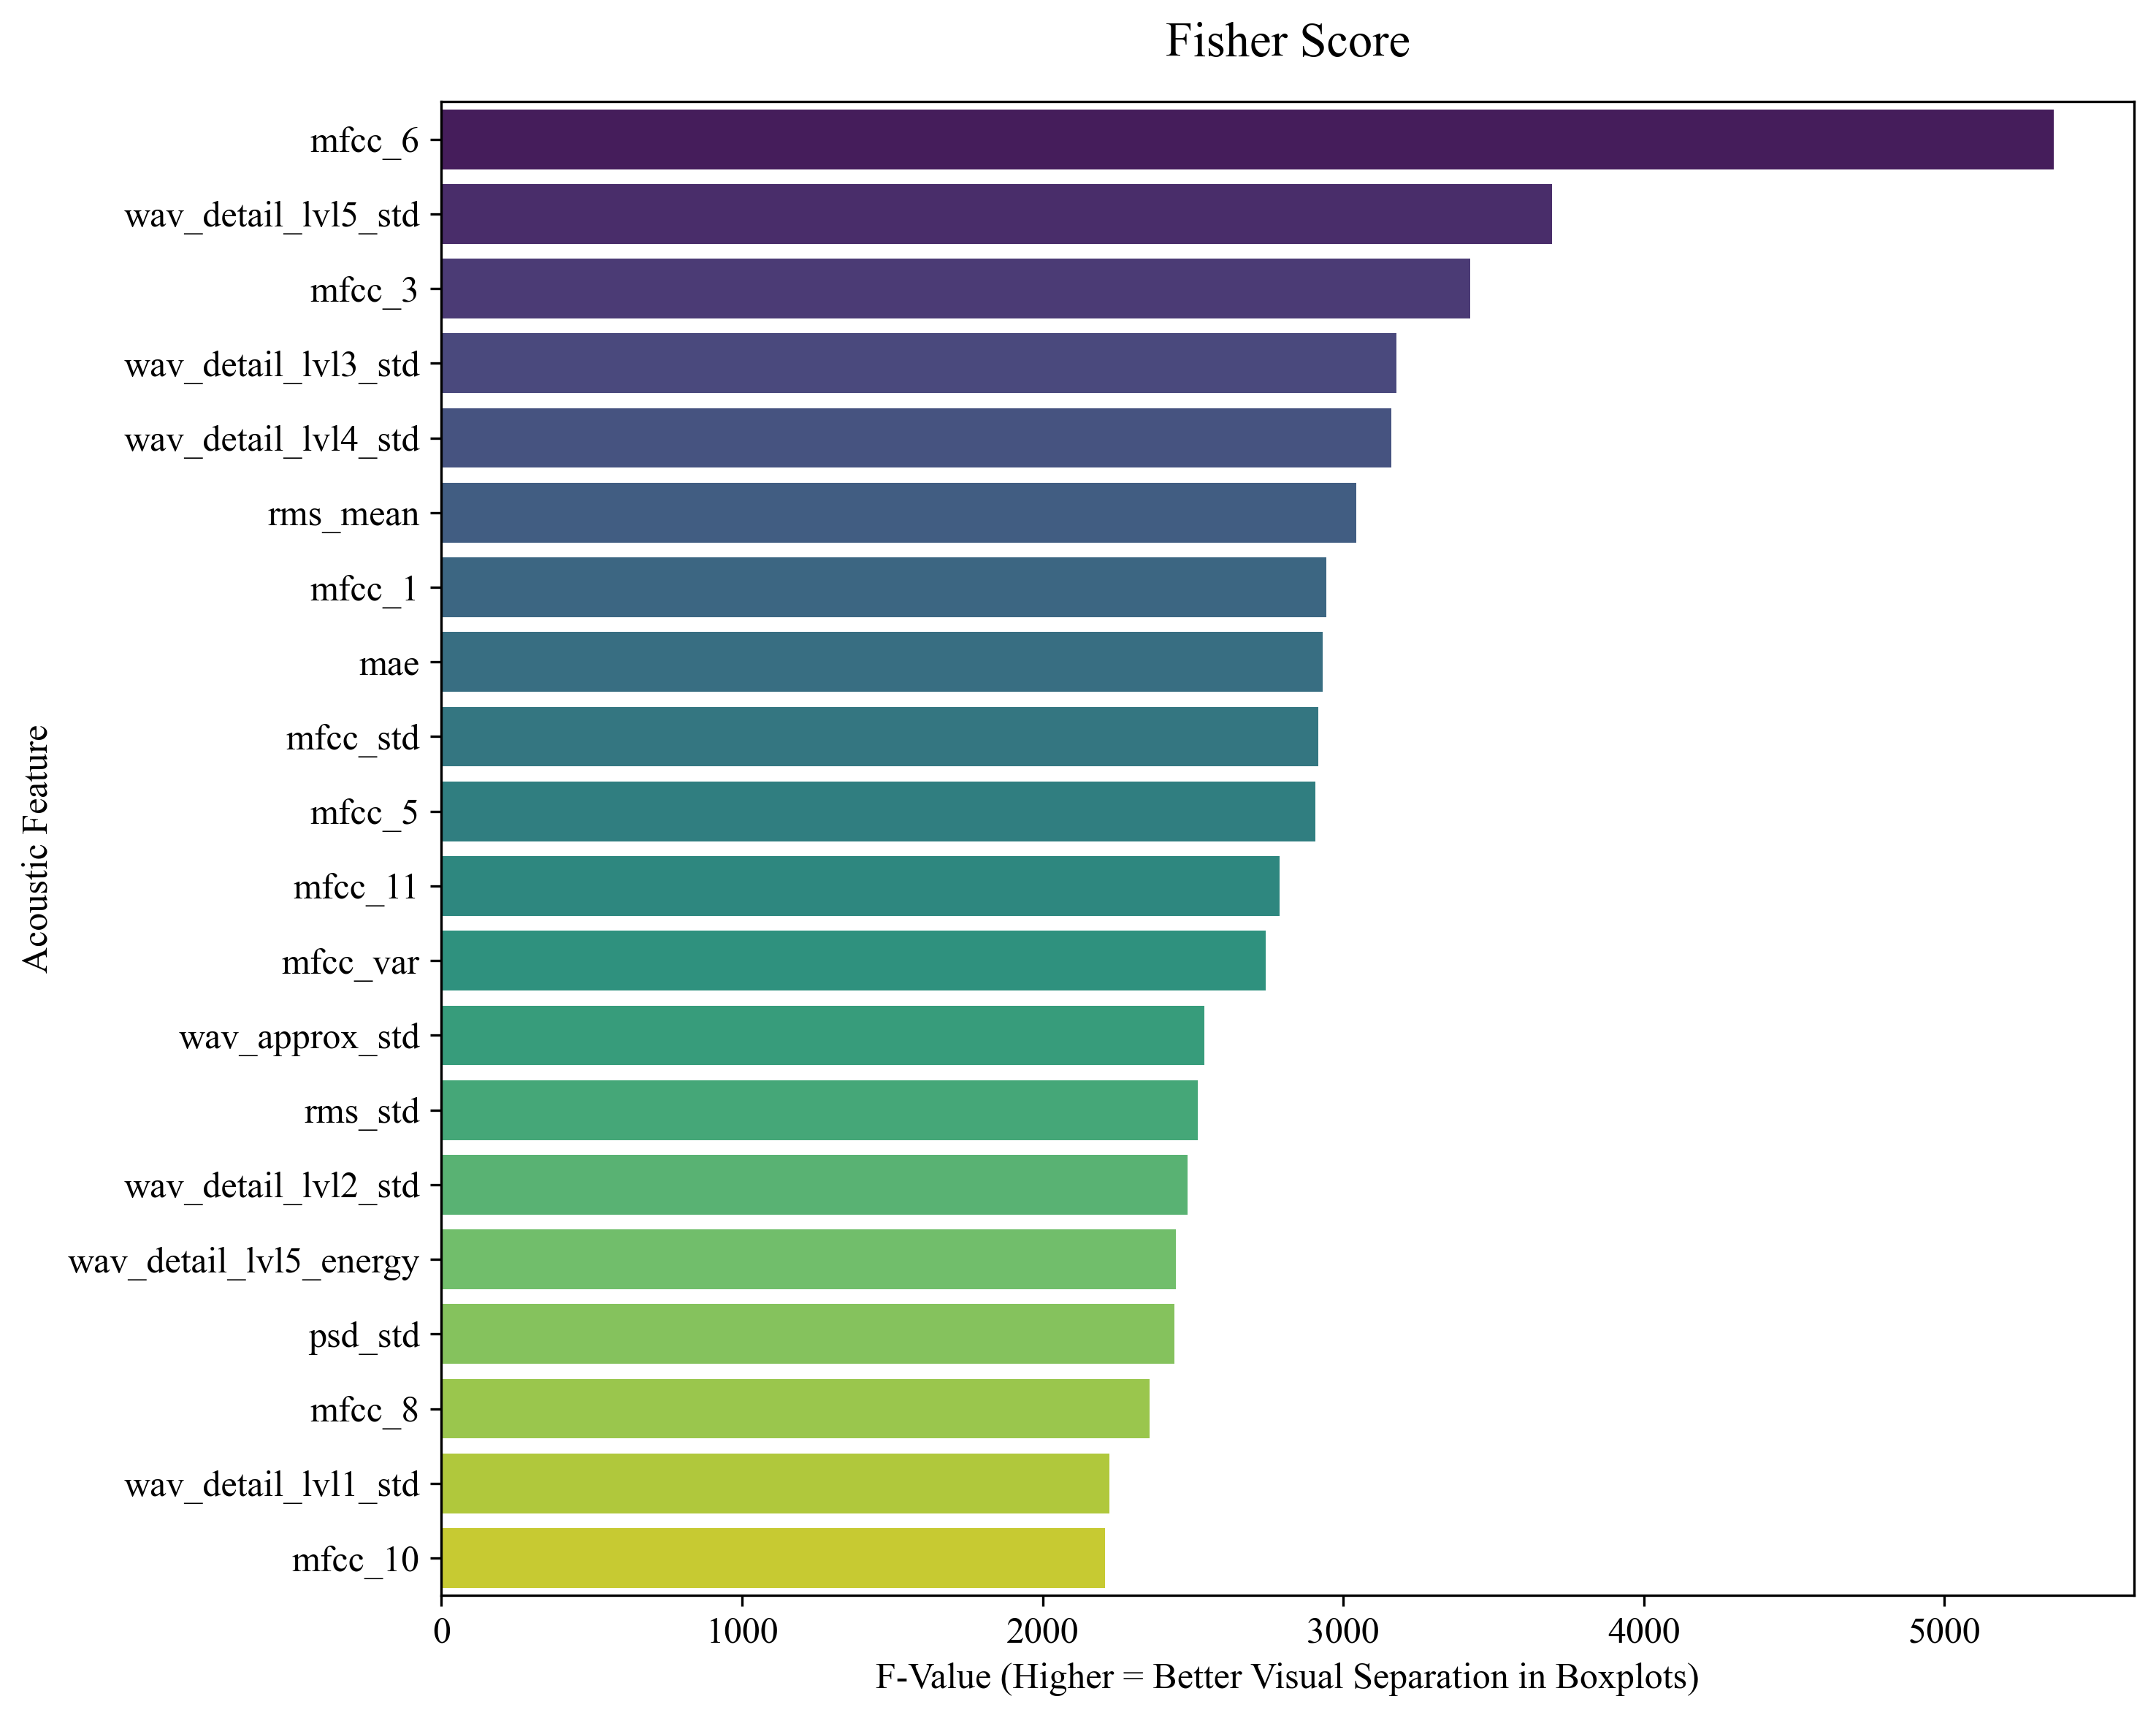

In [12]:
plot_fisher_scores(
    df_tracking=df_feature_tracking, 
    top_n=20,
    title="Fisher Score"
)

# Modeling

In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Instancia o codificador (tradutor de Texto para Número)
le = LabelEncoder()
val_config = ValidationConfig(average_method='macro', return_report_dict=False)

# Transforma os textos ('Heavy', 'Light') em inteiros (0, 1, 2, 3, 4)
# e preserva o índice original do Pandas
y_train_enc = pd.Series(le.fit_transform(y_train), index=y_train.index, name=TARGET_COL)
y_val_enc   = pd.Series(le.transform(y_val), index=y_val.index, name=TARGET_COL)
y_test_enc  = pd.Series(le.transform(y_test), index=y_test.index, name=TARGET_COL)

print("✅ Variáveis 'y_train_enc', 'y_val_enc' e 'y_test_enc' recriadas e salvas na memória!")
print(f"Mapeamento interno: {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ Variáveis 'y_train_enc', 'y_val_enc' e 'y_test_enc' recriadas e salvas na memória!
Mapeamento interno: {'Heavy': np.int64(0), 'Light': np.int64(1), 'Moderate': np.int64(2), 'No Rain': np.int64(3), 'Violent': np.int64(4)}


## Selected Metrics

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import NuSVC

MAX_FEATURES = 20
top_10_features = df_feature_tracking[df_feature_tracking['Survived_Pipeline'] == 1]['Feature_Name'].head(MAX_FEATURES).tolist()

09:15:53 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
--- Treinando com 1 Feature(s) [Adicionada agora: mfcc_6] ---
09:15:54 - [ClassifierFactory] - INFO - Building registered model architecture: SGD
09:15:54 - [HyperparameterTuner] - INFO - Starting Optimization Engine. Target Metric: f1_macro
Fitting 1 folds for each of 4 candidates, totalling 4 fits
09:15:54 - [HyperparameterTuner] - INFO - Optimization complete. Champion Score (f1_macro) on Val Set: 0.2817
09:15:54 - [HyperparameterTuner] - INFO - Champion Hyperparameters: {'alpha': 0.001, 'class_weight': 'balanced', 'penalty': 'l2'}
09:15:54 - [HyperparameterTuner] - INFO - Refitting the champion model exclusively on the Training Set...
09:15:54 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:15:54 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.3112 | PR-AUC: 0.40456974177842503
--- Treinando com 2 Feature(s) [Adicionada agora: wav_detail_lvl5_std] ---

,Dimensao,Ultima_Feature_Inclusa,F1_Macro,Accuracy
0,1,mfcc_6,0.311207,0.0
1,2,wav_detail_lvl5_std,0.426367,0.0
2,3,mfcc_3,0.443422,0.0
3,4,wav_detail_lvl3_std,0.439443,0.0
4,5,wav_detail_lvl4_std,0.458294,0.0
5,6,rms_mean,0.453176,0.0
6,7,mfcc_1,0.423545,0.0
7,8,mae,0.437589,0.0
8,9,mfcc_std,0.434166,0.0
9,10,mfcc_5,0.439394,0.0


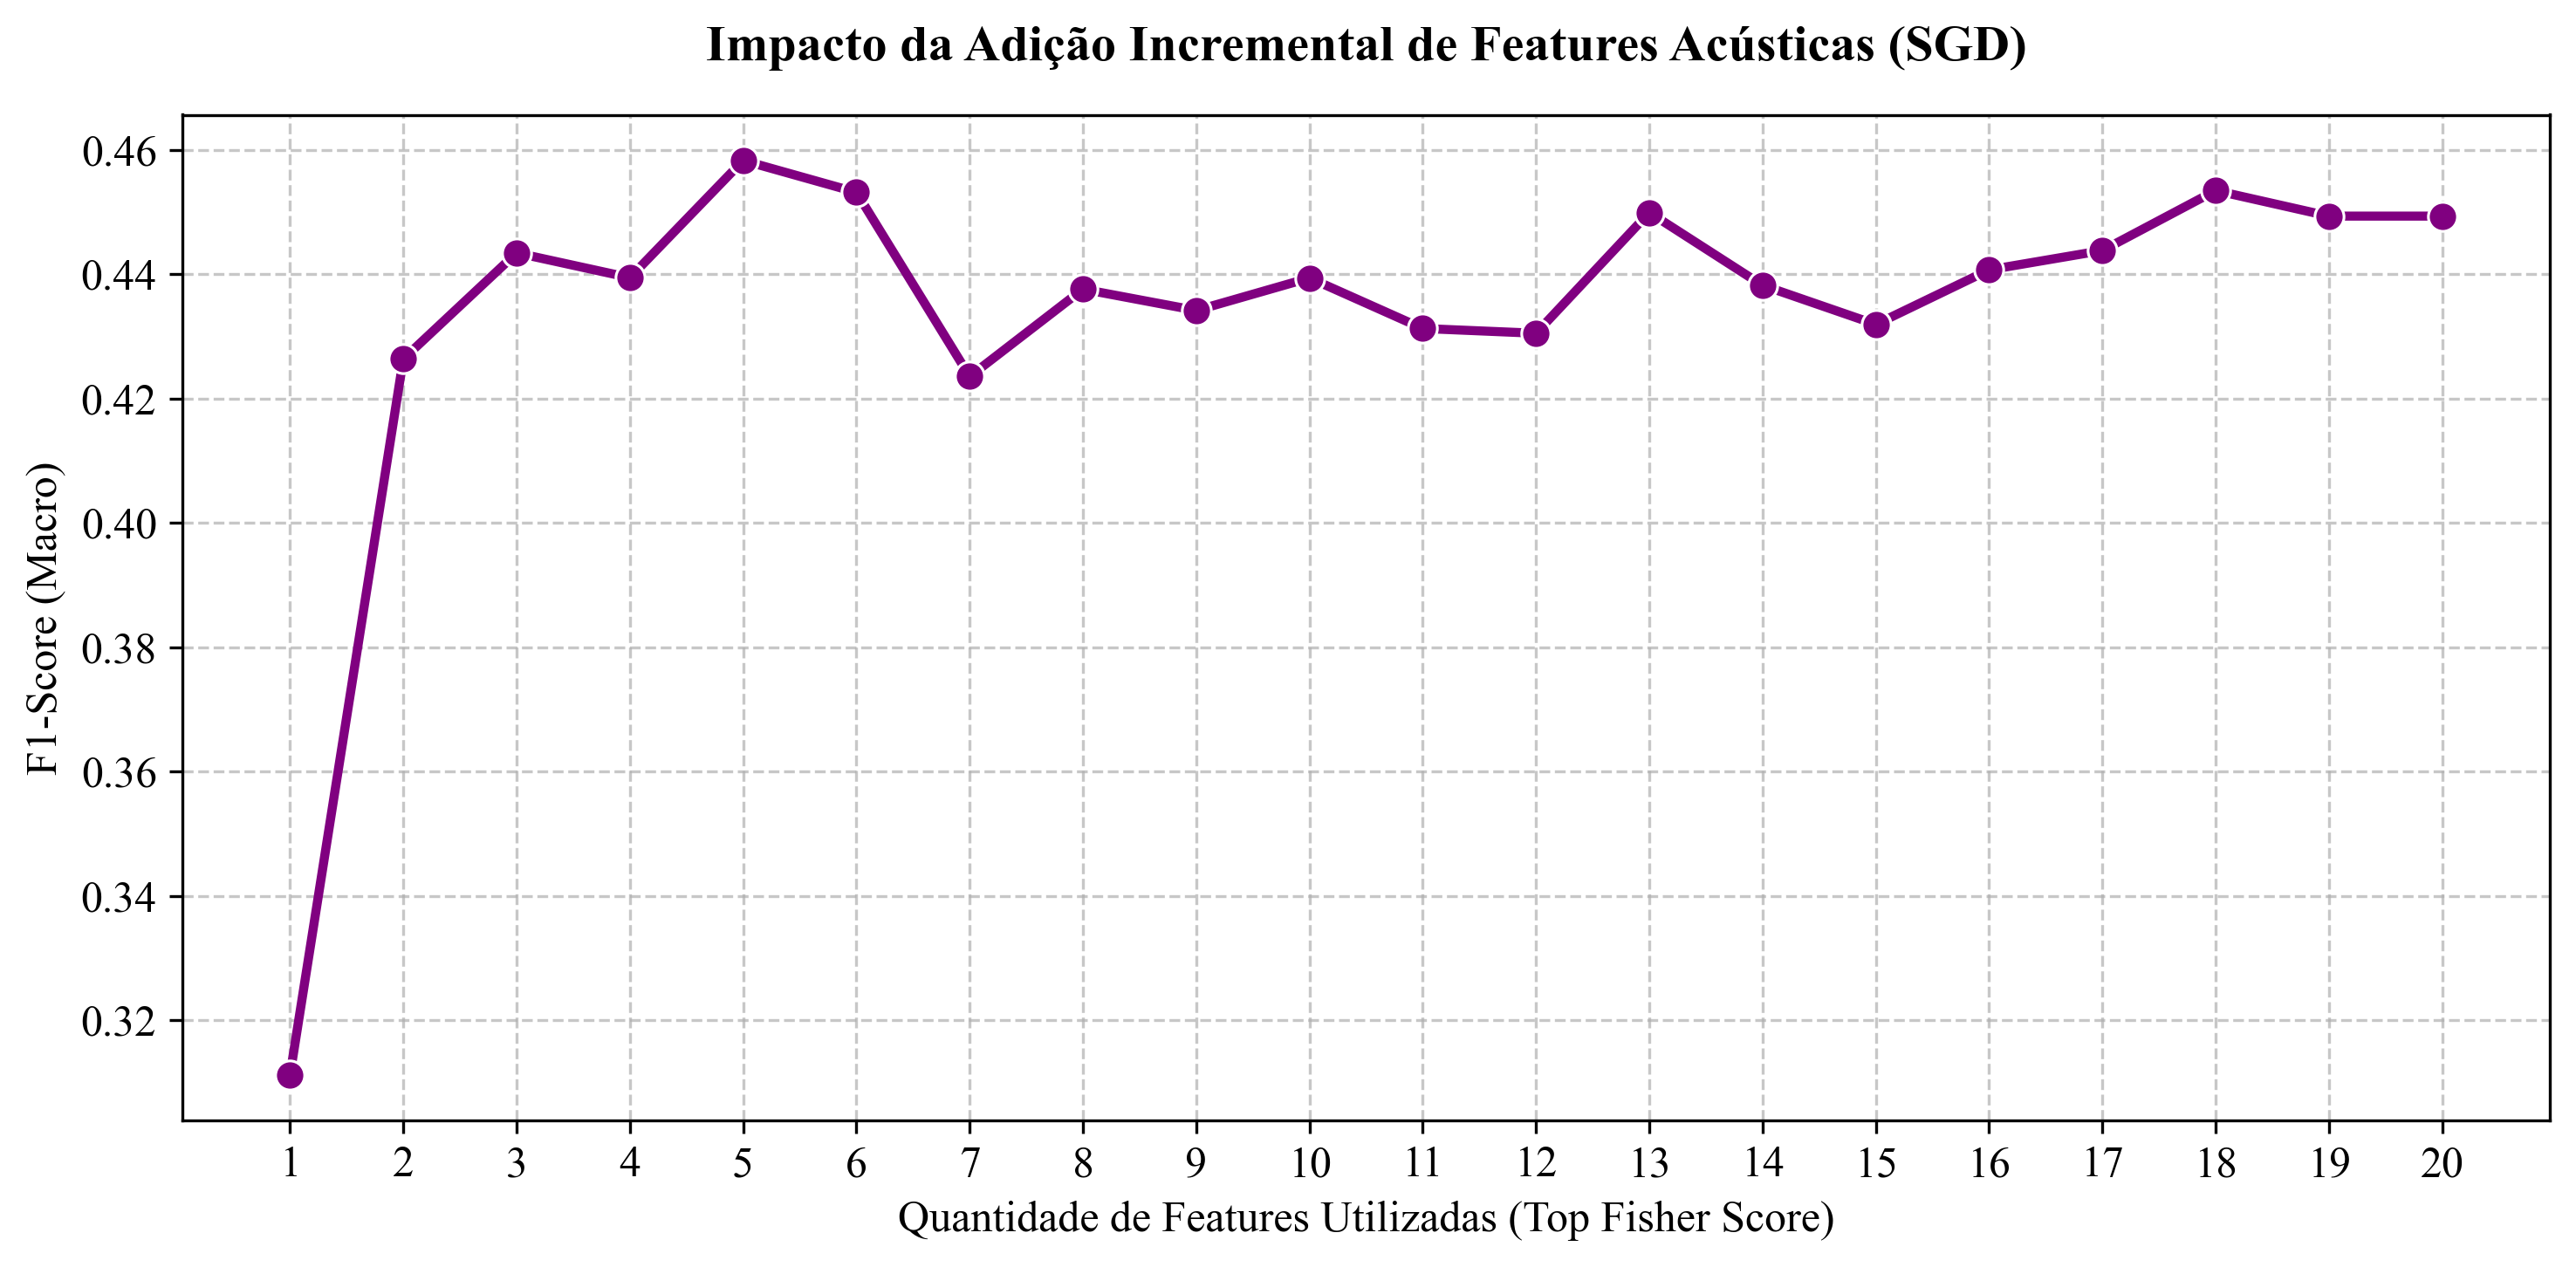

In [22]:
sgd_config = ClassifierConfig(model_type='sgd', random_state=42)
sgd_grid = {
    'alpha': [0.0001, 0.001], 
    'penalty': ['l2', 'elasticnet'], 
    'class_weight': ['balanced']
}
tuning_config_sgd = TuningConfig(param_grid=sgd_grid, scoring_metric='f1_macro', n_jobs=-1)
val_config = ValidationConfig(average_method='macro', return_report_dict=False)

incremental_results_sgd = []

for k in range(1, MAX_FEATURES + 1):
    current_features = top_10_features[:k]
    feature_adicionada = current_features[-1]
    
    print(f"--- Treinando com {k} Feature(s) [Adicionada agora: {feature_adicionada}] ---")
    
    # Fatiamento da matriz usando as listas de nomes
    X_tr_slice = X_train_selected_metrics[current_features]
    X_va_slice = X_val_selected_metrics[current_features]
    X_te_slice = X_test_selected_metrics[current_features]
    
    try:
        # A. Constrói o modelo
        sgd_base = ClassifierFactory.build(sgd_config)
        
        # B. Otimiza (Tuning)
        sgd_champion = ModelOptimizer.optimize(
            estimator=sgd_base, 
            X_train=X_tr_slice, 
            y_train=y_train_enc, # Usando a variável numérica que criamos para evitar erros
            X_val=X_va_slice, 
            y_val=y_val_enc, 
            config=tuning_config_sgd
        )
        
        # C. Avalia no Teste (O veredito final daquele conjunto)
        metrics_sgd = ModelEvaluator.evaluate(
            model=sgd_champion, 
            X_test=X_te_slice, 
            y_test=y_test_enc, 
            config=val_config
        )
        
        # D. Extração Segura das Métricas (Tratando possíveis mudanças no dicionário)
        f1  = metrics_sgd.get('f1_macro', metrics_sgd.get('f1_score', metrics_sgd.get('f1', 0.0)))
        acc = metrics_sgd.get('accuracy', metrics_sgd.get('accuracy_score', 0.0))
        
        incremental_results_sgd.append({
            'Dimensao': k,
            'Ultima_Feature_Inclusa': feature_adicionada,
            'F1_Macro': f1,
            'Accuracy': acc
        })
        
    except Exception as e:
        print(f"❌ Falha no passo com {k} features: {e}")

# 4. Tabela de Resultados
df_sgd_incremental = pd.DataFrame(incremental_results_sgd)
print("\n📊 Tabela de Desempenho Incremental:")
display(df_sgd_incremental)

# 5. O Gráfico Definitivo (Curva de Aprendizado por Dimensão)
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_sgd_incremental, 
    x='Dimensao', 
    y='F1_Macro', 
    marker='o', 
    color='purple', 
    linewidth=2.5,
    markersize=8
)

plt.title("Impacto da Adição Incremental de Features Acústicas (SGD)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Features Utilizadas (Top Fisher Score)", fontsize=12)
plt.ylabel("F1-Score (Macro)", fontsize=12)
plt.xticks(range(1, MAX_FEATURES + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Salva se a pasta REPORTS_DIR estiver definida
if 'REPORTS_DIR' in locals():
    plt.savefig(REPORTS_DIR / f"{DATASET}_E{EXP_NUM}_SGD_Incremental.pdf", dpi=300, bbox_inches='tight')

plt.show()

🚀 Teste de Escalonamento de Features (Incremental) - Regressão Logística (LR)
09:16:10 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
--- Treinando LR com 1 Feature(s) [+ mfcc_6] ---
09:16:10 - [ClassifierFactory] - INFO - Building registered model architecture: LR
09:16:10 - [HyperparameterTuner] - INFO - Starting Optimization Engine. Target Metric: f1_macro
Fitting 1 folds for each of 3 candidates, totalling 3 fits
09:16:10 - [HyperparameterTuner] - INFO - Optimization complete. Champion Score (f1_macro) on Val Set: 0.3368
09:16:10 - [HyperparameterTuner] - INFO - Champion Hyperparameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}
09:16:10 - [HyperparameterTuner] - INFO - Refitting the champion model exclusively on the Training Set...
09:16:10 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:16:10 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.3834 | PR-AUC: 0.40316092765095

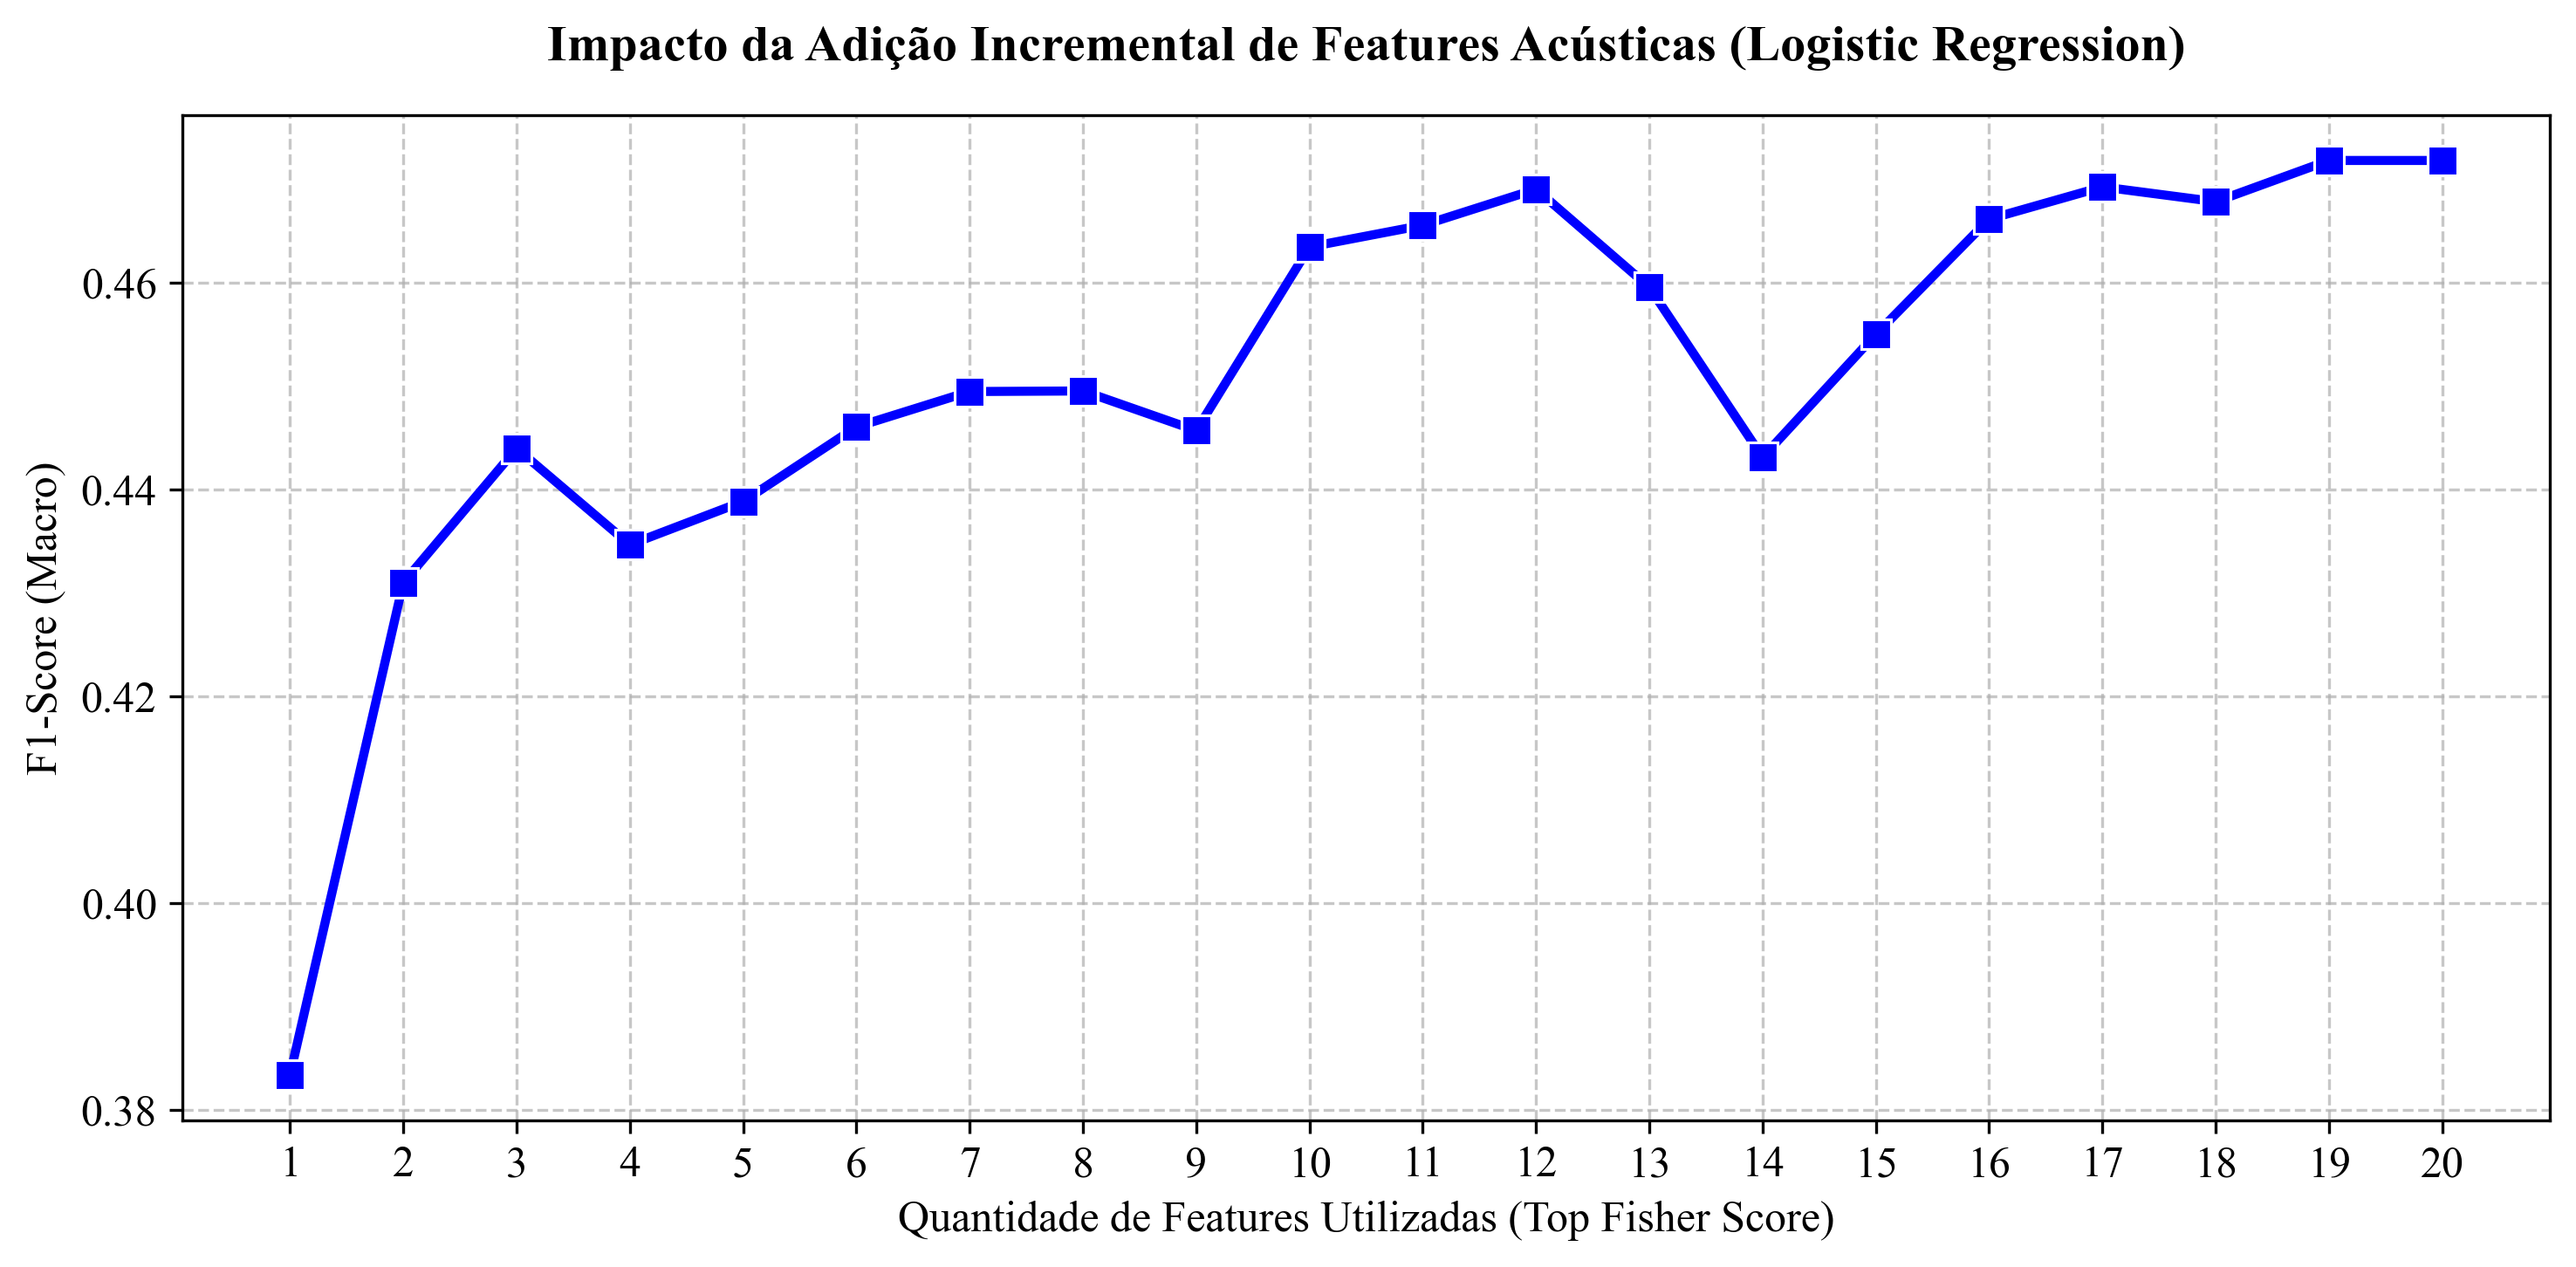

In [23]:
# ==============================================================================
# Teste Unitário de Dimensão: Incremental Feature Scaling no LR
# ==============================================================================
print("="*60)
print("🚀 Teste de Escalonamento de Features (Incremental) - Regressão Logística (LR)")
print("="*60)

# Configurações do LR
lr_config = ClassifierConfig(model_type='lr', random_state=42)
lr_grid = {
    'C': [0.1, 1.0, 10.0], 
    'class_weight': ['balanced'], 
    'solver': ['lbfgs'], 
    'max_iter': [1000]
}
tuning_config_lr = TuningConfig(param_grid=lr_grid, scoring_metric='f1_macro', n_jobs=-1)

incremental_results_lr = []

for k in range(1, MAX_FEATURES + 1):
    current_features = top_10_features[:k]
    feature_adicionada = current_features[-1]
    print(f"--- Treinando LR com {k} Feature(s) [+ {feature_adicionada}] ---")
    
    X_tr_slice = X_train_selected_metrics[current_features]
    X_va_slice = X_val_selected_metrics[current_features]
    X_te_slice = X_test_selected_metrics[current_features]
    
    try:
        lr_base = ClassifierFactory.build(lr_config)
        lr_champion = ModelOptimizer.optimize(
            estimator=lr_base, X_train=X_tr_slice, y_train=y_train_enc, 
            X_val=X_va_slice, y_val=y_val_enc, config=tuning_config_lr
        )
        metrics_lr = ModelEvaluator.evaluate(model=lr_champion, X_test=X_te_slice, y_test=y_test_enc, config=val_config)
        
        f1  = metrics_lr.get('f1_macro', metrics_lr.get('f1_score', metrics_lr.get('f1', 0.0)))
        acc = metrics_lr.get('accuracy', metrics_lr.get('accuracy_score', 0.0))
        
        incremental_results_lr.append({'Dimensao': k, 'Ultima_Feature_Inclusa': feature_adicionada, 'F1_Macro': f1, 'Accuracy': acc})
    except Exception as e:
        print(f"❌ Falha no passo com {k} features: {e}")

# Gráfico
df_lr_incremental = pd.DataFrame(incremental_results_lr)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_lr_incremental, x='Dimensao', y='F1_Macro', marker='s', color='blue', linewidth=2.5, markersize=8)
plt.title("Impacto da Adição Incremental de Features Acústicas (Logistic Regression)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Features Utilizadas (Top Fisher Score)", fontsize=12)
plt.ylabel("F1-Score (Macro)", fontsize=12)
plt.xticks(range(1, MAX_FEATURES + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

🚀 Teste de Escalonamento de Features (Incremental) - Random Forest (RF)
09:16:34 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
--- Treinando RF com 1 Feature(s) [+ mfcc_6] ---
09:16:34 - [ClassifierFactory] - INFO - Building registered model architecture: RF
09:16:34 - [HyperparameterTuner] - INFO - Starting Optimization Engine. Target Metric: f1_macro
Fitting 1 folds for each of 12 candidates, totalling 12 fits
09:16:35 - [HyperparameterTuner] - INFO - Optimization complete. Champion Score (f1_macro) on Val Set: 0.3313
09:16:35 - [HyperparameterTuner] - INFO - Champion Hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
09:16:35 - [HyperparameterTuner] - INFO - Refitting the champion model exclusively on the Training Set...
09:16:35 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:16:35 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.3302 | PR-AUC: 0.3356174663035688
--- Treinando

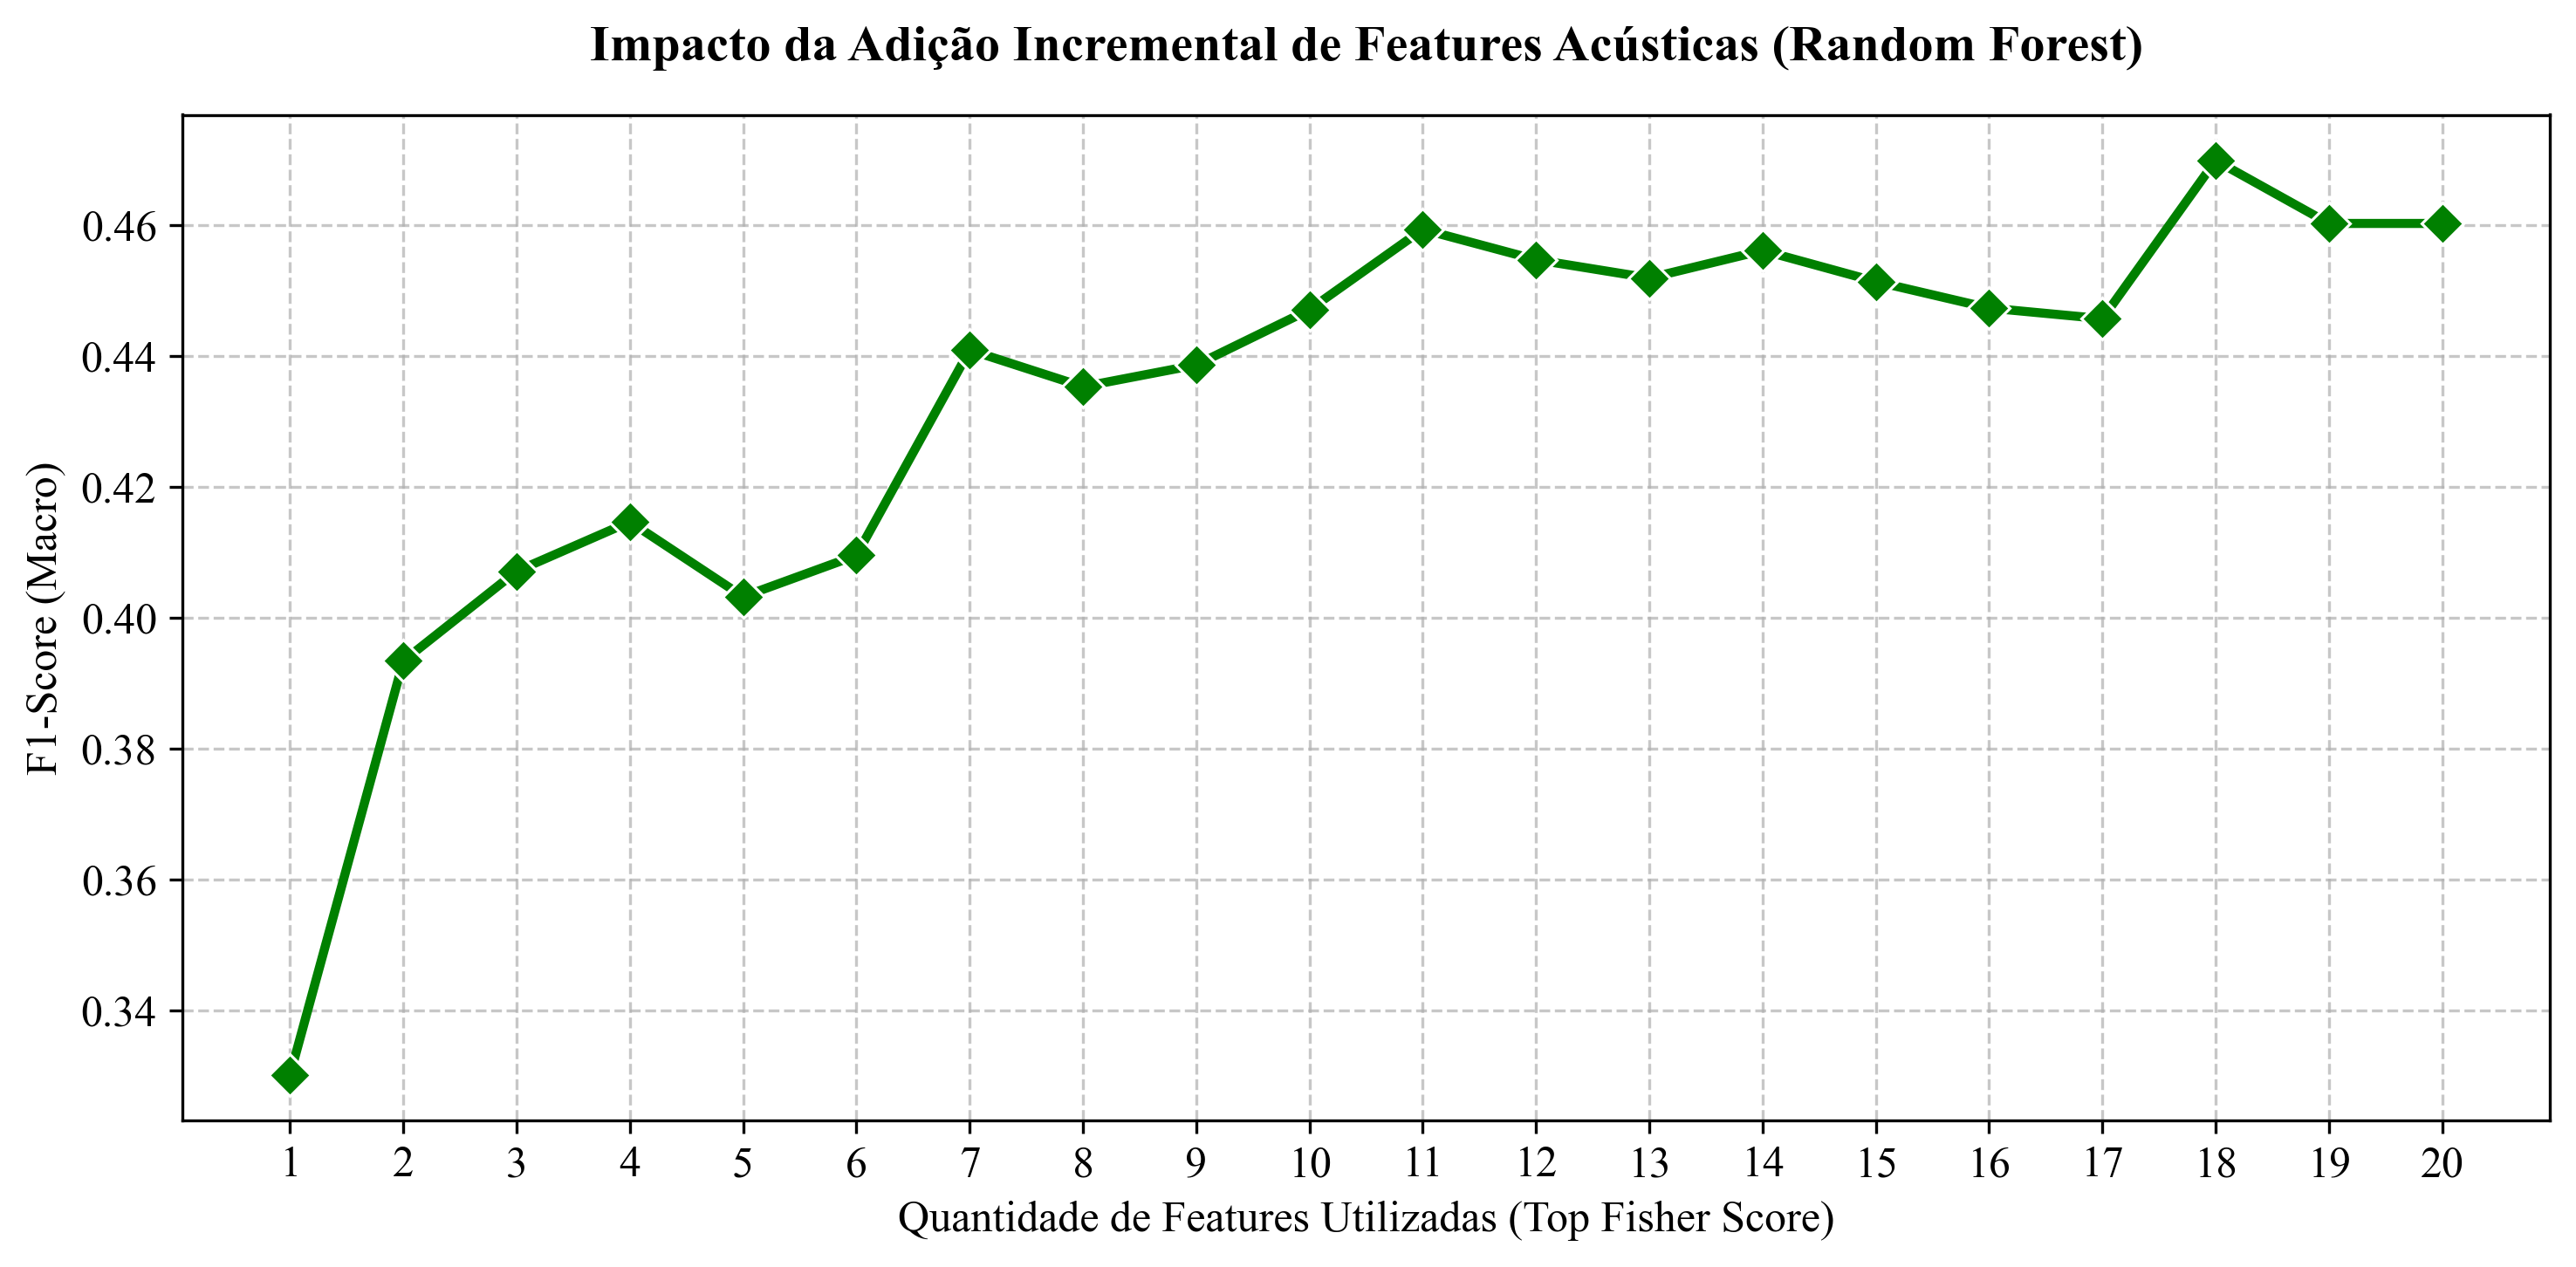

In [24]:
# ==============================================================================
# Teste Unitário de Dimensão: Incremental Feature Scaling no RF
# ==============================================================================
print("="*60)
print("🚀 Teste de Escalonamento de Features (Incremental) - Random Forest (RF)")
print("="*60)

# Configurações do RF
rf_config = ClassifierConfig(model_type='rf', random_state=42)
rf_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 5, 10], 
    'min_samples_leaf': [1, 2]
}
tuning_config_rf = TuningConfig(param_grid=rf_grid, scoring_metric='f1_macro', n_jobs=-1)

incremental_results_rf = []

for k in range(1, MAX_FEATURES + 1):
    current_features = top_10_features[:k]
    feature_adicionada = current_features[-1]
    print(f"--- Treinando RF com {k} Feature(s) [+ {feature_adicionada}] ---")
    
    X_tr_slice = X_train_selected_metrics[current_features]
    X_va_slice = X_val_selected_metrics[current_features]
    X_te_slice = X_test_selected_metrics[current_features]
    
    try:
        rf_base = ClassifierFactory.build(rf_config)
        rf_champion = ModelOptimizer.optimize(
            estimator=rf_base, X_train=X_tr_slice, y_train=y_train_enc, 
            X_val=X_va_slice, y_val=y_val_enc, config=tuning_config_rf
        )
        metrics_rf = ModelEvaluator.evaluate(model=rf_champion, X_test=X_te_slice, y_test=y_test_enc, config=val_config)
        
        f1  = metrics_rf.get('f1_macro', metrics_rf.get('f1_score', metrics_rf.get('f1', 0.0)))
        acc = metrics_rf.get('accuracy', metrics_rf.get('accuracy_score', 0.0))
        
        incremental_results_rf.append({'Dimensao': k, 'Ultima_Feature_Inclusa': feature_adicionada, 'F1_Macro': f1, 'Accuracy': acc})
    except Exception as e:
        print(f"❌ Falha no passo com {k} features: {e}")

# Gráfico
df_rf_incremental = pd.DataFrame(incremental_results_rf)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_rf_incremental, x='Dimensao', y='F1_Macro', marker='D', color='green', linewidth=2.5, markersize=8)
plt.title("Impacto da Adição Incremental de Features Acústicas (Random Forest)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Features Utilizadas (Top Fisher Score)", fontsize=12)
plt.ylabel("F1-Score (Macro)", fontsize=12)
plt.xticks(range(1, MAX_FEATURES + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

🚀 Teste de Escalonamento de Features (Incremental) - XGBoost (XGB)
09:17:32 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
--- Treinando XGB com 1 Feature(s) [+ mfcc_6] ---
09:17:32 - [ClassifierFactory] - INFO - Building registered model architecture: XGB
09:17:32 - [HyperparameterTuner] - INFO - Starting Optimization Engine. Target Metric: f1_macro
Fitting 1 folds for each of 8 candidates, totalling 8 fits
09:17:33 - [HyperparameterTuner] - INFO - Optimization complete. Champion Score (f1_macro) on Val Set: 0.3023
09:17:33 - [HyperparameterTuner] - INFO - Champion Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
09:17:33 - [HyperparameterTuner] - INFO - Refitting the champion model exclusively on the Training Set...
09:17:33 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:17:33 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.3542 | PR-AUC: 0.39680231673318106
--- Treinando XGB com

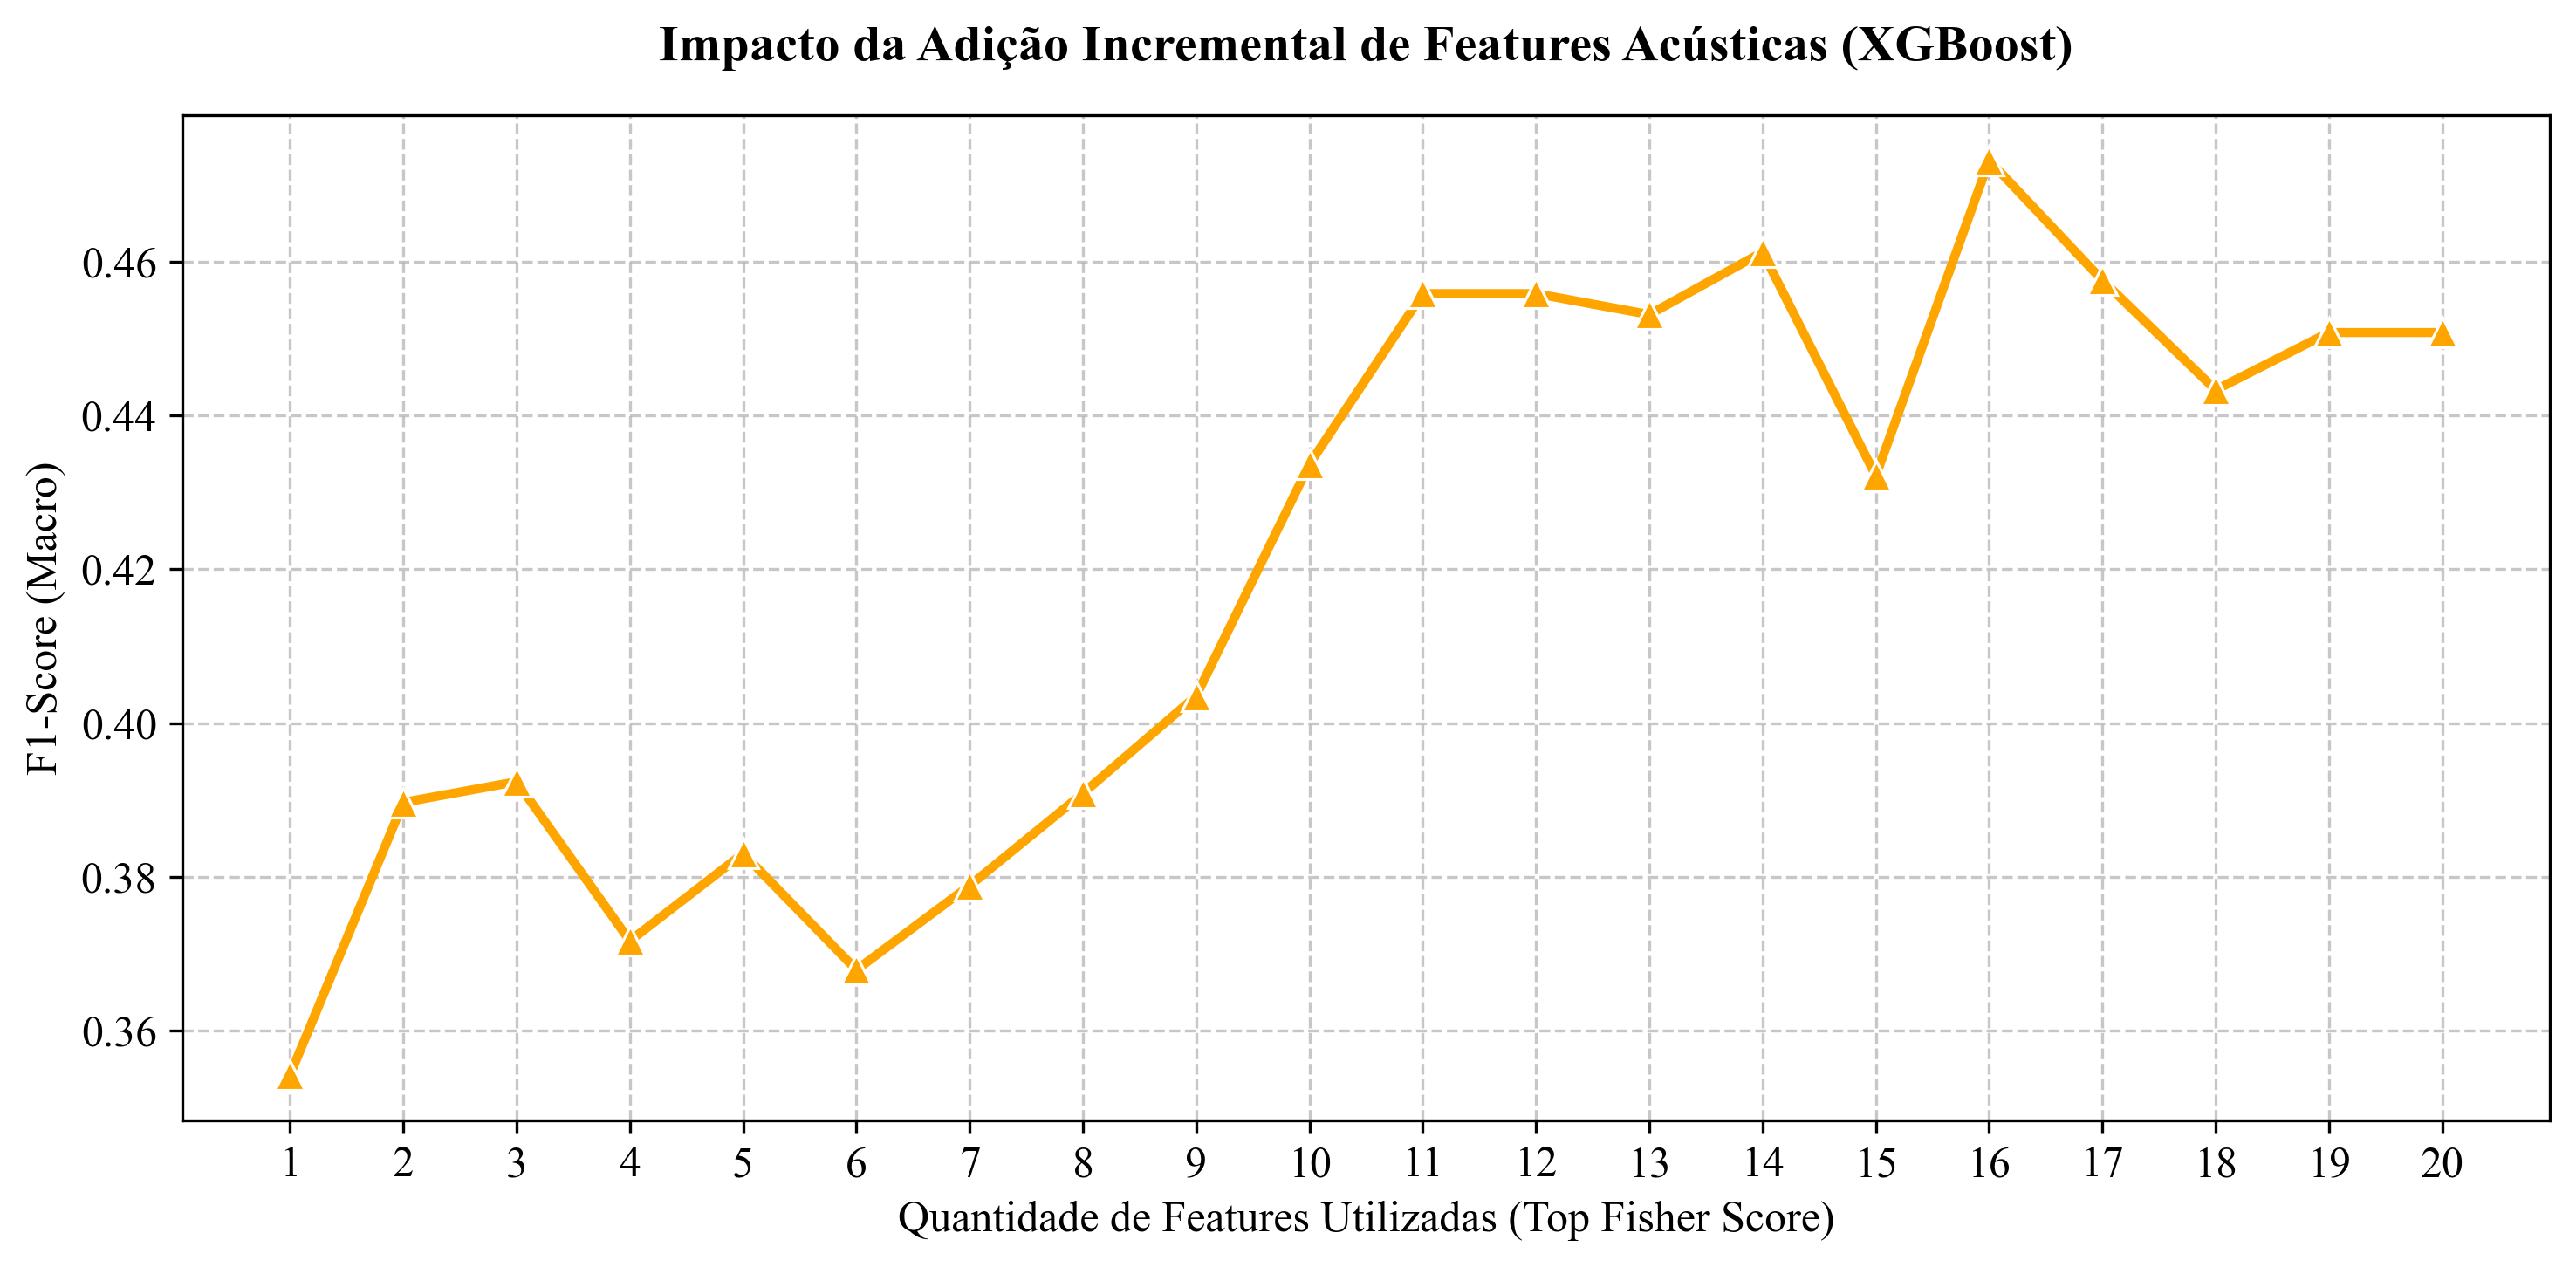

In [25]:
# ==============================================================================
# Teste Unitário de Dimensão: Incremental Feature Scaling no XGBoost
# ==============================================================================
print("="*60)
print("🚀 Teste de Escalonamento de Features (Incremental) - XGBoost (XGB)")
print("="*60)

# Configurações do XGBoost
xgb_config = ClassifierConfig(model_type='xgb', random_state=42)
xgb_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [3, 5], 
    'learning_rate': [0.01, 0.1]
}
tuning_config_xgb = TuningConfig(param_grid=xgb_grid, scoring_metric='f1_macro', n_jobs=-1)

incremental_results_xgb = []

for k in range(1, MAX_FEATURES + 1):
    current_features = top_10_features[:k]
    feature_adicionada = current_features[-1]
    print(f"--- Treinando XGB com {k} Feature(s) [+ {feature_adicionada}] ---")
    
    X_tr_slice = X_train_selected_metrics[current_features]
    X_va_slice = X_val_selected_metrics[current_features]
    X_te_slice = X_test_selected_metrics[current_features]
    
    try:
        xgb_base = ClassifierFactory.build(xgb_config)
        xgb_champion = ModelOptimizer.optimize(
            estimator=xgb_base, X_train=X_tr_slice, y_train=y_train_enc, 
            X_val=X_va_slice, y_val=y_val_enc, config=tuning_config_xgb
        )
        metrics_xgb = ModelEvaluator.evaluate(model=xgb_champion, X_test=X_te_slice, y_test=y_test_enc, config=val_config)
        
        f1  = metrics_xgb.get('f1_macro', metrics_xgb.get('f1_score', metrics_xgb.get('f1', 0.0)))
        acc = metrics_xgb.get('accuracy', metrics_xgb.get('accuracy_score', 0.0))
        
        incremental_results_xgb.append({'Dimensao': k, 'Ultima_Feature_Inclusa': feature_adicionada, 'F1_Macro': f1, 'Accuracy': acc})
    except Exception as e:
        print(f"❌ Falha no passo com {k} features: {e}")

# Gráfico
df_xgb_incremental = pd.DataFrame(incremental_results_xgb)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_xgb_incremental, x='Dimensao', y='F1_Macro', marker='^', color='orange', linewidth=2.5, markersize=8)
plt.title("Impacto da Adição Incremental de Features Acústicas (XGBoost)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Features Utilizadas (Top Fisher Score)", fontsize=12)
plt.ylabel("F1-Score (Macro)", fontsize=12)
plt.xticks(range(1, MAX_FEATURES + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Treinando Master Model com 1 Feature(s) [+ mfcc_6] ---
09:35:06 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:35:06 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.2096 | PR-AUC: 0.36513451839132366
--- Treinando Master Model com 2 Feature(s) [+ wav_detail_lvl5_std] ---
09:35:31 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:35:31 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.3033 | PR-AUC: 0.4067298538375642
--- Treinando Master Model com 3 Feature(s) [+ mfcc_3] ---
09:35:51 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:35:52 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.2883 | PR-AUC: 0.4013855450503976
--- Treinando Master Model com 4 Feature(s) [+ wav_detail_lvl3_std] ---
09:37:25 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
09:37:25 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.3071 | PR-AUC: 

,Dimensao,Ultima_Feature_Inclusa,F1_Macro
0,1,mfcc_6,0.209591
1,2,wav_detail_lvl5_std,0.303337
2,3,mfcc_3,0.288346
3,4,wav_detail_lvl3_std,0.307132
4,5,wav_detail_lvl4_std,0.314264
5,6,rms_mean,0.325830
6,7,mfcc_1,0.276889
7,8,mae,0.301840
8,9,mfcc_std,0.324542
9,10,mfcc_5,0.397660


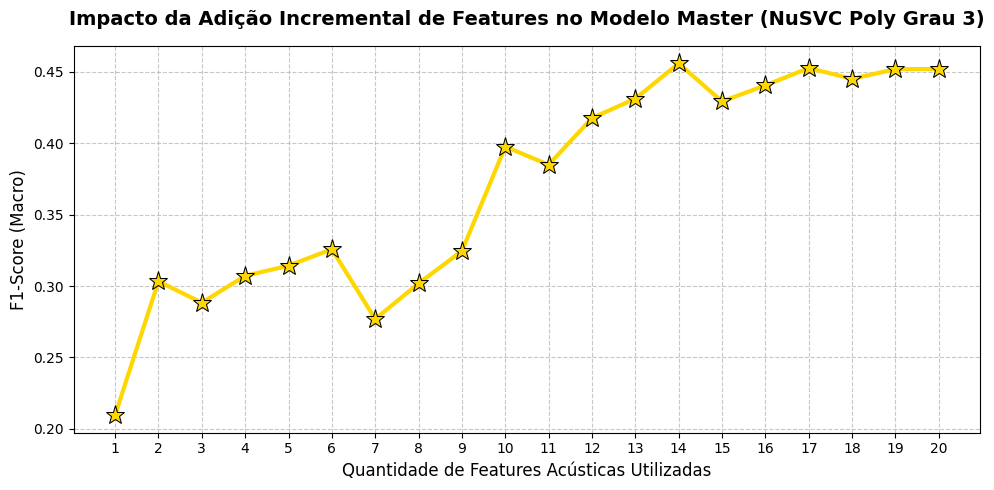

In [11]:
# ==============================================================================
# Teste Unitário de Dimensão: Incremental Feature Scaling (Bare-Metal Otimizado)
# ==============================================================================
incremental_results_master = []

# Loop Incremental do Doutorando
for k in range(1, MAX_FEATURES + 1):
    current_features = top_10_features[:k]
    feature_adicionada = current_features[-1]
    
    print(f"--- Treinando Master Model com {k} Feature(s) [+ {feature_adicionada}] ---")
    
    # Fatiamento DIRETO (Sem necessidade de carregar X_val)
    X_tr_slice = X_train_selected_metrics[current_features]
    X_te_slice = X_test_selected_metrics[current_features]
    
    try:
        # 1. Instanciação Direta (Bypass do Otimizador e da Factory)
        clf_master = NuSVC(
            kernel='poly', 
            degree=3, 
            coef0=1.0, 
            nu=0.5, 
            gamma='scale', 
            class_weight='balanced', 
            probability=True, 
            random_state=42
        )
        
        # 2. Treinamento Direto no Conjunto de Treino
        clf_master.fit(X_tr_slice, y_train_enc)
        
        # 3. Avaliação Inviolável no Conjunto de Teste
        metrics_master = ModelEvaluator.evaluate(
            model=clf_master, 
            X_test=X_te_slice, 
            y_test=y_test_enc, 
            config=val_config
        )
        
        # Puxando o F1 Macro com segurança
        f1 = metrics_master.get('f1_macro', metrics_master.get('f1_score', metrics_master.get('f1', 0.0)))
        
        incremental_results_master.append({
            'Dimensao': k,
            'Ultima_Feature_Inclusa': feature_adicionada,
            'F1_Macro': f1
        })
        
    except Exception as e:
        print(f"❌ Falha no passo com {k} features: {e}")
        # Se 'nu=0.5' for impossível para as primeiras dimensões (ex: 1, 2 ou 3 features),
        # o try/except absorve o erro 'infeasible' e o gráfico plotará a curva a partir 
        # da dimensão onde a matemática passa a funcionar.

# ------------------------------------------------------------------------------
# Resultados e Gráfico
# ------------------------------------------------------------------------------
df_master_incremental = pd.DataFrame(incremental_results_master)
print("\n📊 Tabela de Desempenho Incremental (Master Model):")
display(df_master_incremental)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_master_incremental, 
    x='Dimensao', 
    y='F1_Macro', 
    marker='*', 
    color='gold', 
    markeredgecolor='black',
    linewidth=3.0,
    markersize=14
)

plt.title("Impacto da Adição Incremental de Features no Modelo Master (NuSVC Poly Grau 3)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Features Acústicas Utilizadas", fontsize=12)
plt.ylabel("F1-Score (Macro)", fontsize=12)

# Força o eixo X a exibir os números corretos baseados nas dimensões que rodaram com sucesso
if not df_master_incremental.empty:
    plt.xticks(df_master_incremental['Dimensao'].tolist())
    
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

if 'REPORTS_DIR' in locals():
    plt.savefig(REPORTS_DIR / f"{DATASET}_E{EXP_NUM}_MasterModel_Incremental.pdf", dpi=300, bbox_inches='tight')

plt.show()